# **Notebook entregable**

Incluye:

- Exploración y limpieza de datos.
- Tratamiento de variables financieras y textual
- Ingeniería de características
- Clasificación de gastos
- Análisis financiero
- Entrenamiento y evaluación de modelos
- Métricas de desempeño
- Serialización de modelos (.pkl o .joblib)

# **Modulo clasificación tipo de movimiento y categorías**

## **Limpieza y exploración de datos**

### **Carga de librerías y dataset**

In [1]:
import pandas as pd
import unicodedata

pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", 100)

ruta = "dataset_finance_ai.csv"

df = pd.read_csv(ruta)

print("Dimensiones:", df.shape)
df.head()

Dimensiones: (4676, 13)


,user_id,nombre,arquetipo_perfil,periodo_inicio,periodo_fin,fecha,descripcion,monto,tipo_movimiento,categoria,grupo,tipo_pago,tasa_de_interes_de_la_tarjeta
0,110504306,Valentina Romero,Usuario con ingresos estacionales,2026-07-01,2026-07-31,2026-07-01,cosas para cocinar,164.68,Consumo,Alimentación,Esencial,Efectivo,NaN
1,110504306,Valentina Romero,Usuario con ingresos estacionales,2026-07-01,2026-07-31,2026-07-01,apoyo a un familiar,238.45,Consumo,Otros,NaN,Tarjeta de débito,NaN
2,110504306,Valentina Romero,Usuario con ingresos estacionales,2026-07-01,2026-07-31,2026-07-02,cambio de aceite,602.64,Consumo,Transporte,Esencial,Transferencia bancaria,NaN
3,110504306,Valentina Romero,Usuario con ingresos estacionales,2026-07-01,2026-07-31,2026-07-02,venta por internet,1935.92,Ingreso,NaN,NaN,Transferencia bancaria,NaN
4,110504306,Valentina Romero,Usuario con ingresos estacionales,2026-07-01,2026-07-31,2026-07-03,compré pescado,351.15,Consumo,Alimentación,Esencial,Efectivo,NaN


In [2]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(
    style="whitegrid",
    palette="deep"
)

plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.labelsize"] = 11

In [3]:
df.tail()

,user_id,nombre,arquetipo_perfil,periodo_inicio,periodo_fin,fecha,descripcion,monto,tipo_movimiento,categoria,grupo,tipo_pago,tasa_de_interes_de_la_tarjeta
4671,975413421,Andrea Flores,Usuario que pierde su empleo,2026-07-01,2026-07-31,2026-07-27,frutas y verduras,743.64,Consumo,Alimentación,Esencial,Tarjeta de crédito,41.9
4672,975413421,Andrea Flores,Usuario que pierde su empleo,2026-07-01,2026-07-31,2026-07-28,fui por el mandado,702.10,Consumo,Alimentación,Esencial,Tarjeta de débito,NaN
4673,975413421,Andrea Flores,Usuario que pierde su empleo,2026-07-01,2026-07-31,2026-07-28,pintura para la casa,1074.26,Consumo,Vivienda,Esencial,Tarjeta de débito,NaN
4674,975413421,Andrea Flores,Usuario que pierde su empleo,2026-07-01,2026-07-31,2026-07-29,supermercado,268.38,Consumo,Alimentación,Esencial,Transferencia bancaria,NaN
4675,975413421,Andrea Flores,Usuario que pierde su empleo,2026-07-01,2026-07-31,2026-07-29,compré sandalias,470.92,Consumo,Compras personales,Discrecional,Efectivo,NaN


### **Exploración de las columnas**

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4676 entries, 0 to 4675
Data columns (total 13 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   user_id                        4676 non-null   int64  
 1   nombre                         4676 non-null   str    
 2   arquetipo_perfil               4676 non-null   str    
 3   periodo_inicio                 4676 non-null   str    
 4   periodo_fin                    4676 non-null   str    
 5   fecha                          4676 non-null   str    
 6   descripcion                    4676 non-null   str    
 7   monto                          4676 non-null   float64
 8   tipo_movimiento                4676 non-null   str    
 9   categoria                      4148 non-null   str    
 10  grupo                          4021 non-null   str    
 11  tipo_pago                      4676 non-null   str    
 12  tasa_de_interes_de_la_tarjeta  824 non-null    float64
dtyp

In [5]:
print("Número de filas:", df.shape[0])
print("Número de columnas:", df.shape[1])
print("Número de usuarios:", df["user_id"].nunique())

print("\nColumnas:")
print(df.columns.tolist())

Número de filas: 4676
Número de columnas: 13
Número de usuarios: 110

Columnas:
['user_id', 'nombre', 'arquetipo_perfil', 'periodo_inicio', 'periodo_fin', 'fecha', 'descripcion', 'monto', 'tipo_movimiento', 'categoria', 'grupo', 'tipo_pago', 'tasa_de_interes_de_la_tarjeta']


In [6]:
df.sample(10, random_state=42)

,user_id,nombre,arquetipo_perfil,periodo_inicio,periodo_fin,fecha,descripcion,monto,tipo_movimiento,categoria,grupo,tipo_pago,tasa_de_interes_de_la_tarjeta
2493,620531776,Emiliano García,Usuario con varias señales de estrés financiero simultáneas,2026-07-01,2026-07-31,2026-07-30,leche y huevos,427.33,Consumo,Alimentación,Esencial,Tarjeta de crédito,63.2
33,110504306,Valentina Romero,Usuario con ingresos estacionales,2026-07-01,2026-07-31,2026-07-24,seguro del coche,131.58,Consumo,Transporte,Esencial,Tarjeta de débito,NaN
3683,814760565,Eduardo López,Usuario con ingresos bajos pero excelente administración,2026-07-01,2026-07-31,2026-07-25,abono a la hipoteca,276.29,Pago de deuda,NaN,NaN,Transferencia bancaria,NaN
4129,864934246,Santiago Chávez,Usuario con ingresos variables,2026-07-01,2026-07-31,2026-07-14,cambio de aceite,229.33,Consumo,Transporte,Esencial,Tarjeta de débito,NaN
3193,732100362,Carolina Díaz,Usuario con ingresos altos pero sin ahorro,2026-07-01,2026-07-31,2026-07-25,camión,438.92,Consumo,Transporte,Esencial,Tarjeta de débito,NaN
4374,897310301,Emiliano Torres,Usuario que paga siempre el mínimo de su tarjeta,2026-07-01,2026-07-31,2026-07-15,pago de la quincena,3721.21,Ingreso,NaN,NaN,Transferencia bancaria,NaN
2716,681738546,Leonardo López,Usuario que gasta más de lo que gana,2026-07-01,2026-07-31,2026-07-28,perfume,756.21,Consumo,Compras personales,Discrecional,Efectivo,NaN
2303,601498537,Valentina García,Usuario que paga siempre el mínimo de su tarjeta,2026-07-01,2026-07-31,2026-07-14,pago de electricidad,594.97,Consumo,Vivienda,Esencial,Tarjeta de débito,NaN
3307,749041971,Javier Domínguez,Usuario que pierde su empleo,2026-07-01,2026-07-31,2026-07-07,verdura para la semana,308.45,Consumo,Alimentación,Esencial,Tarjeta de débito,NaN
2875,684892124,Javier Reyes,Usuario que invierte mientras utiliza crédito para gastos básicos,2026-07-01,2026-07-31,2026-07-31,invertí en CETES,1968.63,Ahorro e inversión,NaN,NaN,Transferencia bancaria,NaN


### **Exploración de valores nulos**

In [7]:
nulos = pd.DataFrame({
    "nulos": df.isna().sum(),
    "porcentaje": (df.isna().mean() * 100).round(2)
})

nulos

,nulos,porcentaje
user_id,0,0.00
nombre,0,0.00
arquetipo_perfil,0,0.00
periodo_inicio,0,0.00
periodo_fin,0,0.00
fecha,0,0.00
descripcion,0,0.00
monto,0,0.00
tipo_movimiento,0,0.00
categoria,528,11.29


In [8]:
df[["categoria", "grupo", "tasa_de_interes_de_la_tarjeta"]].isna().sum()

categoria                         528
grupo                             655
tasa_de_interes_de_la_tarjeta    3852
dtype: int64

##### **nan en categoria**

In [9]:
pd.crosstab(
    df["tipo_movimiento"],
    df["categoria"].isna(),
    margins=True
)

categoria,False,True,All
tipo_movimiento,,,
Ahorro e inversión,0,109,109
Consumo,4148,0,4148
Ingreso,0,255,255
Pago de deuda,0,164,164
All,4148,528,4676


In [10]:
df[
    (df["tipo_movimiento"] != "Consumo") &
    (df["categoria"].notna())
].shape[0]

0

Los nan se encuentran presentes en Ahorro e Inversión, Ingreso y Pago de deuda, las cuales son dimensiones que estructuralmente no tienen categroría porque no son consumo.

##### **nan en grupo**

In [11]:
pd.crosstab(
    df["tipo_movimiento"],
    df["grupo"].isna(),
    margins=True
)

grupo,False,True,All
tipo_movimiento,,,
Ahorro e inversión,0,109,109
Consumo,4021,127,4148
Ingreso,0,255,255
Pago de deuda,0,164,164
All,4021,655,4676


In [12]:
df[df["categoria"] == "Otros"]["grupo"].value_counts(dropna=False)

grupo
NaN    127
Name: count, dtype: int64

Hay un total de 655 nan en grupo. 528 son de las dimensiones diferentes a consumo que no necesitan "categoría" y por lo tanto no pueden clasificarse en "esencial" o "discrecional" + 127 pertenecientes a "otros", que por default no puedes categorizarse.

Por lo tanto, al no ser errores, no deben imputarse, puesto que tienen sentido lógico dentro de la estructura.


### **Exploración tasa de interés**

Tada de interes unicamente sale cuando tipo_pago = tarjeta de credito

In [13]:
pd.crosstab(
    df["tipo_pago"],
    df["tasa_de_interes_de_la_tarjeta"].isna(),
    margins=True
)

tasa_de_interes_de_la_tarjeta,False,True,All
tipo_pago,,,
Efectivo,0,573,573
Tarjeta de crédito,824,0,824
Tarjeta de débito,0,1867,1867
Transferencia bancaria,0,1412,1412
All,824,3852,4676


In [14]:
credito_sin_tasa = df[
    (df["tipo_pago"] == "Tarjeta de crédito") &
    (df["tasa_de_interes_de_la_tarjeta"].isna())
]

tasa_sin_credito = df[
    (df["tipo_pago"] != "Tarjeta de crédito") &
    (df["tasa_de_interes_de_la_tarjeta"].notna())
]

print("Créditos sin tasa:", len(credito_sin_tasa))
print("Operaciones no crédito con tasa:", len(tasa_sin_credito))

Créditos sin tasa: 0
Operaciones no crédito con tasa: 0


No se debe imputar esta variable puesto que en todos los casos la tasa de interés sí aparece unicamente en entradas de tarjeta de credito como tipo de pago.

### **Duplicados**

In [15]:
duplicados = df.duplicated().sum()

print("Registros duplicados:", duplicados)

Registros duplicados: 0


### **Validación de identificadores del usuario**

In [16]:
print("Usuarios únicos:", df["user_id"].nunique())
print("IDs nulos:", df["user_id"].isna().sum())

Usuarios únicos: 110
IDs nulos: 0


In [17]:
validacion_usuario = (
    df.groupby("user_id")
      .agg(
          nombres=("nombre", "nunique"),
          perfiles=("arquetipo_perfil", "nunique")
      )
)

validacion_usuario.describe()

,nombres,perfiles
count,110.0,110.0
mean,1.0,1.0
std,0.0,0.0
min,1.0,1.0
25%,1.0,1.0
50%,1.0,1.0
75%,1.0,1.0
max,1.0,1.0


In [18]:
validacion_usuario[
    (validacion_usuario["nombres"] > 1) |
    (validacion_usuario["perfiles"] > 1)
]

,nombres,perfiles
user_id,,


### **Validación de fechas**

In [19]:
columnas_fecha = [
    "periodo_inicio",
    "periodo_fin",
    "fecha"
]

for columna in columnas_fecha:
    df[columna] = pd.to_datetime(
        df[columna],
        format="%Y-%m-%d",
        errors="raise"
    )

In [20]:
for columna in columnas_fecha:
    print(
        columna,
        df[columna].min(),
        df[columna].max()
    )

periodo_inicio 2026-07-01 00:00:00 2026-07-01 00:00:00
periodo_fin 2026-07-31 00:00:00 2026-07-31 00:00:00
fecha 2026-07-01 00:00:00 2026-07-31 00:00:00


In [21]:
fuera_periodo = df[
    (df["fecha"] < df["periodo_inicio"]) |
    (df["fecha"] > df["periodo_fin"])
]

print("Transacciones fuera del periodo:", len(fuera_periodo))

Transacciones fuera del periodo: 0


### **Validación de monto**

In [22]:
df["monto"] = pd.to_numeric(
    df["monto"],
    errors="raise"
).round(2)

In [23]:
print("Montos nulos:", df["monto"].isna().sum())
print("Montos en cero:", (df["monto"] == 0).sum())
print("Montos negativos:", (df["monto"] < 0).sum())

Montos nulos: 0
Montos en cero: 0
Montos negativos: 0


In [24]:
df["monto"].describe()

count      4676.000000
mean       1375.177825
std        6411.691000
min          20.000000
25%         208.932500
50%         425.475000
75%         852.087500
max      338891.250000
Name: monto, dtype: float64

### **Outliers**

In [25]:
Q1 = df["monto"].quantile(0.25)
Q3 = df["monto"].quantile(0.75)

IQR = Q3 - Q1

limite_inferior = Q1 - 1.5 * IQR
limite_superior = Q3 + 1.5 * IQR

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
print("Límite inferior:", limite_inferior)
print("Límite superior:", limite_superior)

Q1: 208.9325
Q3: 852.0875
IQR: 643.155
Límite inferior: -755.8
Límite superior: 1816.82


In [26]:
outliers = df[
    (df["monto"] < limite_inferior) |
    (df["monto"] > limite_superior)
]

print("Número de posibles outliers:", len(outliers))

outliers.sort_values(
    "monto",
    ascending=False
).head(20)

Número de posibles outliers: 474


,user_id,nombre,arquetipo_perfil,periodo_inicio,periodo_fin,fecha,descripcion,monto,tipo_movimiento,categoria,grupo,tipo_pago,tasa_de_interes_de_la_tarjeta
2114,549756305,Leonardo Castillo,Usuario que recibe una herencia,2026-07-01,2026-07-31,2026-07-10,herencia recibida,338891.25,Ingreso,NaN,NaN,Transferencia bancaria,NaN
2790,684032941,Paola Jiménez,Usuario con ingresos altos pero sin ahorro,2026-07-01,2026-07-31,2026-07-15,nómina,86753.55,Ingreso,NaN,NaN,Transferencia bancaria,NaN
2822,684032941,Paola Jiménez,Usuario con ingresos altos pero sin ahorro,2026-07-01,2026-07-31,2026-07-30,me pagaron del trabajo,78332.36,Ingreso,NaN,NaN,Transferencia bancaria,NaN
1470,419239795,Paola Flores,Usuario que recibe una herencia,2026-07-01,2026-07-31,2026-07-25,herencia recibida,64554.49,Ingreso,NaN,NaN,Transferencia bancaria,NaN
2123,549756305,Leonardo Castillo,Usuario que recibe una herencia,2026-07-01,2026-07-31,2026-07-16,invertí en un pagaré,52357.48,Ahorro e inversión,NaN,NaN,Transferencia bancaria,NaN
2935,708223369,Fernanda Moreno,Usuario que recibe una herencia,2026-07-01,2026-07-31,2026-07-08,herencia recibida,49401.91,Ingreso,NaN,NaN,Transferencia bancaria,NaN
1291,394877417,Ricardo Moreno,Usuario que invierte mientras utiliza crédito para gastos básicos,2026-07-01,2026-07-31,2026-07-15,depósito de mi sueldo,46717.28,Ingreso,NaN,NaN,Transferencia bancaria,NaN
4583,931697199,Valentina Martínez,Usuario con ingresos estacionales,2026-07-01,2026-07-31,2026-07-18,venta por internet,44769.49,Ingreso,NaN,NaN,Efectivo,NaN
1330,394877417,Ricardo Moreno,Usuario que invierte mientras utiliza crédito para gastos básicos,2026-07-01,2026-07-31,2026-07-30,me cayó la nómina,44211.13,Ingreso,NaN,NaN,Transferencia bancaria,NaN
1114,360278346,Renata Romero,Usuario con deuda creciente pese a ingresos estables,2026-07-01,2026-07-31,2026-07-30,sueldo,41309.01,Ingreso,NaN,NaN,Transferencia bancaria,NaN


El ingreso de $300,000 puede ser extraño respecto a la distribución general pero perfectamente válido para alguno de los perfiles.

In [27]:
#Inspecciona por tipo de movimientos
for tipo, datos in df.groupby("tipo_movimiento"):

    Q1 = datos["monto"].quantile(0.25)
    Q3 = datos["monto"].quantile(0.75)
    IQR = Q3 - Q1

    limite_superior = Q3 + 1.5 * IQR

    n_outliers = (datos["monto"] > limite_superior).sum()

    print(
        f"{tipo}: "
        f"{n_outliers} posibles outliers | "
        f"Límite: ${limite_superior:,.2f} | "
        f"Máximo: ${datos['monto'].max():,.2f}"
    )

Ahorro e inversión: 9 posibles outliers | Límite: $4,448.41 | Máximo: $52,357.48
Consumo: 241 posibles outliers | Límite: $1,427.89 | Máximo: $6,124.07
Ingreso: 14 posibles outliers | Límite: $34,762.49 | Máximo: $338,891.25
Pago de deuda: 11 posibles outliers | Límite: $5,075.07 | Máximo: $15,535.59


### **Tratamiento de las variables de texto**

In [28]:
columnas_texto = [
    "nombre",
    "arquetipo_perfil",
    "descripcion",
    "tipo_movimiento",
    "categoria",
    "grupo",
    "tipo_pago"
]

for columna in columnas_texto:

    mask = df[columna].notna()

    df.loc[mask, columna] = (
        df.loc[mask, columna]
          .astype(str)
          .str.strip()
          .str.replace(r"\s+", " ", regex=True)
    )

### **Creación variable descripcion_limpia**

In [29]:
def limpiar_descripcion(texto):

    texto = unicodedata.normalize("NFC", texto)

    texto = texto.strip().lower()

    texto = " ".join(texto.split())

    return texto


df["descripcion_limpia"] = df["descripcion"].apply(
    limpiar_descripcion
)

In [30]:
df[
    ["descripcion", "descripcion_limpia"]
].sample(10, random_state=30)

,descripcion,descripcion_limpia
2489,seguro de gastos médicos,seguro de gastos médicos
1625,fruta para la casa,fruta para la casa
3047,metrobús,metrobús
3911,ingreso por un proyecto,ingreso por un proyecto
2844,pensión del coche,pensión del coche
270,metí dinero a Actinver,metí dinero a actinver
326,fui con el especialista,fui con el especialista
3636,una chamarra,una chamarra
1140,Dropbox,dropbox
1610,refrescos para la casa,refrescos para la casa


### **Distribución de tipos de movimiento**

In [31]:
conteo_movimientos = (
    df["tipo_movimiento"]
    .value_counts()
    .to_frame("cantidad")
)

conteo_movimientos["porcentaje"] = (
    conteo_movimientos["cantidad"]
    / len(df)
    * 100
).round(2)

conteo_movimientos

,cantidad,porcentaje
tipo_movimiento,,
Consumo,4148,88.71
Ingreso,255,5.45
Pago de deuda,164,3.51
Ahorro e inversión,109,2.33


Aunque hay un fuerte desbalance de clases, esto es normal pues en la vida real, las personas suelen tener muchos más gastos que ingresos. Es decir la cantidad total invertida en gastos/consumo se divide en más partes que la cantidad total del ingreso.

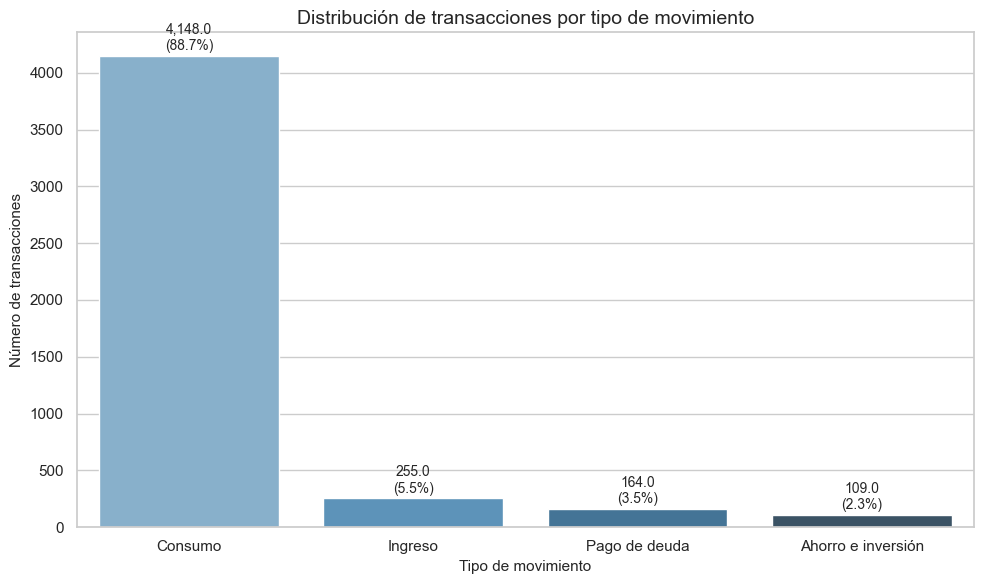

In [32]:
plt.figure(figsize=(10, 6))

ax = sns.barplot(
    data=conteo_movimientos,
    x="tipo_movimiento",
    y="cantidad",
    hue="tipo_movimiento",
    legend=False,
    palette="Blues_d"
)

for i, fila in conteo_movimientos.iterrows():
    ax.text(
        i,
        fila["cantidad"] + 50,
        f'{fila["cantidad"]:,}\n({fila["porcentaje"]:.1f}%)',
        ha="center",
        fontsize=10
    )

plt.title("Distribución de transacciones por tipo de movimiento")
plt.xlabel("Tipo de movimiento")
plt.ylabel("Número de transacciones")

plt.tight_layout()
plt.show()

Se observa un fuerte desbalance en la variable objetivo tipo_movimiento. El 88.71% de las transacciones corresponden a Consumo, mientras que Ahorro e inversión representa únicamente el 2.33%. Esta distribución deberá considerarse posteriormente durante el entrenamiento y evaluación del clasificador, ya que la exactitud por sí sola podría producir una evaluación engañosa.

### **Comparación de clases con escala logarítmica**

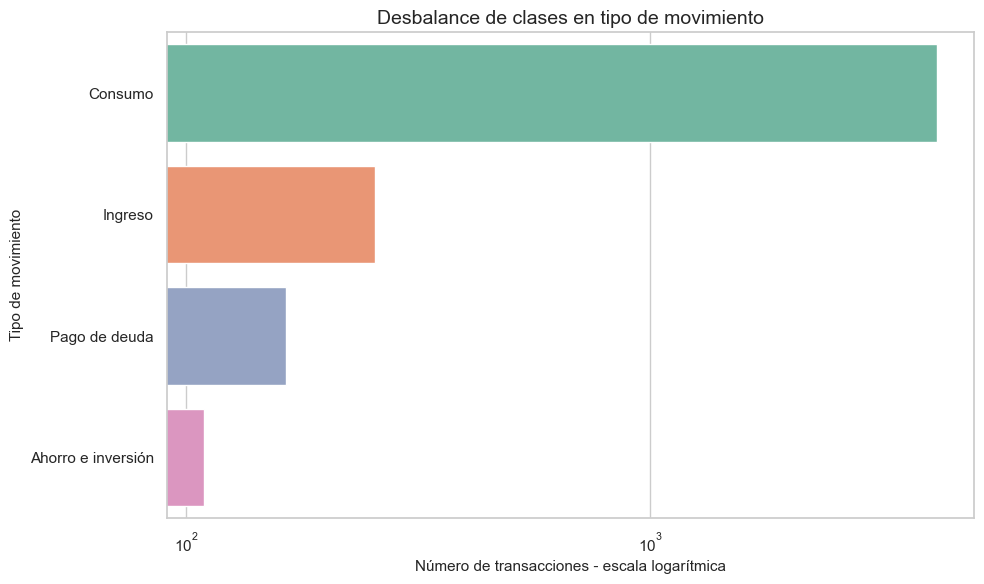

In [33]:
plt.figure(figsize=(10, 6))

sns.countplot(
    data=df,
    y="tipo_movimiento",
    order=df["tipo_movimiento"].value_counts().index,
    hue="tipo_movimiento",
    legend=False,
    palette="Set2"
)

plt.xscale("log")

plt.title("Desbalance de clases en tipo de movimiento")
plt.xlabel("Número de transacciones - escala logarítmica")
plt.ylabel("Tipo de movimiento")

plt.tight_layout()
plt.show()

Debido al desbalance de clases tan marcado no se podrá evaluar el clasificador únicamente con accuracy_score(), se necesitará classification_report(), confusion_matrix(), f1_score(..., average="macro").

### **Distribución de categorías de consumo**

In [34]:
df_consumo = df[
    df["tipo_movimiento"] == "Consumo"
].copy()

In [35]:
distribucion_categorias = (
    df_consumo["categoria"]
    .value_counts()
    .to_frame("cantidad")
)

distribucion_categorias["porcentaje"] = (
    distribucion_categorias["cantidad"]
    / len(df_consumo)
    * 100
).round(2)

distribucion_categorias

,cantidad,porcentaje
categoria,,
Alimentación,1609,38.79
Transporte,1064,25.65
Compras personales,327,7.88
Vivienda,261,6.29
Entretenimiento y ocio,224,5.40
Suscripciones digitales,167,4.03
Salud,144,3.47
Educación,140,3.38
Otros,127,3.06


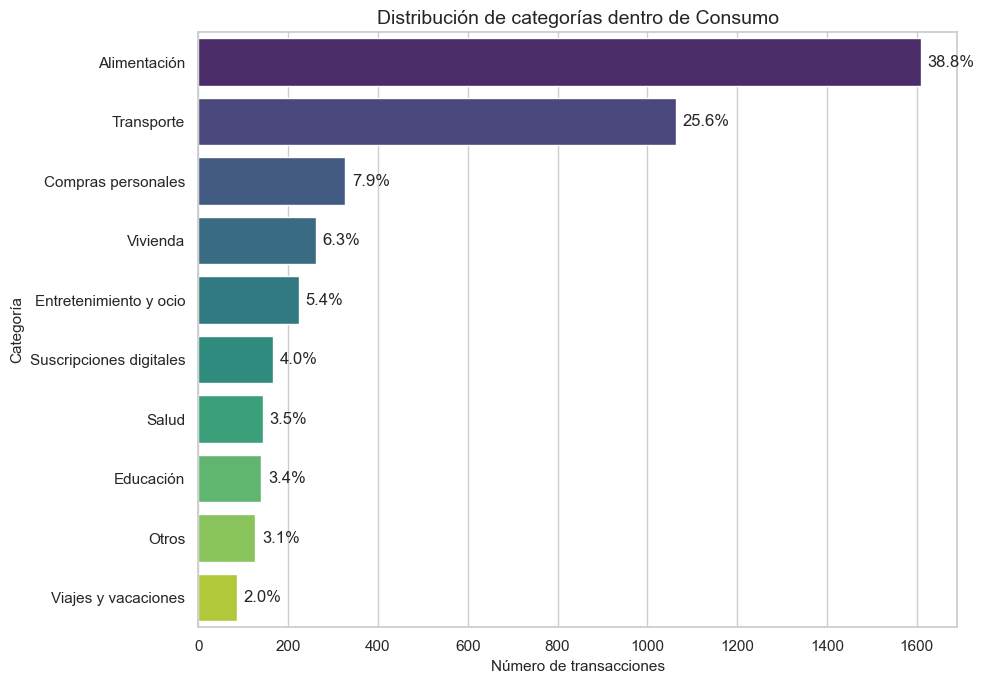

In [36]:
plt.figure(figsize=(10, 7))

ax = sns.barplot(
    data=distribucion_categorias,
    y="categoria",
    x="cantidad",
    hue="categoria",
    legend=False,
    palette="viridis"
)

for i, fila in distribucion_categorias.iterrows():
    ax.text(
        fila["cantidad"] + 15,
        i,
        f'{fila["porcentaje"]:.1f}%',
        va="center"
    )

plt.title("Distribución de categorías dentro de Consumo")
plt.xlabel("Número de transacciones")
plt.ylabel("Categoría")

plt.tight_layout()
plt.show()

La distribución de categorías también presenta desbalance. Alimentación y Transporte concentran aproximadamente el 64.44% de las transacciones de consumo, mientras que Viajes y vacaciones representa solamente el 2.05%. Por lo tanto, será necesario utilizar métricas sensibles al desempeño de las clases minoritarias.
*Uso de macro F1-score.

### **Frecuencia vs dinero gastado por categoría**

In [37]:
gasto_categoria = (
    df_consumo
    .groupby("categoria")["monto"]
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)

gasto_categoria["porcentaje"] = (
    gasto_categoria["monto"]
    / gasto_categoria["monto"].sum()
    * 100
)

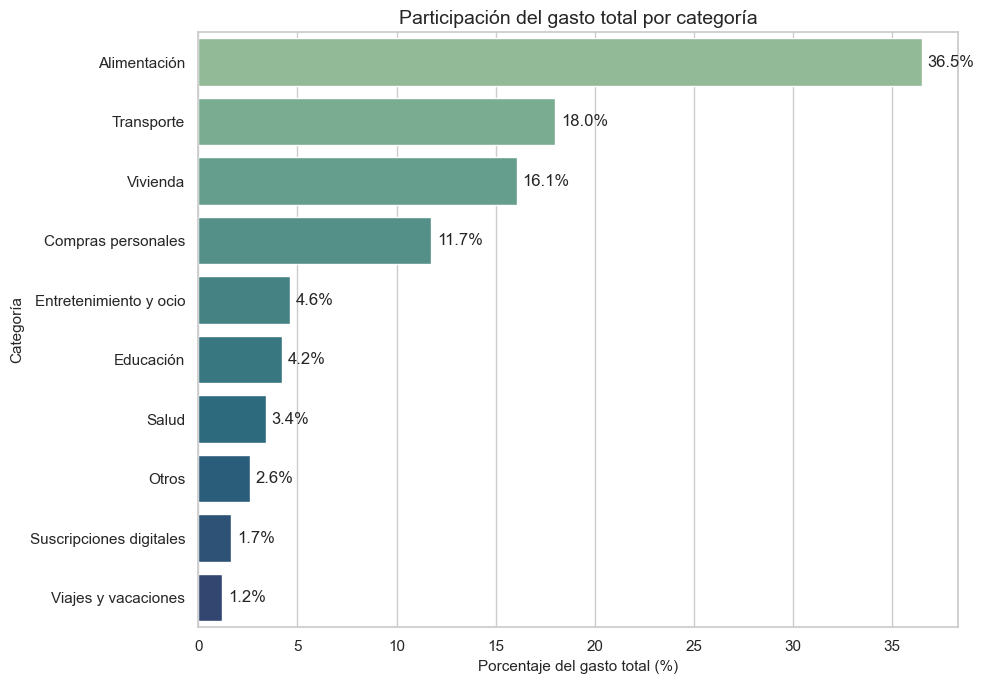

In [38]:
plt.figure(figsize=(10, 7))

ax = sns.barplot(
    data=gasto_categoria,
    y="categoria",
    x="porcentaje",
    hue="categoria",
    legend=False,
    palette="crest"
)

for i, fila in gasto_categoria.iterrows():
    ax.text(
        fila["porcentaje"] + 0.3,
        i,
        f'{fila["porcentaje"]:.1f}%',
        va="center"
    )

plt.title("Participación del gasto total por categoría")
plt.xlabel("Porcentaje del gasto total (%)")
plt.ylabel("Categoría")

plt.tight_layout()
plt.show()

Vivienda representa solamente 6.29% de las transacciones de consumo, pero concentra 16.06% del monto gastado. Esto refleja que la frecuencia de las transacciones y su impacto económico son fenómenos diferentes.

### **Distribución de grupos**

In [39]:
df_consumo["grupo"].value_counts(
    dropna=False
)

grupo
Esencial        3218
Discrecional     803
NaN              127
Name: count, dtype: int64

In [40]:
df_consumo["grupo"].value_counts(
    normalize=True,
    dropna=False
).mul(100).round(2)

grupo
Esencial        77.58
Discrecional    19.36
NaN              3.06
Name: proportion, dtype: float64

### **Análisis de montos por movimiento**

In [41]:
df.groupby("tipo_movimiento")["monto"].agg([
    "count",
    "mean",
    "median",
    "std",
    "min",
    "max"
]).round(2)

,count,mean,median,std,min,max
tipo_movimiento,,,,,,
Ahorro e inversión,109,2756.38,1440.66,6245.35,150.83,52357.48
Consumo,4148,534.15,378.54,554.03,20.00,6124.07
Ingreso,255,14079.00,9794.24,23609.02,151.05,338891.25
Pago de deuda,164,1976.10,1281.20,2176.29,101.25,15535.59


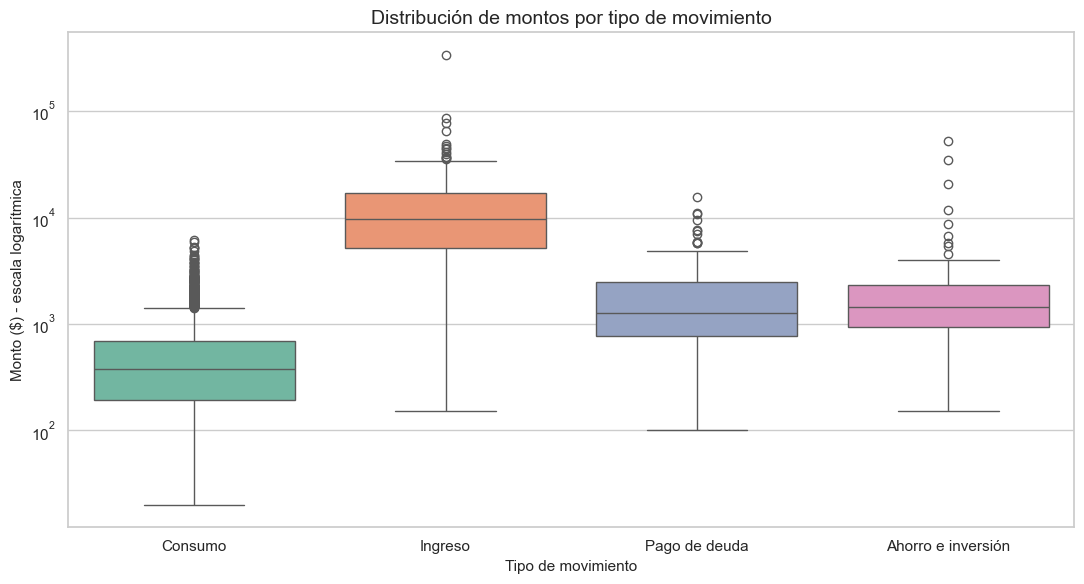

In [42]:
#utiliza escala logarítmica para evitar que la gráfica se aplaste por el ingreso de ~300,000
plt.figure(figsize=(11, 6))

sns.boxplot(
    data=df,
    x="tipo_movimiento",
    y="monto",
    hue="tipo_movimiento",
    legend=False,
    palette="Set2"
)

plt.yscale("log")

plt.title("Distribución de montos por tipo de movimiento")
plt.xlabel("Tipo de movimiento")
plt.ylabel("Monto ($) - escala logarítmica")

plt.tight_layout()
plt.show()

Las distribuciones de los montos presentan una fuerte asimetría positiva. Los valores extremos fueron conservados debido a que corresponden a comportamientos financieros plausibles de los perfiles simulados.

### **Montos por categoría**

In [43]:
df_consumo.groupby("categoria")["monto"].agg([
    "count",
    "mean",
    "median",
    "min",
    "max"
]).round(2).sort_values(
    "median",
    ascending=False
)

,count,mean,median,min,max
categoria,,,,,
Vivienda,261,1362.93,1171.63,20.00,5877.28
Compras personales,327,796.06,637.10,20.00,5167.83
Educación,140,668.07,550.28,33.06,2938.83
Salud,144,522.25,468.97,20.00,1584.36
Otros,127,452.75,389.06,20.00,2494.20
Alimentación,1609,502.61,377.18,20.00,6124.07
Entretenimiento y ocio,224,458.12,369.22,20.00,3516.10
Transporte,1064,375.17,286.18,20.00,3474.53
Viajes y vacaciones,85,309.30,195.00,35.83,1995.80


frecuencia de la categoría ≠ cantidad de dinero gastado

### **Distribución por tipo de pago**

In [44]:
df["tipo_pago"].unique()

<StringArray>
['Efectivo', 'Tarjeta de débito', 'Transferencia bancaria',
 'Tarjeta de crédito']
Length: 4, dtype: str

In [45]:
distribucion_tipo_pago = (
    df["tipo_pago"]
    .value_counts()
    .to_frame("cantidad")
)

distribucion_tipo_pago["porcentaje"] = (
    distribucion_tipo_pago["cantidad"]
    / len(df)
    * 100
).round(2)

distribucion_tipo_pago

,cantidad,porcentaje
tipo_pago,,
Tarjeta de débito,1867,39.93
Transferencia bancaria,1412,30.20
Tarjeta de crédito,824,17.62
Efectivo,573,12.25


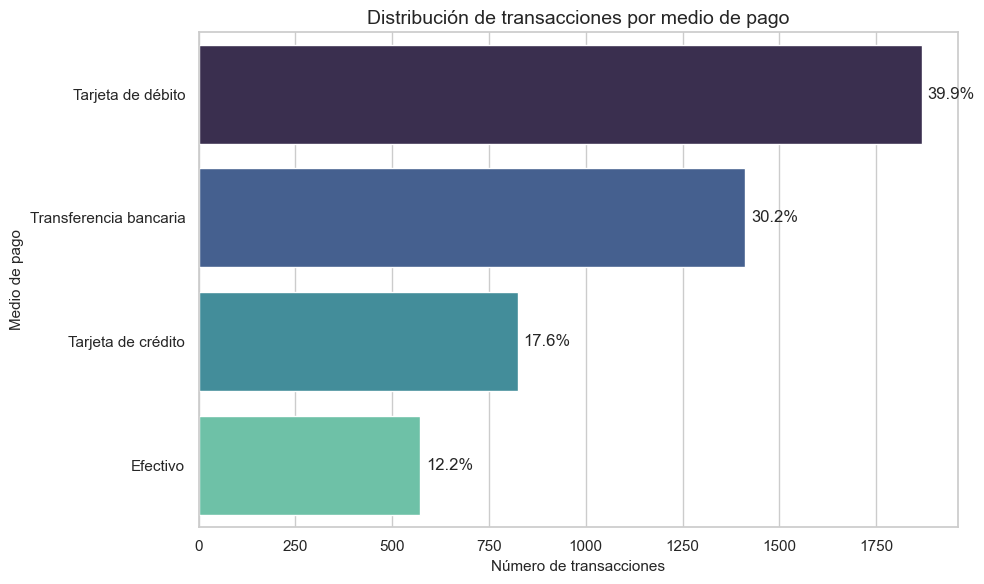

In [46]:
plt.figure(figsize=(10, 6))

ax = sns.barplot(
    data=distribucion_tipo_pago,
    y="tipo_pago",
    x="cantidad",
    hue="tipo_pago",
    legend=False,
    palette="mako"
)

for i, fila in distribucion_tipo_pago.iterrows():
    ax.text(
        fila["cantidad"] + 15,
        i,
        f'{fila["porcentaje"]:.1f}%',
        va="center"
    )

plt.title("Distribución de transacciones por medio de pago")
plt.xlabel("Número de transacciones")
plt.ylabel("Medio de pago")

plt.tight_layout()
plt.show()

### **Relación entre movimiento y medio de pago**

In [47]:
movimiento_pago = pd.crosstab(
    df["tipo_movimiento"],
    df["tipo_pago"],
    normalize="index"
) * 100

movimiento_pago.round(1)

tipo_pago,Efectivo,Tarjeta de crédito,Tarjeta de débito,Transferencia bancaria
tipo_movimiento,,,,
Ahorro e inversión,0.0,0.0,0.0,100.0
Consumo,13.3,19.9,45.0,21.8
Ingreso,8.2,0.0,0.0,91.8
Pago de deuda,0.0,0.0,0.0,100.0


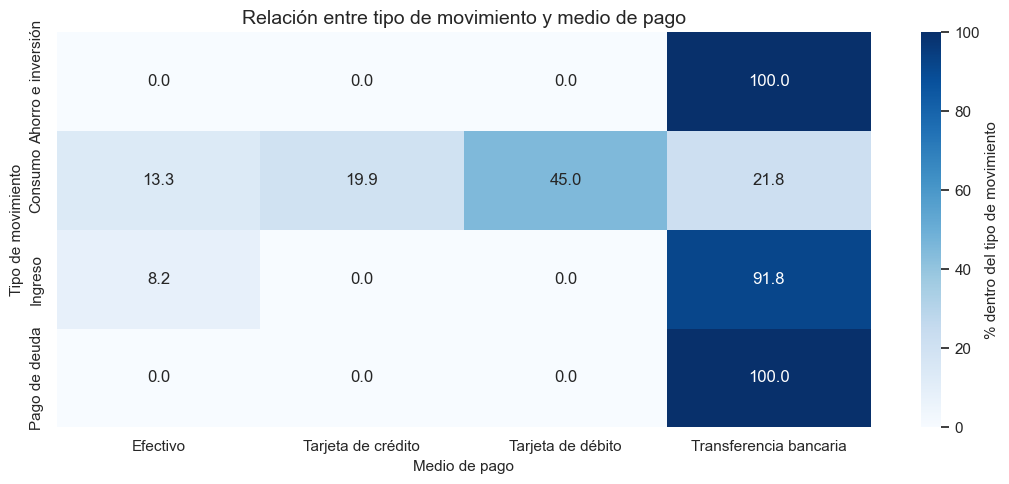

In [48]:
plt.figure(figsize=(11, 5))

sns.heatmap(
    movimiento_pago,
    annot=True,
    fmt=".1f",
    cmap="Blues",
    cbar_kws={"label": "% dentro del tipo de movimiento"}
)

plt.title("Relación entre tipo de movimiento y medio de pago")
plt.xlabel("Medio de pago")
plt.ylabel("Tipo de movimiento")

plt.tight_layout()
plt.show()

Los consumos se distribuyen aproximadamente:

- Débito: 45.0%
- Transferencia: 21.8%
- Crédito: 19.9%
- Efectivo: 13.3%

Mientras que ahorro, inversión y pago de deuda se realizan mediante transferencia en el dataset.

Esto es importante para el modelo porque tipo_pago podría convertirse en una variable altamente predictiva.

### **Análisis de tipo de pago = tarjeta de crédito**

In [49]:
df_credito = df[
    df["tipo_pago"] == "Tarjeta de crédito"
].copy()

In [50]:
df_credito["tasa_de_interes_de_la_tarjeta"].describe().round(2)

count    824.00
mean      39.93
std       12.10
min       14.70
25%       29.70
50%       41.35
75%       49.00
max       63.20
Name: tasa_de_interes_de_la_tarjeta, dtype: float64

### **Distribución de tasas de tarjeta de crédito**

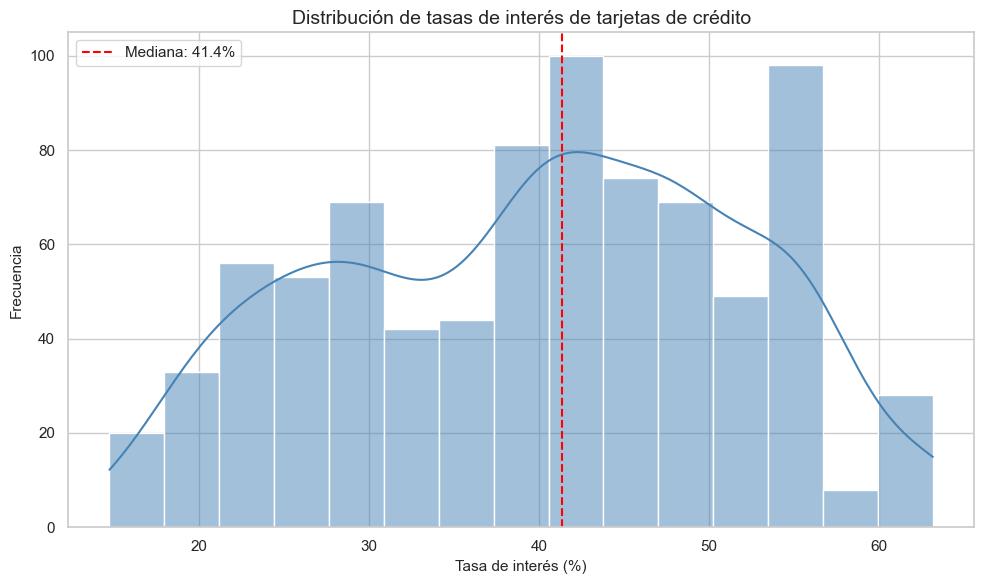

In [51]:
plt.figure(figsize=(10, 6))

sns.histplot(
    data=df_credito,
    x="tasa_de_interes_de_la_tarjeta",
    bins=15,
    kde=True,
    color="steelblue"
)

plt.axvline(
    df_credito["tasa_de_interes_de_la_tarjeta"].median(),
    color="red",
    linestyle="--",
    label=f'Mediana: {df_credito["tasa_de_interes_de_la_tarjeta"].median():.1f}%'
)

plt.title("Distribución de tasas de interés de tarjetas de crédito")
plt.xlabel("Tasa de interés (%)")
plt.ylabel("Frecuencia")
plt.legend()

plt.tight_layout()
plt.show()

**Esta variable es más útil para caracterización financiera que para el clasificador semántico.**

### **Cantidad de transacciones por usuario**

In [52]:
transacciones_usuario = (
    df.groupby("user_id")
    .size()
    .reset_index(name="numero_transacciones")
)

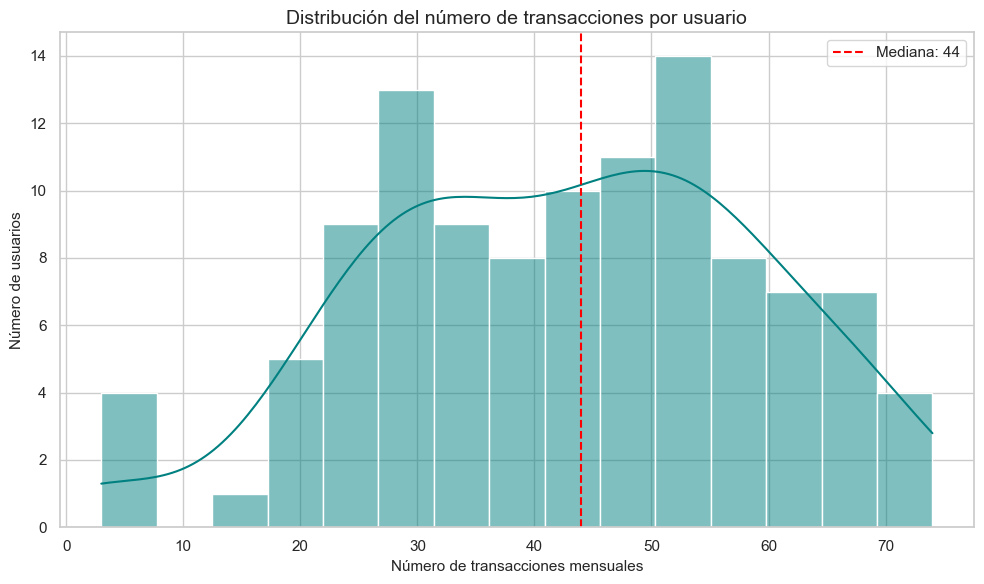

In [53]:
plt.figure(figsize=(10, 6))

sns.histplot(
    data=transacciones_usuario,
    x="numero_transacciones",
    bins=15,
    kde=True,
    color="teal"
)

plt.axvline(
    transacciones_usuario["numero_transacciones"].median(),
    color="red",
    linestyle="--",
    label=f'Mediana: {transacciones_usuario["numero_transacciones"].median():.0f}'
)

plt.title("Distribución del número de transacciones por usuario")
plt.xlabel("Número de transacciones mensuales")
plt.ylabel("Número de usuarios")
plt.legend()

plt.tight_layout()
plt.show()

- Mínimo:     3 transacciones
- Mediana:   44
- Promedio:  42.51
- Máximo:    74

### **Repetición en las descripciones**

In [54]:
#comprueba la diversidad de las descripciones
print(
    "Transacciones:",
    len(df)
)

print(
    "Descripciones únicas:",
    df["descripcion"].nunique()
)

print(
    "Descripciones limpias únicas:",
    df["descripcion_limpia"].nunique()
)

Transacciones: 4676
Descripciones únicas: 535
Descripciones limpias únicas: 535


In [55]:
#comprueba la repitición
frecuencia_descripciones = (
    df["descripcion_limpia"]
    .value_counts()
    .reset_index()
)

frecuencia_descripciones.columns = [
    "descripcion_limpia",
    "frecuencia"
]

frecuencia_descripciones.head(20)

,descripcion_limpia,frecuencia
0,agua embotellada,75
1,botanas para la casa,73
2,jugos y agua,69
3,refrescos para la casa,67
4,snacks del súper,65
5,verdura para la semana,61
6,fruta para la casa,60
7,pescado,59
8,frutas y verduras,57
9,compré verduras,54


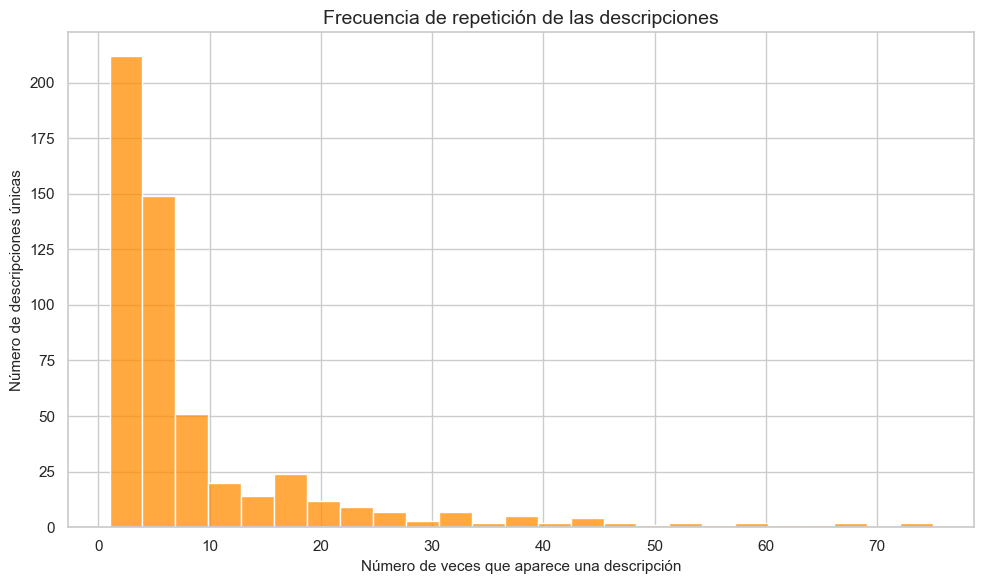

In [56]:
plt.figure(figsize=(10, 6))

sns.histplot(
    data=frecuencia_descripciones,
    x="frecuencia",
    bins=25,
    color="darkorange"
)

plt.title("Frecuencia de repetición de las descripciones")
plt.xlabel("Número de veces que aparece una descripción")
plt.ylabel("Número de descripciones únicas")

plt.tight_layout()
plt.show()

Existen descripciones idénticas repetidas en múltiples transacciones. Por lo tanto, una división aleatoria convencional podría colocar la misma descripción tanto en entrenamiento como en prueba, generando fuga de información y una estimación excesivamente optimista del desempeño.

### **Contradicciones semánticas**

Comprueba si una descripción tiene diferentes etiquetas

In [57]:
#para tipo de movimiento
conflictos_movimiento = (
    df.groupby("descripcion_limpia")
      ["tipo_movimiento"]
      .nunique()
)

conflictos_movimiento = conflictos_movimiento[
    conflictos_movimiento > 1
]

print(
    "Descripciones con múltiples tipos de movimiento:",
    len(conflictos_movimiento)
)

Descripciones con múltiples tipos de movimiento: 0


In [58]:
#para las categorías
conflictos_categoria = (
    df_consumo.groupby("descripcion_limpia")
              ["categoria"]
              .nunique()
)

conflictos_categoria = conflictos_categoria[
    conflictos_categoria > 1
]

print(
    "Descripciones con múltiples categorías:",
    len(conflictos_categoria)
)

Descripciones con múltiples categorías: 0


### **Comportamiento temporal de las transacciones**
Comprueba que las transacciones se distribuyan durante el mes.

In [59]:
transacciones_dia = (
    df.groupby("fecha")
    .size()
    .reset_index(name="transacciones")
)

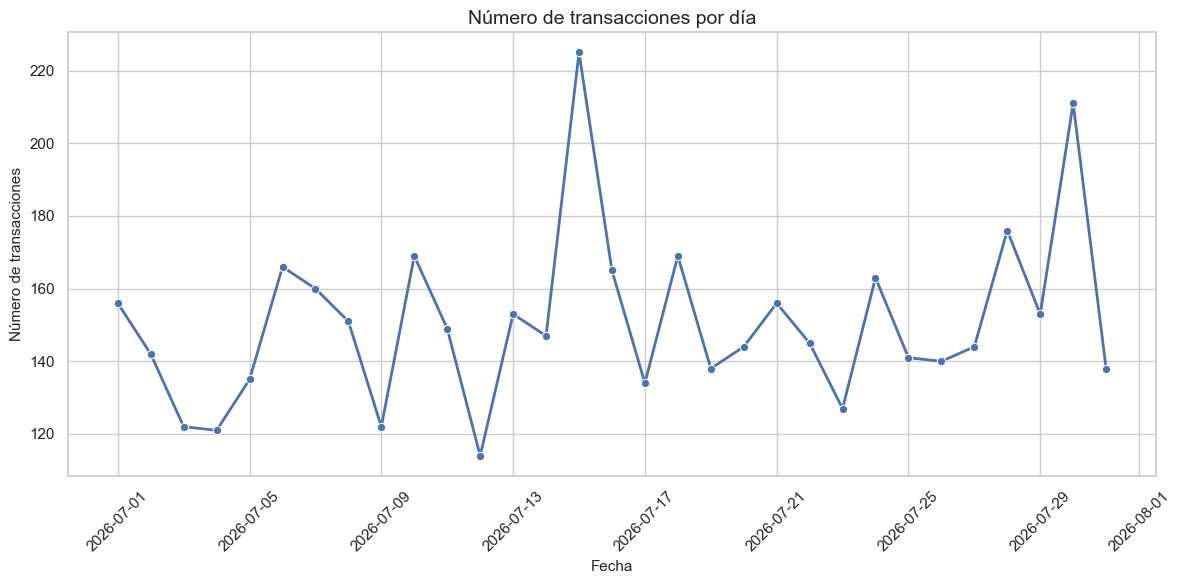

In [60]:
plt.figure(figsize=(12, 6))

sns.lineplot(
    data=transacciones_dia,
    x="fecha",
    y="transacciones",
    marker="o",
    linewidth=2
)

plt.title("Número de transacciones por día")
plt.xlabel("Fecha")
plt.ylabel("Número de transacciones")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

Esta visualización sirve principalmente para validar que las transacciones no fueron colocadas todas artificialmente en los mismos días.

### **Validación final**

In [61]:
print("Dimensiones finales:", df.shape)
print("Usuarios:", df["user_id"].nunique())
print("Duplicados:", df.duplicated().sum())
print("Descripciones vacías:", (df["descripcion_limpia"] == "").sum())
print("Montos <= 0:", (df["monto"] <= 0).sum())

print("\nNulos:")
print(df.isna().sum())

Dimensiones finales: (4676, 14)
Usuarios: 110
Duplicados: 0
Descripciones vacías: 0
Montos <= 0: 0

Nulos:
user_id                             0
nombre                              0
arquetipo_perfil                    0
periodo_inicio                      0
periodo_fin                         0
fecha                               0
descripcion                         0
monto                               0
tipo_movimiento                     0
categoria                         528
grupo                             655
tipo_pago                           0
tasa_de_interes_de_la_tarjeta    3852
descripcion_limpia                  0
dtype: int64


### **Exportación del dataset limpio**

In [62]:
df.to_csv(
    "dataset_finance_ai_110_usuarios_limpio.csv",
    index=False,
    encoding="utf-8"
)

## **Conclusiones del análisis exploratorio**

El análisis exploratorio muestra que el dataset presenta distribuciones financieras heterogéneas tanto en frecuencia como en monto. Los movimientos de Consumo representan el 88.71% de las observaciones, evidenciando un fuerte desbalance respecto a Ingreso, Pago de deuda y Ahorro e inversión. Dentro de los consumos, Alimentación y Transporte concentran el 64.44% de las transacciones.

Los montos presentan distribuciones asimétricas y valores extremos que se consideran plausibles dadas las características de los perfiles financieros simulados, por lo que no fueron eliminados. Asimismo, se identificó una repetición considerable de las descripciones textuales: las 4,676 transacciones contienen 535 descripciones únicas, algunas repetidas hasta 75 veces.

Este último hallazgo es relevante para el desarrollo del modelo de clasificación, ya que una separación aleatoria de los datos podría colocar descripciones idénticas simultáneamente en entrenamiento y prueba, provocando fuga de información. Por lo tanto, la estrategia de partición deberá considerar agrupamiento por descripción y métricas robustas ante el desbalance de clases, especialmente macro F1-score.

# **Preparación de datos para el modelado**

**Objetivo:**

En esta etapa, el sistema estará compuesto por dos tareas supervisadas independientes. La primera corresponde a la **clasificación del movimiento**, para la cual se utilizarán todas las transacciones disponibles. En este caso, la variable objetivo será `tipo_movimiento`, que contempla cuatro clases posibles (Ingreso, Consumo, Ahorro e inversión y PAgo de deuda). La segunda tarea será la **clasificación del consumo**, que se aplicará únicamente a aquellos movimientos previamente identificados como Consumo. Para esta tarea, la variable objetivo será `categoria`, compuesta por diez clases (Alimentación, Vivienda, Transporte, Educación, etc).

En ambas tareas, la principal variable de entrada será `  descripcion_limpia`. Esta variable contiene la representación textual de la descripción de cada transacción después del proceso de limpieza y será la fuente de información utilizada por los modelos para realizar la clasificación semántica.

La lógica del sistema se organizará de manera secuencial. En primer lugar, la descripción de la transacción será procesada por el clasificador de movimiento, encargado de determinar el tipo de movimiento correspondiente. Posteriormente, el sistema verificará si el movimiento ha sido clasificado como Consumo. Si pertenece a otro tipo de movimiento, el proceso de clasificación finalizará en ese punto. En cambio, si se identifica como Consumo, la transacción será enviada a un segundo clasificador, cuya función será determinar la categoría de consumo correspondiente.

Para evitar posibles problemas de fuga de información (*data leakage*) y garantizar que las predicciones se basen principalmente en el contenido semántico de las transacciones, las variables `user_id`, `nombre`, `arquetipo_perfil`, `grupo` y cualquier otra variable que revele directa o indirectamente la etiqueta que se desea predecir. Asimismo, `categoria` no será utilizada como característica durante la predicción del tipo de movimiento.

Estas columnas se conservaron en el conjunto de datos; sin embargo, no serán utilizadas para entrenar y ejecutar los modelos de clasificación semántica.

## **Importación de librerías y carga del dataset limpio**

In [63]:
from sklearn.model_selection import StratifiedGroupKFold

pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", 100)

RANDOM_STATE = 42

In [64]:
ruta_dataset = "dataset_finance_ai_110_usuarios_limpio.csv"

df = pd.read_csv(
    ruta_dataset,
    parse_dates=[
        "periodo_inicio",
        "periodo_fin",
        "fecha"
    ]
)

print("Dimensiones:", df.shape)
print("Usuarios:", df["user_id"].nunique())
print("Descripciones únicas:", df["descripcion_limpia"].nunique())

df.head()

Dimensiones: (4676, 14)
Usuarios: 110
Descripciones únicas: 535


,user_id,nombre,arquetipo_perfil,periodo_inicio,periodo_fin,fecha,descripcion,monto,tipo_movimiento,categoria,grupo,tipo_pago,tasa_de_interes_de_la_tarjeta,descripcion_limpia
0,110504306,Valentina Romero,Usuario con ingresos estacionales,2026-07-01,2026-07-31,2026-07-01,cosas para cocinar,164.68,Consumo,Alimentación,Esencial,Efectivo,NaN,cosas para cocinar
1,110504306,Valentina Romero,Usuario con ingresos estacionales,2026-07-01,2026-07-31,2026-07-01,apoyo a un familiar,238.45,Consumo,Otros,NaN,Tarjeta de débito,NaN,apoyo a un familiar
2,110504306,Valentina Romero,Usuario con ingresos estacionales,2026-07-01,2026-07-31,2026-07-02,cambio de aceite,602.64,Consumo,Transporte,Esencial,Transferencia bancaria,NaN,cambio de aceite
3,110504306,Valentina Romero,Usuario con ingresos estacionales,2026-07-01,2026-07-31,2026-07-02,venta por internet,1935.92,Ingreso,NaN,NaN,Transferencia bancaria,NaN,venta por internet
4,110504306,Valentina Romero,Usuario con ingresos estacionales,2026-07-01,2026-07-31,2026-07-03,compré pescado,351.15,Consumo,Alimentación,Esencial,Efectivo,NaN,compré pescado


In [65]:
#valida variables necesarias
columnas_necesarias = [
    "descripcion_limpia",
    "tipo_movimiento",
    "categoria"
]

df[columnas_necesarias].isna().sum()

descripcion_limpia      0
tipo_movimiento         0
categoria             528
dtype: int64

In [66]:
#valida las descripciones
assert df["descripcion_limpia"].notna().all()
assert df["descripcion_limpia"].str.strip().ne("").all()

print("Todas las descripciones son válidas.")

Todas las descripciones son válidas.


In [67]:
#valida las categorias
assert df["descripcion_limpia"].notna().all()
assert df["descripcion_limpia"].str.strip().ne("").all()

print("Todas las descripciones son válidas.")

Todas las descripciones son válidas.


## **Tarea 1: Clasificación del movimiento**

### **Preparación del dataset**

In [68]:
columnas_tarea_movimiento = [
    "user_id",
    "descripcion",
    "descripcion_limpia",
    "tipo_movimiento"
]

datos_movimiento = df[
    columnas_tarea_movimiento
].copy()

print("Registros:", len(datos_movimiento))
print("Descripciones únicas:", datos_movimiento["descripcion_limpia"].nunique())

datos_movimiento.head()

Registros: 4676
Descripciones únicas: 535


,user_id,descripcion,descripcion_limpia,tipo_movimiento
0,110504306,cosas para cocinar,cosas para cocinar,Consumo
1,110504306,apoyo a un familiar,apoyo a un familiar,Consumo
2,110504306,cambio de aceite,cambio de aceite,Consumo
3,110504306,venta por internet,venta por internet,Ingreso
4,110504306,compré pescado,compré pescado,Consumo


In [69]:
objetivo_movimiento = "tipo_movimiento"

In [70]:
datos_movimiento[
    objetivo_movimiento
].value_counts()

tipo_movimiento
Consumo               4148
Ingreso                255
Pago de deuda          164
Ahorro e inversión     109
Name: count, dtype: int64

### **Split agrupado**

Utilizar 'train_test_split' aleatorio podría colocar la misma descripción tanto en el conjunto de entrenamiento como en el de prueba, haciendo así que el modelo no aprendiera nada nuevo sino que sólo reconocería frases que ya vio antes.

Por lo tanto, con la finalidad de mantener las proporciones de cada clase y la descripción completa en un sólo grupo, se usará StratifiedGroupKFold.

In [71]:
def crear_split_agrupado(
    datos,
    columna_objetivo,
    columna_grupo="descripcion_limpia",
    n_splits=5,
    random_state=42
):
    """
    Genera una división aproximada 80/20:

    - Estratificada por la variable objetivo.
    - Agrupada por descripción.
    - Sin descripciones compartidas entre train y test.
    """

    splitter = StratifiedGroupKFold(
        n_splits=n_splits,
        shuffle=True,
        random_state=random_state
    )

    X_temporal = datos[[columna_grupo]]
    y = datos[columna_objetivo]
    grupos = datos[columna_grupo]

    train_indices, test_indices = next(
        splitter.split(
            X=X_temporal,
            y=y,
            groups=grupos
        )
    )

    datos_train = (
        datos.iloc[train_indices]
        .copy()
        .reset_index(drop=True)
    )

    datos_test = (
        datos.iloc[test_indices]
        .copy()
        .reset_index(drop=True)
    )

    return datos_train, datos_test

### **Split de movimientos**

In [72]:
train_movimiento, test_movimiento = crear_split_agrupado(
    datos=datos_movimiento,
    columna_objetivo="tipo_movimiento",
    random_state=RANDOM_STATE
)

In [73]:
#revisa tamaños
print("Train:", train_movimiento.shape)
print("Test:", test_movimiento.shape)

print(
    "Porcentaje train:",
    round(len(train_movimiento) / len(datos_movimiento) * 100, 2)
)

print(
    "Porcentaje test:",
    round(len(test_movimiento) / len(datos_movimiento) * 100, 2)
)

Train: (3740, 4)
Test: (936, 4)
Porcentaje train: 79.98
Porcentaje test: 20.02


### **Verifica que no exista fuga por descripción**

In [74]:
descripciones_train_movimiento = set(
    train_movimiento["descripcion_limpia"]
)

descripciones_test_movimiento = set(
    test_movimiento["descripcion_limpia"]
)

descripciones_compartidas_movimiento = (
    descripciones_train_movimiento
    .intersection(descripciones_test_movimiento)
)

print(
    "Descripciones únicas en train:",
    len(descripciones_train_movimiento)
)

print(
    "Descripciones únicas en test:",
    len(descripciones_test_movimiento)
)

print(
    "Descripciones compartidas:",
    len(descripciones_compartidas_movimiento)
)

Descripciones únicas en train: 428
Descripciones únicas en test: 107
Descripciones compartidas: 0


In [75]:
#validación automática
assert len(descripciones_compartidas_movimiento) == 0

print("Split correcto: no existe fuga por descripción.")

Split correcto: no existe fuga por descripción.


### **Compara la distribución de las clases**

In [76]:
def comparar_distribuciones(
    datos_completos,
    datos_train,
    datos_test,
    columna_objetivo
):
    distribucion = pd.concat(
        [
            datos_completos[columna_objetivo]
            .value_counts()
            .rename("total"),

            datos_train[columna_objetivo]
            .value_counts()
            .rename("train"),

            datos_test[columna_objetivo]
            .value_counts()
            .rename("test"),

            (
                datos_completos[columna_objetivo]
                .value_counts(normalize=True)
                .mul(100)
                .round(2)
                .rename("total_pct")
            ),

            (
                datos_train[columna_objetivo]
                .value_counts(normalize=True)
                .mul(100)
                .round(2)
                .rename("train_pct")
            ),

            (
                datos_test[columna_objetivo]
                .value_counts(normalize=True)
                .mul(100)
                .round(2)
                .rename("test_pct")
            )
        ],
        axis=1
    )

    return distribucion

In [77]:
distribucion_movimiento = comparar_distribuciones(
    datos_completos=datos_movimiento,
    datos_train=train_movimiento,
    datos_test=test_movimiento,
    columna_objetivo="tipo_movimiento"
)

distribucion_movimiento

,total,train,test,total_pct,train_pct,test_pct
tipo_movimiento,,,,,,
Consumo,4148,3318,830,88.71,88.72,88.68
Ingreso,255,204,51,5.45,5.45,5.45
Pago de deuda,164,131,33,3.51,3.50,3.53
Ahorro e inversión,109,87,22,2.33,2.33,2.35


### **Valida cobertura de clases**

In [78]:
clases_totales_movimiento = set(
    datos_movimiento["tipo_movimiento"].unique()
)

clases_train_movimiento = set(
    train_movimiento["tipo_movimiento"].unique()
)

clases_test_movimiento = set(
    test_movimiento["tipo_movimiento"].unique()
)

assert clases_totales_movimiento.issubset(
    clases_train_movimiento
)

assert clases_totales_movimiento.issubset(
    clases_test_movimiento
)

print("Todas las clases están presentes en train y test.")

Todas las clases están presentes en train y test.


## **Tarea 2: Clasificación de categoría**

### **Selección de consumos**

Categoría si y sólo si el movimiento es consumo

In [79]:
datos_categoria = (
    df.loc[
        df["tipo_movimiento"] == "Consumo",
        [
            "user_id",
            "descripcion",
            "descripcion_limpia",
            "categoria",
            "grupo",
            "tipo_pago",
            "monto"
        ]
    ]
    .copy()
    .reset_index(drop=True)
)

In [80]:
#valida datos_categoria
print("Registros de consumo:", len(datos_categoria))
print("Categorías:", datos_categoria["categoria"].nunique())
print("Descripciones únicas:", datos_categoria["descripcion_limpia"].nunique())

assert datos_categoria["categoria"].notna().all()

Registros de consumo: 4148
Categorías: 10
Descripciones únicas: 403


In [81]:
#La variable objetivo será:
objetivo_categoria = "categoria"

### **Split agrupado de cateegorías**

In [82]:
train_categoria, test_categoria = crear_split_agrupado(
    datos=datos_categoria,
    columna_objetivo="categoria",
    random_state=RANDOM_STATE
)

In [83]:
print("Train:", train_categoria.shape)
print("Test:", test_categoria.shape)

print(
    "Porcentaje train:",
    round(len(train_categoria) / len(datos_categoria) * 100, 2)
)

print(
    "Porcentaje test:",
    round(len(test_categoria) / len(datos_categoria) * 100, 2)
)

Train: (3316, 7)
Test: (832, 7)
Porcentaje train: 79.94
Porcentaje test: 20.06


### **Verifica ausencia de fuga en categoría**

In [84]:
descripciones_train_categoria = set(
    train_categoria["descripcion_limpia"]
)

descripciones_test_categoria = set(
    test_categoria["descripcion_limpia"]
)

descripciones_compartidas_categoria = (
    descripciones_train_categoria
    .intersection(descripciones_test_categoria)
)

print(
    "Descripciones únicas en train:",
    len(descripciones_train_categoria)
)

print(
    "Descripciones únicas en test:",
    len(descripciones_test_categoria)
)

print(
    "Descripciones compartidas:",
    len(descripciones_compartidas_categoria)
)

assert len(descripciones_compartidas_categoria) == 0

Descripciones únicas en train: 322
Descripciones únicas en test: 81
Descripciones compartidas: 0


### **Compara las reglas entre entrenamiento y prueba**

In [85]:
distribucion_categoria = comparar_distribuciones(
    datos_completos=datos_categoria,
    datos_train=train_categoria,
    datos_test=test_categoria,
    columna_objetivo="categoria"
)

distribucion_categoria

,total,train,test,total_pct,train_pct,test_pct
categoria,,,,,,
Alimentación,1609,1286,323,38.79,38.78,38.82
Transporte,1064,852,212,25.65,25.69,25.48
Compras personales,327,259,68,7.88,7.81,8.17
Vivienda,261,209,52,6.29,6.30,6.25
Entretenimiento y ocio,224,180,44,5.40,5.43,5.29
Suscripciones digitales,167,133,34,4.03,4.01,4.09
Salud,144,115,29,3.47,3.47,3.49
Educación,140,112,28,3.38,3.38,3.37
Otros,127,102,25,3.06,3.08,3.00


### **Verifica la cobertura de las 10 categorías**

In [86]:
categorias_totales = set(
    datos_categoria["categoria"].unique()
)

categorias_train = set(
    train_categoria["categoria"].unique()
)

categorias_test = set(
    test_categoria["categoria"].unique()
)

assert categorias_totales.issubset(categorias_train)
assert categorias_totales.issubset(categorias_test)

print("Todas las categorías están presentes en train y test.")

Todas las categorías están presentes en train y test.


### **Preparación de variables que recibirá TF-IDF**

#### **Clasificador de tipo de movimiento**

In [87]:
#separa x y y
X_train_movimiento = (
    train_movimiento["descripcion_limpia"]
    .copy()
)

X_test_movimiento = (
    test_movimiento["descripcion_limpia"]
    .copy()
)

y_train_movimiento = (
    train_movimiento["tipo_movimiento"]
    .copy()
)

y_test_movimiento = (
    test_movimiento["tipo_movimiento"]
    .copy()
)

#### **Clasificador de categoría**

In [88]:
#separa x y y
X_train_categoria = (
    train_categoria["descripcion_limpia"]
    .copy()
)

X_test_categoria = (
    test_categoria["descripcion_limpia"]
    .copy()
)

y_train_categoria = (
    train_categoria["categoria"]
    .copy()
)

y_test_categoria = (
    test_categoria["categoria"]
    .copy()
)

In [89]:
#revisa las dimensiones

print("Clasificador de movimiento")
print("X train:", X_train_movimiento.shape)
print("X test:", X_test_movimiento.shape)
print("y train:", y_train_movimiento.shape)
print("y test:", y_test_movimiento.shape)

print("\nClasificador de categoría")
print("X train:", X_train_categoria.shape)
print("X test:", X_test_categoria.shape)
print("y train:", y_train_categoria.shape)
print("y test:", y_test_categoria.shape)

Clasificador de movimiento
X train: (3740,)
X test: (936,)
y train: (3740,)
y test: (936,)

Clasificador de categoría
X train: (3316,)
X test: (832,)
y train: (3316,)
y test: (832,)


#### **Verificación final automatizada**

Esta celda detendrá todo el notebook si el dataset llega a cambiar y el split deja de cumplir las condiciones.


In [90]:
# Sin valores faltantes en el texto
assert X_train_movimiento.notna().all()
assert X_test_movimiento.notna().all()
assert X_train_categoria.notna().all()
assert X_test_categoria.notna().all()

# Sin textos vacíos
assert X_train_movimiento.str.strip().ne("").all()
assert X_test_movimiento.str.strip().ne("").all()
assert X_train_categoria.str.strip().ne("").all()
assert X_test_categoria.str.strip().ne("").all()

# Sin descripciones compartidas
assert set(X_train_movimiento).isdisjoint(
    set(X_test_movimiento)
)

assert set(X_train_categoria).isdisjoint(
    set(X_test_categoria)
)

# Todas las clases representadas
assert set(y_train_movimiento.unique()) == set(
    y_test_movimiento.unique()
)

assert set(y_train_categoria.unique()) == set(
    y_test_categoria.unique()
)

print("Preparación terminada correctamente.")
print("No existe solapamiento de descripciones entre train y test.")
print("Todas las clases están representadas.")

Preparación terminada correctamente.
No existe solapamiento de descripciones entre train y test.
Todas las clases están representadas.


Se definieron dos tareas de clasificación: la identificación del tipo de movimiento para todas las transacciones y la clasificación de categoría exclusivamente para los movimientos de Consumo. En ambas tareas se utilizó descripcion_limpia como variable de entrada.

Para evitar fuga de información causada por la repetición de descripciones, se empleó una partición estratificada y agrupada mediante StratifiedGroupKFold. Este procedimiento aseguró que cada descripción apareciera exclusivamente en entrenamiento o prueba, manteniendo al mismo tiempo proporciones similares de las clases.

Para el clasificador de movimientos se obtuvieron 3,740 registros de entrenamiento y 936 de prueba, con cero descripciones compartidas. Para el clasificador de categorías se obtuvieron 3,316 registros de entrenamiento y 832 de prueba, igualmente sin solapamiento. Todas las clases permanecieron representadas en ambos conjuntos.

### **Extracción de características con TF-IDF**

En este bloque se converitrán las descripciones en matrices numéricas. Después de auditar una primera versión basada únicamente en palabras, se procederá con:

- TF-IDF de palabras y bigramas, para capturar expresiones como pago tarjeta o compré comida.
- TF-IDF de caracteres, para capturar variaciones como pago, pagué, pagando, plurales y diferencias ortográficas.

TF-IDF asigna mayor importancia a términos que aparecen en una descripción o no aparecen con demasiada frecuencia en el resto del set. De tal manera que cada descripción se convertirá en un vector numérico.

#### **Importación de librerías**

In [91]:
import numpy as np

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.pipeline import FeatureUnion

In [92]:
#variables a utilizar
X_train_movimiento
X_test_movimiento
y_train_movimiento
y_test_movimiento

X_train_categoria
X_test_categoria
y_train_categoria
y_test_categoria

0      Entretenimiento y ocio
1                Alimentación
2                  Transporte
3                  Transporte
4                Alimentación
                ...          
827              Alimentación
828                Transporte
829                Transporte
830              Alimentación
831              Alimentación
Name: categoria, Length: 832, dtype: str

#### **Regla para evitar fuga de información**

El vectorizador debe aprender su vocabulario únicamente con entrenamiento.

Regla:
X_train_tfidf = vectorizador.fit_transform(X_train)
X_test_tfidf = vectorizador.transform(X_test)


#### **Primera prueba: TF-IDF de palabras**



##### **Versión inicial**

In [93]:
tfidf_palabras_prueba = TfidfVectorizer(
    lowercase=False,
    strip_accents="unicode",
    analyzer="word",
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.95,
    sublinear_tf=True,
    norm="l2",
    dtype=np.float32
)

##### **Audita la primera configuración**

In [94]:
#prueba en la tarea de tipo de movimiento
X_train_movimiento_prueba = (
    tfidf_palabras_prueba.fit_transform(
        X_train_movimiento
    )
)

X_test_movimiento_prueba = (
    tfidf_palabras_prueba.transform(
        X_test_movimiento
    )
)

In [95]:
#revisa las dimensiones
print(
    "Train:",
    X_train_movimiento_prueba.shape
)

print(
    "Test:",
    X_test_movimiento_prueba.shape
)


#Cada fila es una transacción y cada columna una característica textual.

Train: (3740, 936)
Test: (936, 936)


##### **Detectar vectores vacíos**

Una descripción genera un vector vacío cuando ninguno de sus términos existe en el vocabulario aprendido con entrenamiento.


In [96]:
vectores_vacios_train = (
    X_train_movimiento_prueba
    .getnnz(axis=1) == 0
).sum()

vectores_vacios_test = (
    X_test_movimiento_prueba
    .getnnz(axis=1) == 0
).sum()

print(
    "Vectores vacíos en train:",
    vectores_vacios_train
)

print(
    "Vectores vacíos en test:",
    vectores_vacios_test
)

print(
    "Porcentaje vacío en test:",
    round(
        vectores_vacios_test
        / X_test_movimiento_prueba.shape[0]
        * 100,
        2
    )
)

Vectores vacíos en train: 5
Vectores vacíos en test: 139
Porcentaje vacío en test: 14.85


Los resultados demuestran que el split contiene frases realmente nuevas y algunas están formadas completamente por palabras que no aparecen en entrenamiento.

Por ello se utilizará una representación híbrida.

#### **Representación híbrida: palabras + caracteres**

##### **Crea función para construir el extractor**

In [97]:
def crear_extractor_tfidf():
    """
    Combina TF-IDF de palabras y caracteres.

    La función crea un objeto nuevo cada vez para evitar
    compartir vocabulario entre las dos tareas.
    """

    tfidf_palabras = TfidfVectorizer(
        lowercase=False,
        strip_accents="unicode",
        analyzer="word",
        ngram_range=(1, 2),
        min_df=1,
        max_df=0.95,
        sublinear_tf=True,
        norm="l2",
        dtype=np.float32
    )

    tfidf_caracteres = TfidfVectorizer(
        lowercase=False,
        strip_accents="unicode",
        analyzer="char_wb",
        ngram_range=(3, 5),
        min_df=2,
        max_df=1.0,
        sublinear_tf=True,
        norm="l2",
        dtype=np.float32
    )

    extractor = FeatureUnion(
        transformer_list=[
            ("palabras", tfidf_palabras),
            ("caracteres", tfidf_caracteres)
        ],
        transformer_weights={
            "palabras": 1.0,
            "caracteres": 1.0
        }
    )

    return extractor

char_wb crea fragmentos de caracteres dentro de los límites de cada palabra. Por ejemplo, a partir de la palabra pagué, puede extraer fragmentos como pag, pagu o ague. Este enfoque permite que el modelo identifique similitudes entre palabras que comparten una misma raíz o secuencias de caracteres, como pago, pagué, pagando y pagamos. Además, proporciona cierta tolerancia ante errores ortográficos o pequeñas variaciones en la escritura, lo que contribuye a que el modelo reconozca términos relacionados incluso cuando no están escritos exactamente de la misma manera.

**Se utilizan configuraciones diferentes para las características basadas en palabras y en caracteres debido a la naturaleza de la información que genera cada representación.** En el caso de las palabras, se establece `min_df=1`, ya que, al contar con solo 428 descripciones únicas de entrenamiento en la primera tarea, una palabra que aparece pocas veces puede contener información relevante para la clasificación. Términos como `hipoteca`, `herencia`, `Netflix` o `Afore` podrían tener una frecuencia reducida dentro del conjunto de datos y, aun así, aportar señales importantes para identificar determinados tipos de movimientos. Por esta razón, se conservan incluso las palabras que aparecen una sola vez.

En el caso de las características basadas en caracteres, se utiliza `min_df=2`. Los fragmentos de caracteres generan una cantidad considerablemente mayor de características que las palabras, por lo que incluir aquellos que aparecen una sola vez podría incrementar innecesariamente el ruido y la dimensionalidad de la representación. Exigir que cada fragmento aparezca al menos dos veces permite controlar el tamaño del espacio de características y descartar patrones demasiado aislados, manteniendo aquellos que tienen mayor probabilidad de aportar información útil al modelo.

Por otra parte, no se eliminan las *stopwords*, ya que, aunque palabras como `de`, `la`, `para` o `me` suelen considerarse poco informativas de manera individual, pueden formar parte de expresiones relevantes cuando se trabaja con descripciones cortas. Frases como `pago de tarjeta`, `me cayó la nómina`, `para la escuela` o `de la renta` contienen estructuras lingüísticas que pueden ayudar a distinguir el contexto y significado de una transacción. Por ello, conservar estas palabras permite preservar información contextual que podría perderse si se aplicara una eliminación automática de *stopwords*.


### **TF-IDF para tipo de movimiento** (TF-IDF híbrido + LinearSVC)

In [98]:
#crea un extractor independiente
extractor_movimiento = crear_extractor_tfidf()

In [99]:
#ajusta el extractor al entrenamiento
X_train_movimiento_tfidf = (
    extractor_movimiento.fit_transform(
        X_train_movimiento
    )
)

In [100]:
#transforma prueba sin volver a ajustar
X_test_movimiento_tfidf = (
    extractor_movimiento.transform(
        X_test_movimiento
    )
)

In [101]:
#revisa dimensiones
print(
    "Matriz train:",
    X_train_movimiento_tfidf.shape
)

print(
    "Matriz test:",
    X_test_movimiento_tfidf.shape
)

Matriz train: (3740, 5419)
Matriz test: (936, 5419)


Eso significa:

- 3,740 transacciones de entrenamiento.
- 936 transacciones de prueba.
- 5,419 características textuales.

Las columnas son exactamente las mismas en ambas matrices porque el vocabulario se aprendió solamente con entrenamiento.

In [102]:
#separa vocabulario de palabras y caracteres
vectorizador_palabras_movimiento = (
    extractor_movimiento
    .transformer_list[0][1]
)

vectorizador_caracteres_movimiento = (
    extractor_movimiento
    .transformer_list[1][1]
)

numero_palabras_movimiento = len(
    vectorizador_palabras_movimiento
    .get_feature_names_out()
)

numero_caracteres_movimiento = len(
    vectorizador_caracteres_movimiento
    .get_feature_names_out()
)

print(
    "Características de palabras:",
    numero_palabras_movimiento
)

print(
    "Características de caracteres:",
    numero_caracteres_movimiento
)

print(
    "Total:",
    numero_palabras_movimiento
    + numero_caracteres_movimiento
)

Características de palabras: 998
Características de caracteres: 4421
Total: 5419


##### **Inspección de características**

FeatureUnion agrega un prefijo para identificar el origen de cada característica

In [103]:
nombres_features_movimiento = (
    extractor_movimiento
    .get_feature_names_out()
)

nombres_features_movimiento[:30]


#el resultado confirma que se están combinando ambos niveles de representación.

array(['palabras__365', 'palabras__abarrotes', 'palabras__abogado',
       'palabras__abone', 'palabras__abone la', 'palabras__abone mi',
       'palabras__abone una', 'palabras__abono', 'palabras__abono al',
       'palabras__abono de', 'palabras__abono la', 'palabras__accesorios',
       'palabras__aceite', 'palabras__aceite basicos',
       'palabras__actinver', 'palabras__actividad',
       'palabras__actividad de', 'palabras__actividad del',
       'palabras__aeropuerto', 'palabras__afinacion', 'palabras__afore',
       'palabras__agua', 'palabras__agua de', 'palabras__agua del',
       'palabras__ahorrar', 'palabras__ahorro', 'palabras__ahorro del',
       'palabras__ahorro para', 'palabras__ahorros', 'palabras__airbnb'],
      dtype=object)

### **TF-IDF para categoría** (TF-IDF híbrido + regresión logística)

In [104]:
#crea otro extractor diferente al anterior
extractor_categoria = crear_extractor_tfidf()



#el clasificador de categorías solo debe aprender vocabulario de transacciones de consumo.

In [105]:
#ajusta el extractor
X_train_categoria_tfidf = (
    extractor_categoria.fit_transform(
        X_train_categoria
    )
)

In [106]:
#transforma la prueba
X_test_categoria_tfidf = (
    extractor_categoria.transform(
        X_test_categoria
    )
)

In [107]:
#revisa las dimensiones
print(
    "Matriz train:",
    X_train_categoria_tfidf.shape
)

print(
    "Matriz test:",
    X_test_categoria_tfidf.shape
)

Matriz train: (3316, 4603)
Matriz test: (832, 4603)


Tenemos:

- 3,316 consumos para entrenamiento.
- 832 consumos para prueba.
- 4,603 características textuales.

##### **Revisa el vocabulario de categorías**

In [108]:
vectorizador_palabras_categoria = (
    extractor_categoria
    .transformer_list[0][1]
)

vectorizador_caracteres_categoria = (
    extractor_categoria
    .transformer_list[1][1]
)

numero_palabras_categoria = len(
    vectorizador_palabras_categoria
    .get_feature_names_out()
)

numero_caracteres_categoria = len(
    vectorizador_caracteres_categoria
    .get_feature_names_out()
)

print(
    "Características de palabras:",
    numero_palabras_categoria
)

print(
    "Características de caracteres:",
    numero_caracteres_categoria
)

print(
    "Total:",
    numero_palabras_categoria
    + numero_caracteres_categoria
)

Características de palabras: 755
Características de caracteres: 3848
Total: 4603


El vocabulario es menor porque esta tarea solo utiliza descripciones de consumo.

### **Auditoria de las matrices**

In [109]:
#función de diagnóstico
def auditar_matriz_tfidf(
    matriz_train,
    matriz_test,
    nombre
):
    vacios_train = (
        matriz_train.getnnz(axis=1) == 0
    ).sum()

    vacios_test = (
        matriz_test.getnnz(axis=1) == 0
    ).sum()

    total_celdas = (
        matriz_train.shape[0]
        * matriz_train.shape[1]
    )

    densidad = (
        matriz_train.nnz
        / total_celdas
        * 100
    )

    memoria_bytes = (
        matriz_train.data.nbytes
        + matriz_train.indices.nbytes
        + matriz_train.indptr.nbytes
    )

    memoria_mb = memoria_bytes / (1024 ** 2)

    resumen = pd.Series({
        "tarea": nombre,
        "filas_train": matriz_train.shape[0],
        "filas_test": matriz_test.shape[0],
        "caracteristicas": matriz_train.shape[1],
        "valores_no_cero_train": matriz_train.nnz,
        "vectores_vacios_train": vacios_train,
        "vectores_vacios_test": vacios_test,
        "densidad_porcentaje": round(densidad, 4),
        "memoria_train_mb": round(memoria_mb, 3)
    })

    return resumen

In [110]:
#aplica al set
auditoria_movimiento = auditar_matriz_tfidf(
    X_train_movimiento_tfidf,
    X_test_movimiento_tfidf,
    "Tipo de movimiento"
)

auditoria_categoria = auditar_matriz_tfidf(
    X_train_categoria_tfidf,
    X_test_categoria_tfidf,
    "Categoría"
)

auditoria_tfidf = pd.DataFrame([
    auditoria_movimiento,
    auditoria_categoria
])

auditoria_tfidf

,tarea,filas_train,filas_test,caracteristicas,valores_no_cero_train,vectores_vacios_train,vectores_vacios_test,densidad_porcentaje,memoria_train_mb
0,Tipo de movimiento,3740,936,5419,148556,0,0,0.7330,1.148
1,Categoría,3316,832,4603,128807,0,0,0.8439,0.995


La combinación de palabras y caracteres eliminó los vectores vacíos.

In [111]:
#Verifica que las matrices sigan siendo dispersas
from scipy.sparse import issparse

assert issparse(
    X_train_movimiento_tfidf
)

assert issparse(
    X_test_movimiento_tfidf
)

assert issparse(
    X_train_categoria_tfidf
)

assert issparse(
    X_test_categoria_tfidf
)

print("Todas las matrices conservan formato disperso.")

Todas las matrices conservan formato disperso.


### **Validación final**

In [112]:
from scipy.sparse import issparse

assert issparse(
    X_train_movimiento_tfidf
)

assert issparse(
    X_test_movimiento_tfidf
)

assert issparse(
    X_train_categoria_tfidf
)

assert issparse(
    X_test_categoria_tfidf
)

print("Todas las matrices conservan formato disperso.")

Todas las matrices conservan formato disperso.


### **Conclusiones de la sección**

Las descripciones fueron representadas mediante una combinación de TF-IDF de palabras y n-gramas de caracteres. El componente de palabras utiliza unigramas y bigramas para capturar términos y expresiones completas, mientras que el componente de caracteres utiliza secuencias de tres a cinco caracteres para reconocer variantes morfológicas, conjugaciones y diferencias ortográficas.

Cada extractor fue ajustado exclusivamente sobre su correspondiente conjunto de entrenamiento. El conjunto de prueba fue transformado utilizando el vocabulario aprendido en entrenamiento, evitando así fuga de información.

Una representación inicial basada únicamente en palabras produjo vectores vacíos para 14.85% del conjunto de prueba de movimientos y 10.58% del conjunto de prueba de categorías. La representación híbrida eliminó por completo estos casos. La tarea de movimiento produjo 5,419 características y la tarea de categoría 4,603, conservando en ambos casos matrices dispersas con una densidad inferior al 1%.

## **Construcción, evaluación y serialización de pipelines**

In [113]:
#importación de librerias
import joblib
import numpy as np
import pandas as pd

from pathlib import Path

from sklearn.base import clone
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score
)
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.naive_bayes import ComplementNB
from sklearn.pipeline import FeatureUnion, Pipeline
from sklearn.svm import LinearSVC

In [114]:
#variables a utilizar
train_movimiento
test_movimiento

train_categoria
test_categoria

,user_id,descripcion,descripcion_limpia,categoria,grupo,tipo_pago,monto
0,110504306,compré un juego,compré un juego,Entretenimiento y ocio,Discrecional,Tarjeta de crédito,1034.36
1,110504306,compré verduras,compré verduras,Alimentación,Esencial,Efectivo,1308.81
2,110504306,le puse gasolina al carro,le puse gasolina al carro,Transporte,Esencial,Tarjeta de débito,655.18
3,110504306,pasaje de la semana,pasaje de la semana,Transporte,Esencial,Transferencia bancaria,120.60
4,110504306,aceite y básicos de cocina,aceite y básicos de cocina,Alimentación,Esencial,Tarjeta de débito,79.73
...,...,...,...,...,...,...,...
827,944961124,despensa,despensa,Alimentación,Esencial,Efectivo,132.63
828,975413421,metro,metro,Transporte,Esencial,Tarjeta de débito,342.43
829,975413421,metro,metro,Transporte,Esencial,Tarjeta de débito,715.40
830,975413421,aceite y básicos de cocina,aceite y básicos de cocina,Alimentación,Esencial,Efectivo,241.36


#### **Crea el extractor TF-IDF**
Aunque el entrenamiento utiliza descripcion_limpia, esto hará al pipeline más resistente cuando reciba texto directamente desde el backend.

In [115]:
#crea el extractor TF-IDF
lowercase=True

In [116]:
def crear_extractor_tfidf():

    tfidf_palabras = TfidfVectorizer(
        lowercase=True,
        strip_accents="unicode",
        analyzer="word",
        ngram_range=(1, 2),
        min_df=1,
        max_df=0.95,
        sublinear_tf=True,
        norm="l2",
        dtype=np.float32
    )

    tfidf_caracteres = TfidfVectorizer(
        lowercase=True,
        strip_accents="unicode",
        analyzer="char_wb",
        ngram_range=(3, 5),
        min_df=2,
        max_df=1.0,
        sublinear_tf=True,
        norm="l2",
        dtype=np.float32
    )

    return FeatureUnion(
        transformer_list=[
            ("palabras", tfidf_palabras),
            ("caracteres", tfidf_caracteres)
        ],
        transformer_weights={
            "palabras": 1.0,
            "caracteres": 1.0
        }
    )

#### **Definir los clasificadores candidatos**

Compara tres algoritmos adecuados para matrices dispersas de texto:

In [117]:
#define los clasificadores candidatos
modelos_candidatos = {
    "Regresión logística": LogisticRegression(
        C=2.0,
        class_weight="balanced",
        max_iter=3000,
        solver="lbfgs",
        random_state=42
    ),

    "LinearSVC": LinearSVC(
        C=1.0,
        class_weight="balanced",
        random_state=42
    ),

    "ComplementNB": ComplementNB(
        alpha=0.5
    )
}

Razón de cada candidato:
- LogisticRegression: modelo lineal interpretable y con predict_proba.
- LinearSVC: suele funcionar muy bien con texto y muchas características.
- ComplementNB: baseline clásico para clasificación de texto desbalanceado.

#### **Función para construir un pipeline**

In [118]:
def crear_pipeline(clasificador):

    return Pipeline(
        steps=[
            (
                "tfidf",
                crear_extractor_tfidf()
            ),
            (
                "clasificador",
                clasificador
            )
        ]
    )

### **Comparación de modelos**

La selección se hará solamente dentro de train, mediante otra validación cruzada agrupada por descripcion_limpia.

In [119]:
def evaluar_candidatos_cv(
    datos_train,
    columna_objetivo,
    modelos,
    n_splits=5,
    random_state=123
):
    cv = StratifiedGroupKFold(
        n_splits=n_splits,
        shuffle=True,
        random_state=random_state
    )

    resultados = []

    X = datos_train["descripcion_limpia"]
    y = datos_train[columna_objetivo]
    grupos = datos_train["descripcion_limpia"]

    for nombre_modelo, clasificador in modelos.items():

        scores_macro = []
        scores_accuracy = []

        for train_idx, validacion_idx in cv.split(
            X=X,
            y=y,
            groups=grupos
        ):
            pipeline = crear_pipeline(
                clone(clasificador)
            )

            X_train_fold = X.iloc[train_idx]
            y_train_fold = y.iloc[train_idx]

            X_validacion_fold = X.iloc[validacion_idx]
            y_validacion_fold = y.iloc[validacion_idx]

            pipeline.fit(
                X_train_fold,
                y_train_fold
            )

            predicciones = pipeline.predict(
                X_validacion_fold
            )

            scores_macro.append(
                f1_score(
                    y_validacion_fold,
                    predicciones,
                    average="macro",
                    zero_division=0
                )
            )

            scores_accuracy.append(
                accuracy_score(
                    y_validacion_fold,
                    predicciones
                )
            )

        resultados.append({
            "modelo": nombre_modelo,
            "f1_macro_promedio": np.mean(scores_macro),
            "f1_macro_std": np.std(scores_macro),
            "accuracy_promedio": np.mean(scores_accuracy)
        })

    return (
        pd.DataFrame(resultados)
        .sort_values(
            "f1_macro_promedio",
            ascending=False
        )
        .reset_index(drop=True)
    )


#El vectorizador se encuentra dentro del pipeline, por lo que en cada fold aprende vocabulario exclusivamente de su porción de entrenamiento.

#### **Comparación de modelos para tipo de movimiento**

In [120]:
resultados_cv_movimiento = evaluar_candidatos_cv(
    datos_train=train_movimiento,
    columna_objetivo="tipo_movimiento",
    modelos=modelos_candidatos
)

resultados_cv_movimiento

,modelo,f1_macro_promedio,f1_macro_std,accuracy_promedio
0,LinearSVC,0.878506,0.068250,0.970321
1,Regresión logística,0.861983,0.061367,0.963369
2,ComplementNB,0.622880,0.081376,0.810160


Usaremos LinearSVC

#### **Comparación de modelos para categoría**

In [121]:
resultados_cv_categoria = evaluar_candidatos_cv(
    datos_train=train_categoria,
    columna_objetivo="categoria",
    modelos=modelos_candidatos
)

resultados_cv_categoria

,modelo,f1_macro_promedio,f1_macro_std,accuracy_promedio
0,Regresión logística,0.651454,0.090497,0.738419
1,ComplementNB,0.642539,0.081131,0.742919
2,LinearSVC,0.642509,0.080909,0.718353


Aunque ComplementNB obtuvo mayor accuracy que LinearSVC, elegimos regresión logística porque obtuvo el mejor macro F1.

### **Construcción de los modelos seleccionados**

#### **Pipeline para tipo de movimiento**

In [122]:
pipeline_movimiento = Pipeline(
    steps=[
        (
            "tfidf",
            crear_extractor_tfidf()
        ),
        (
            "clasificador",
            LinearSVC(
                C=1.0,
                class_weight="balanced",
                random_state=42
            )
        )
    ]
)

#### **Entrena con todo el conjunto de entrenamiento:**

In [123]:
pipeline_movimiento.fit(
    train_movimiento["descripcion_limpia"],
    train_movimiento["tipo_movimiento"]
)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('tfidf', ...), ('clasificador', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformer_list transformer_list: list of (str, transformer) tuplesList of transformer objects to be applied to the data. The firsthalf of each tuple is the name of the transformer. The transformer canbe 'drop' for it to be ignored or can be 'passthrough' for features tobe passed unchanged... versionadded:: 1.1 Added the option `""passthrough""`... versionchanged:: 0.22 Deprecated `None` as a transformer in favor of 'drop'.","[('palabras', ...), ('caracteres', ...)]"
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer.Keys are transformer names, values the weights.Raises ValueError if key not present in ``transformer_list``.","{'caracteres': 1.0, 'palabras': 1.0}"
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, default=TrueIf True, :meth:`get_feature_names_out` will prefix all feature nameswith the name of the transformer that generated that feature.If False, :meth:`get_feature_names_out` will not prefix any featurenames and will error if feature names are not unique... versionadded:: 1.5",True
,"input input: {'filename', 'file', 'content'}, default='content'- If `'filename'`, the sequence passed as an argument to fit is expected to be a list of filenames that need reading to fetch the raw content to analyze.- If `'file'`, the sequence items must have a 'read' method (file-like object) that is called to fetch the bytes in memory.- If `'content'`, the input is expected to be a sequence of items that can be of type string or byte.",'content'
,"encoding encoding: str, default='utf-8'If bytes or files are given to analyze, this encoding is used todecode.",'utf-8'


#### **Pipeline para categoría**

In [124]:
pipeline_categoria = Pipeline(
    steps=[
        (
            "tfidf",
            crear_extractor_tfidf()
        ),
        (
            "clasificador",
            LogisticRegression(
                C=2.0,
                class_weight="balanced",
                max_iter=3000,
                solver="lbfgs",
                random_state=42
            )
        )
    ]
)

#### **Entrena con todo el conjunto de entrenamiento:**

In [125]:
pipeline_categoria.fit(
    train_categoria["descripcion_limpia"],
    train_categoria["categoria"]
)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('tfidf', ...), ('clasificador', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformer_list transformer_list: list of (str, transformer) tuplesList of transformer objects to be applied to the data. The firsthalf of each tuple is the name of the transformer. The transformer canbe 'drop' for it to be ignored or can be 'passthrough' for features tobe passed unchanged... versionadded:: 1.1 Added the option `""passthrough""`... versionchanged:: 0.22 Deprecated `None` as a transformer in favor of 'drop'.","[('palabras', ...), ('caracteres', ...)]"
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer.Keys are transformer names, values the weights.Raises ValueError if key not present in ``transformer_list``.","{'caracteres': 1.0, 'palabras': 1.0}"
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, default=TrueIf True, :meth:`get_feature_names_out` will prefix all feature nameswith the name of the transformer that generated that feature.If False, :meth:`get_feature_names_out` will not prefix any featurenames and will error if feature names are not unique... versionadded:: 1.5",True
,"input input: {'filename', 'file', 'content'}, default='content'- If `'filename'`, the sequence passed as an argument to fit is expected to be a list of filenames that need reading to fetch the raw content to analyze.- If `'file'`, the sequence items must have a 'read' method (file-like object) that is called to fetch the bytes in memory.- If `'content'`, the input is expected to be a sequence of items that can be of type string or byte.",'content'
,"encoding encoding: str, default='utf-8'If bytes or files are given to analyze, this encoding is used todecode.",'utf-8'


## **Evaluación final sobre test**

In [126]:
#genera predicciones
pred_movimiento = pipeline_movimiento.predict(
    test_movimiento["descripcion_limpia"]
)

pred_categoria = pipeline_categoria.predict(
    test_categoria["descripcion_limpia"]
)

In [127]:
#función de evaluación
def calcular_metricas(y_real, y_predicha):

    return pd.Series({
        "accuracy": accuracy_score(
            y_real,
            y_predicha
        ),

        "balanced_accuracy": balanced_accuracy_score(
            y_real,
            y_predicha
        ),

        "f1_macro": f1_score(
            y_real,
            y_predicha,
            average="macro"
        ),

        "f1_weighted": f1_score(
            y_real,
            y_predicha,
            average="weighted"
        )
    })

In [128]:
#aplica la función creada
metricas_movimiento = calcular_metricas(
    test_movimiento["tipo_movimiento"],
    pred_movimiento
)

metricas_categoria = calcular_metricas(
    test_categoria["categoria"],
    pred_categoria
)

metricas_finales = pd.DataFrame({
    "Tipo de movimiento": metricas_movimiento,
    "Categoría": metricas_categoria
}).T

metricas_finales.round(4)

,accuracy,balanced_accuracy,f1_macro,f1_weighted
Tipo de movimiento,0.9295,0.7981,0.7920,0.9306
Categoría,0.7332,0.7370,0.6819,0.7438


####  **Reporte del clasificador de movimiento**

In [129]:
print(
    classification_report(
        test_movimiento["tipo_movimiento"],
        pred_movimiento,
        digits=4,
        zero_division=0
    )
)

                    precision    recall  f1-score   support

Ahorro e inversión     0.8000    0.9091    0.8511        22
           Consumo     0.9661    0.9627    0.9644       830
           Ingreso     0.3889    0.4118    0.4000        51
     Pago de deuda     1.0000    0.9091    0.9524        33

          accuracy                         0.9295       936
         macro avg     0.7888    0.7981    0.7920       936
      weighted avg     0.9320    0.9295    0.9306       936



El principal problema es la clase Ingreso.

De los 51 ingresos del test:

- 21 fueron clasificados correctamente.
- 25 se confundieron con Consumo.
- 5 se confundieron con Ahorro e inversión.

####  **Reporte del clasificador de categoría**

In [130]:
print(
    classification_report(
        test_categoria["categoria"],
        pred_categoria,
        digits=4,
        zero_division=0
    )
)

                         precision    recall  f1-score   support

           Alimentación     0.9339    0.6563    0.7709       323
     Compras personales     0.8036    0.6618    0.7258        68
              Educación     0.4889    0.7857    0.6027        28
 Entretenimiento y ocio     0.7895    0.3409    0.4762        44
                  Otros     0.4250    0.6800    0.5231        25
                  Salud     0.6579    0.8621    0.7463        29
Suscripciones digitales     0.5946    0.6471    0.6197        34
             Transporte     0.8400    0.8915    0.8650       212
    Viajes y vacaciones     1.0000    0.9412    0.9697        17
               Vivienda     0.3643    0.9038    0.5193        52

               accuracy                         0.7332       832
              macro avg     0.6898    0.7370    0.6819       832
           weighted avg     0.8037    0.7332    0.7438       832



La categoría más problemática es Entretenimiento y ocio.

También existe una confusión importante entre: Alimentación → Vivienda. De 323 ejemplos reales de Alimentación, 75 fueron clasificados como Vivienda.

# **Evaluación visual y análisis de errores**

Este bloque complementa las métricas agregadas con inspección visual y análisis
de casos concretos. Todas las observaciones corresponden al conjunto de prueba
agrupado, cuyas descripciones no aparecen en entrenamiento.


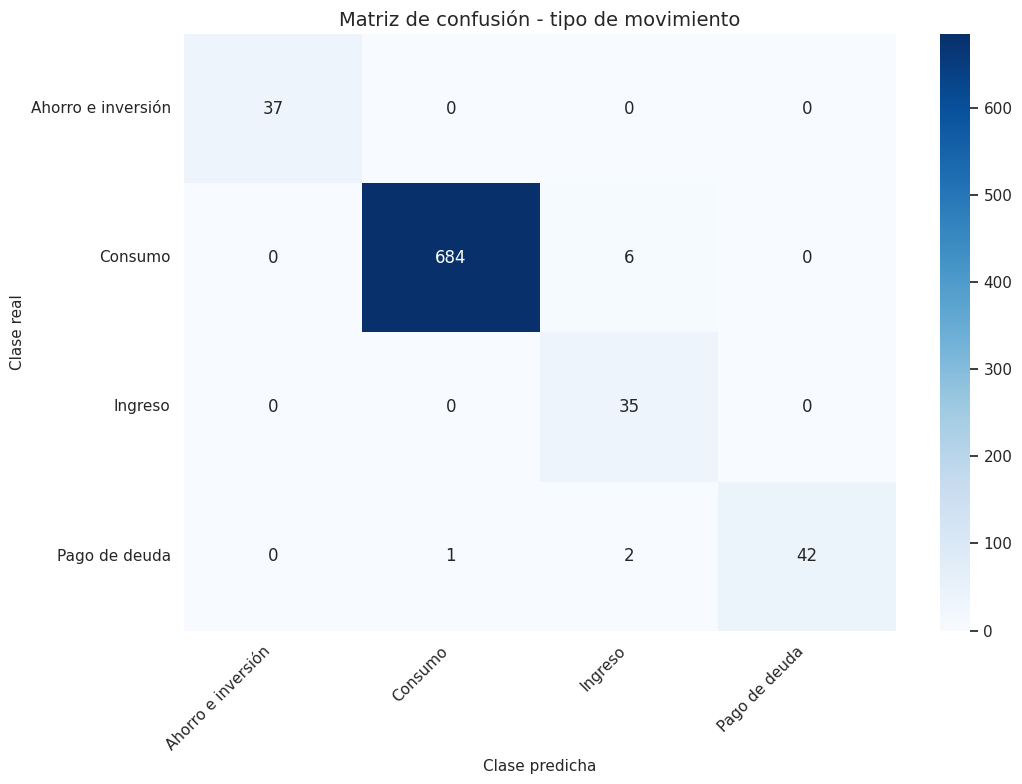

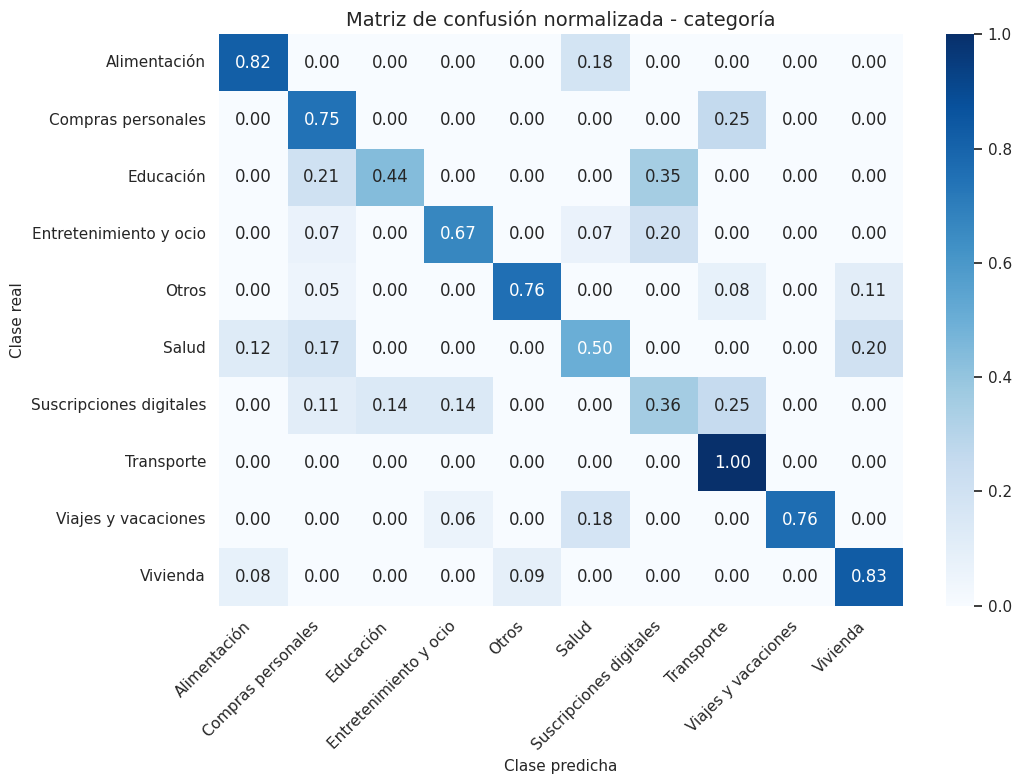

In [ ]:
try:
    from IPython.display import display
except ImportError:
    display = print


def graficar_matriz_confusion(
    y_real,
    y_predicha,
    titulo,
    normalizar=False
):
    etiquetas = sorted(pd.Series(y_real).unique())
    normalizacion = "true" if normalizar else None

    matriz = confusion_matrix(
        y_real,
        y_predicha,
        labels=etiquetas,
        normalize=normalizacion
    )

    plt.figure(figsize=(11, 8))
    sns.heatmap(
        matriz,
        annot=True,
        fmt=".2f" if normalizar else "g",
        cmap="Blues",
        xticklabels=etiquetas,
        yticklabels=etiquetas
    )
    plt.title(titulo)
    plt.xlabel("Clase predicha")
    plt.ylabel("Clase real")
    plt.xticks(rotation=45, ha="right")
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()


graficar_matriz_confusion(
    test_movimiento["tipo_movimiento"],
    pred_movimiento,
    "Matriz de confusión - tipo de movimiento"
)

graficar_matriz_confusion(
    test_categoria["categoria"],
    pred_categoria,
    "Matriz de confusión normalizada - categoría",
    normalizar=True
)


## **Ejemplos clasificados incorrectamente**

Las tablas siguientes permiten revisar descripciones concretas y detectar si
los errores provienen de ambigüedad semántica, vocabulario insuficiente o
etiquetas que requieren mayor contexto.


In [ ]:
errores_movimiento = (
    test_movimiento.loc[
        test_movimiento["tipo_movimiento"].to_numpy()
        != pred_movimiento,
        ["descripcion", "descripcion_limpia", "tipo_movimiento"]
    ]
    .assign(prediccion=pred_movimiento[
        test_movimiento["tipo_movimiento"].to_numpy()
        != pred_movimiento
    ])
    .rename(columns={"tipo_movimiento": "clase_real"})
)

errores_categoria = (
    test_categoria.loc[
        test_categoria["categoria"].to_numpy()
        != pred_categoria,
        ["descripcion", "descripcion_limpia", "categoria"]
    ]
    .assign(prediccion=pred_categoria[
        test_categoria["categoria"].to_numpy()
        != pred_categoria
    ])
    .rename(columns={"categoria": "clase_real"})
)

print("Errores de tipo de movimiento:", len(errores_movimiento))
display(errores_movimiento.head(20))

print("Errores de categoría:", len(errores_categoria))
display(errores_categoria.head(20))


Errores de tipo de movimiento: 9


,descripcion,descripcion_limpia,clase_real,prediccion
197,pago del carro,pago del carro,Pago de deuda,Consumo
301,pago de donde vivo,pago de donde vivo,Consumo,Ingreso
360,pago de donde vivo,pago de donde vivo,Consumo,Ingreso
418,pago de donde vivo,pago de donde vivo,Consumo,Ingreso
426,pago de donde vivo,pago de donde vivo,Consumo,Ingreso
444,pago de donde vivo,pago de donde vivo,Consumo,Ingreso
647,pago de donde vivo,pago de donde vivo,Consumo,Ingreso
717,pago de financiamiento,pago de financiamiento,Pago de deuda,Ingreso
751,pago de financiamiento,pago de financiamiento,Pago de deuda,Ingreso


Errores de categoría: 139


,descripcion,descripcion_limpia,clase_real,prediccion
7,Xbox Game Pass,xbox game pass,Suscripciones digitales,Transporte
19,pan y tortillas,pan y tortillas,Alimentación,Salud
22,pan y tortillas,pan y tortillas,Alimentación,Salud
33,compré cuadernos,compré cuadernos,Educación,Compras personales
35,almacenamiento en la nube,almacenamiento en la nube,Suscripciones digitales,Educación
40,pan y tortillas,pan y tortillas,Alimentación,Salud
41,pan y tortillas,pan y tortillas,Alimentación,Salud
46,me hice unos estudios,me hice unos estudios,Salud,Compras personales
49,Dropbox,dropbox,Suscripciones digitales,Compras personales
50,plataforma para estudiar,plataforma para estudiar,Educación,Suscripciones digitales


## **Análisis específico de la clase Ingreso**

En lugar de fijar cantidades manualmente, el análisis se calcula a partir de
las predicciones vigentes. Así seguirá siendo correcto después de cambiar el
split o reentrenar el modelo.


In [ ]:
mascara_ingreso = (
    test_movimiento["tipo_movimiento"].to_numpy()
    == "Ingreso"
)

analisis_ingreso = (
    pd.Series(
        pred_movimiento[mascara_ingreso],
        name="clase_predicha"
    )
    .value_counts()
    .rename_axis("clase_predicha")
    .reset_index(name="cantidad")
)

analisis_ingreso["porcentaje"] = (
    analisis_ingreso["cantidad"]
    / max(mascara_ingreso.sum(), 1)
    * 100
).round(2)

display(analisis_ingreso)

errores_ingreso = errores_movimiento[
    errores_movimiento["clase_real"] == "Ingreso"
]

display(errores_ingreso.head(20))


,clase_predicha,cantidad,porcentaje
0,Ingreso,35,100.0


,descripcion,descripcion_limpia,clase_real,prediccion


## **Análisis de la confusión Alimentación → Vivienda**

In [ ]:
mascara_alimentacion_vivienda = (
    (test_categoria["categoria"].to_numpy() == "Alimentación")
    & (pred_categoria == "Vivienda")
)

confusion_alimentacion_vivienda = (
    test_categoria.loc[
        mascara_alimentacion_vivienda,
        ["descripcion", "descripcion_limpia", "monto", "tipo_pago"]
    ]
    .assign(
        clase_real="Alimentación",
        prediccion="Vivienda"
    )
)

print(
    "Casos Alimentación → Vivienda:",
    len(confusion_alimentacion_vivienda)
)

display(confusion_alimentacion_vivienda.head(30))


Casos Alimentación → Vivienda: 0


,descripcion,descripcion_limpia,monto,tipo_pago,clase_real,prediccion


## **Palabras y fragmentos con mayor influencia por clase**

Los coeficientes positivos más altos muestran las características que empujan
la predicción hacia cada clase. El prefijo `palabras__` identifica unigramas o
bigramas y `caracteres__` identifica fragmentos de caracteres.


In [ ]:
def obtener_caracteristicas_influyentes(
    pipeline,
    n_caracteristicas=15
):
    extractor = pipeline.named_steps["tfidf"]
    clasificador = pipeline.named_steps["clasificador"]

    nombres = extractor.get_feature_names_out()
    coeficientes = clasificador.coef_
    clases = clasificador.classes_

    filas = []

    for indice_clase, clase in enumerate(clases):
        indices = np.argsort(
            coeficientes[indice_clase]
        )[-n_caracteristicas:][::-1]

        for posicion, indice_feature in enumerate(indices, start=1):
            filas.append({
                "clase": clase,
                "posicion": posicion,
                "caracteristica": nombres[indice_feature],
                "coeficiente": coeficientes[
                    indice_clase,
                    indice_feature
                ]
            })

    return pd.DataFrame(filas)


influencia_movimiento = obtener_caracteristicas_influyentes(
    pipeline_movimiento
)

influencia_categoria = obtener_caracteristicas_influyentes(
    pipeline_categoria
)

display(influencia_movimiento)
display(influencia_categoria)


,clase,posicion,caracteristica,coeficiente
0,Ahorro e inversión,1,palabras__cetes,0.927689
1,Ahorro e inversión,2,palabras__un etf,0.891954
2,Ahorro e inversión,3,palabras__etf,0.891954
3,Ahorro e inversión,4,palabras__bonos,0.796151
4,Ahorro e inversión,5,palabras__ahorro,0.760305
5,Ahorro e inversión,6,palabras__fondo,0.740542
6,Ahorro e inversión,7,palabras__compre bonos,0.681560
7,Ahorro e inversión,8,palabras__pagare,0.662962
8,Ahorro e inversión,9,caracteres__etf,0.649093
9,Ahorro e inversión,10,palabras__aportacion,0.637621


,clase,posicion,caracteristica,coeficiente
0,Alimentación,1,palabras__pollo,2.028342
1,Alimentación,2,palabras__abarrotes,1.974836
2,Alimentación,3,palabras__para la,1.883467
3,Alimentación,4,palabras__mandado,1.813531
4,Alimentación,5,palabras__despensa,1.805480
...,...,...,...,...
145,Vivienda,11,caracteres__ gas,1.378621
146,Vivienda,12,palabras__la,1.250013
147,Vivienda,13,palabras__de,1.241617
148,Vivienda,14,palabras__refrigerador,1.238955


# **Optimización controlada de hiperparámetros**

La búsqueda utiliza un conjunto pequeño y explícito de configuraciones. No se
emplea el conjunto de prueba para seleccionar hiperparámetros: cada alternativa
se evalúa exclusivamente dentro de `train` mediante `StratifiedGroupKFold`,
manteniendo agrupadas las descripciones idénticas.

Para mantener controlado el costo computacional, se modifica un factor principal
por configuración respecto a la base, en lugar de construir un producto
cartesiano grande.


In [ ]:
def crear_extractor_tfidf_configurable(configuracion):
    tfidf_palabras = TfidfVectorizer(
        lowercase=True,
        strip_accents="unicode",
        analyzer="word",
        ngram_range=configuracion["ngram_palabras"],
        min_df=1,
        max_df=0.95,
        sublinear_tf=True,
        norm="l2",
        dtype=np.float32
    )

    tfidf_caracteres = TfidfVectorizer(
        lowercase=True,
        strip_accents="unicode",
        analyzer="char_wb",
        ngram_range=configuracion["ngram_caracteres"],
        min_df=2,
        max_df=1.0,
        sublinear_tf=True,
        norm="l2",
        dtype=np.float32
    )

    return FeatureUnion(
        transformer_list=[
            ("palabras", tfidf_palabras),
            ("caracteres", tfidf_caracteres)
        ],
        transformer_weights={
            "palabras": configuracion["peso_palabras"],
            "caracteres": configuracion["peso_caracteres"]
        }
    )


def crear_pipeline_configurable(tarea, configuracion):
    if tarea == "movimiento":
        clasificador = LinearSVC(
            C=configuracion["C"],
            class_weight=configuracion["class_weight"],
            random_state=42
        )
    elif tarea == "categoria":
        clasificador = LogisticRegression(
            C=configuracion["C"],
            class_weight=configuracion["class_weight"],
            max_iter=3000,
            solver="lbfgs",
            random_state=42
        )
    else:
        raise ValueError("Tarea desconocida.")

    return Pipeline(
        steps=[
            (
                "tfidf",
                crear_extractor_tfidf_configurable(configuracion)
            ),
            ("clasificador", clasificador)
        ]
    )


In [ ]:
CONFIGURACION_BASE_MOVIMIENTO = {
    "nombre": "base",
    "C": 1.0,
    "peso_palabras": 1.0,
    "peso_caracteres": 1.0,
    "ngram_palabras": (1, 2),
    "ngram_caracteres": (3, 5),
    "class_weight": "balanced"
}

CONFIGURACION_BASE_CATEGORIA = {
    **CONFIGURACION_BASE_MOVIMIENTO,
    "C": 2.0
}


def variar(base, nombre, **cambios):
    configuracion = {**base, **cambios}
    configuracion["nombre"] = nombre
    return configuracion


configuraciones_movimiento = [
    CONFIGURACION_BASE_MOVIMIENTO,
    variar(CONFIGURACION_BASE_MOVIMIENTO, "C_0.5", C=0.5),
    variar(CONFIGURACION_BASE_MOVIMIENTO, "C_2.0", C=2.0),
    variar(CONFIGURACION_BASE_MOVIMIENTO, "mas_palabras", peso_palabras=1.5),
    variar(CONFIGURACION_BASE_MOVIMIENTO, "mas_caracteres", peso_caracteres=1.5),
    variar(CONFIGURACION_BASE_MOVIMIENTO, "solo_unigramas", ngram_palabras=(1, 1)),
    variar(CONFIGURACION_BASE_MOVIMIENTO, "char_2_5", ngram_caracteres=(2, 5)),
    variar(CONFIGURACION_BASE_MOVIMIENTO, "sin_balanceo", class_weight=None)
]

configuraciones_categoria = [
    CONFIGURACION_BASE_CATEGORIA,
    variar(CONFIGURACION_BASE_CATEGORIA, "C_1.0", C=1.0),
    variar(CONFIGURACION_BASE_CATEGORIA, "C_4.0", C=4.0),
    variar(CONFIGURACION_BASE_CATEGORIA, "mas_palabras", peso_palabras=1.5),
    variar(CONFIGURACION_BASE_CATEGORIA, "mas_caracteres", peso_caracteres=1.5),
    variar(CONFIGURACION_BASE_CATEGORIA, "solo_unigramas", ngram_palabras=(1, 1)),
    variar(CONFIGURACION_BASE_CATEGORIA, "char_2_5", ngram_caracteres=(2, 5)),
    variar(CONFIGURACION_BASE_CATEGORIA, "sin_balanceo", class_weight=None)
]


In [ ]:
def evaluar_configuraciones_agrupadas(
    datos_train,
    columna_objetivo,
    tarea,
    configuraciones,
    n_splits=5,
    random_state=123
):
    X = datos_train["descripcion_limpia"].reset_index(drop=True)
    y = datos_train[columna_objetivo].reset_index(drop=True)
    grupos = datos_train["descripcion_limpia"].reset_index(drop=True)

    resultados = []

    for configuracion in configuraciones:
        cv = StratifiedGroupKFold(
            n_splits=n_splits,
            shuffle=True,
            random_state=random_state
        )

        scores = []

        for indice_train, indice_validacion in cv.split(X, y, grupos):
            pipeline = crear_pipeline_configurable(
                tarea,
                configuracion
            )

            pipeline.fit(
                X.iloc[indice_train],
                y.iloc[indice_train]
            )

            prediccion = pipeline.predict(
                X.iloc[indice_validacion]
            )

            scores.append(
                f1_score(
                    y.iloc[indice_validacion],
                    prediccion,
                    average="macro",
                    zero_division=0
                )
            )

        resultados.append({
            "configuracion": configuracion["nombre"],
            "f1_macro_cv": np.mean(scores),
            "f1_macro_std": np.std(scores),
            "parametros": configuracion
        })

    return (
        pd.DataFrame(resultados)
        .sort_values("f1_macro_cv", ascending=False)
        .reset_index(drop=True)
    )


## **Búsqueda para tipo de movimiento**

In [ ]:
resultados_optimizacion_movimiento = (
    evaluar_configuraciones_agrupadas(
        datos_train=train_movimiento,
        columna_objetivo="tipo_movimiento",
        tarea="movimiento",
        configuraciones=configuraciones_movimiento
    )
)

display(
    resultados_optimizacion_movimiento[
        ["configuracion", "f1_macro_cv", "f1_macro_std"]
    ]
)


,configuracion,f1_macro_cv,f1_macro_std
0,mas_caracteres,0.849487,0.043691
1,sin_balanceo,0.848417,0.040266
2,base,0.843561,0.041022
3,C_2.0,0.843561,0.041022
4,char_2_5,0.843561,0.041022
5,C_0.5,0.834279,0.052473
6,mas_palabras,0.831739,0.055995
7,solo_unigramas,0.816816,0.021400


## **Búsqueda para categoría**

In [ ]:
resultados_optimizacion_categoria = (
    evaluar_configuraciones_agrupadas(
        datos_train=train_categoria,
        columna_objetivo="categoria",
        tarea="categoria",
        configuraciones=configuraciones_categoria
    )
)

display(
    resultados_optimizacion_categoria[
        ["configuracion", "f1_macro_cv", "f1_macro_std"]
    ]
)


,configuracion,f1_macro_cv,f1_macro_std
0,C_4.0,0.620338,0.021572
1,solo_unigramas,0.619432,0.030816
2,C_1.0,0.615061,0.027418
3,char_2_5,0.614869,0.031442
4,base,0.613632,0.024893
5,mas_palabras,0.612317,0.030588
6,sin_balanceo,0.611195,0.015686
7,mas_caracteres,0.605665,0.033197


## **Selección, reentrenamiento y evaluación final**

El pipeline actual solo se reemplaza cuando otra configuración supera el macro
F1 de la configuración base en la validación cruzada de `train`. Después de la
selección se ajusta con todo `train` y se evalúa una vez sobre `test`.


In [ ]:
def seleccionar_configuracion(
    resultados,
    configuraciones
):
    puntuacion_base = resultados.loc[
        resultados["configuracion"] == "base",
        "f1_macro_cv"
    ].iloc[0]

    mejor_fila = resultados.iloc[0]
    mejora = mejor_fila["f1_macro_cv"] > puntuacion_base + 1e-6

    nombre_seleccionado = (
        mejor_fila["configuracion"]
        if mejora
        else "base"
    )

    configuracion = next(
        config
        for config in configuraciones
        if config["nombre"] == nombre_seleccionado
    )

    return configuracion, mejora, puntuacion_base


config_movimiento, mejora_movimiento, f1_base_movimiento = (
    seleccionar_configuracion(
        resultados_optimizacion_movimiento,
        configuraciones_movimiento
    )
)

config_categoria, mejora_categoria, f1_base_categoria = (
    seleccionar_configuracion(
        resultados_optimizacion_categoria,
        configuraciones_categoria
    )
)

pipeline_movimiento = crear_pipeline_configurable(
    "movimiento",
    config_movimiento
)
pipeline_movimiento.fit(
    train_movimiento["descripcion_limpia"],
    train_movimiento["tipo_movimiento"]
)

pipeline_categoria = crear_pipeline_configurable(
    "categoria",
    config_categoria
)
pipeline_categoria.fit(
    train_categoria["descripcion_limpia"],
    train_categoria["categoria"]
)

pred_movimiento = pipeline_movimiento.predict(
    test_movimiento["descripcion_limpia"]
)
pred_categoria = pipeline_categoria.predict(
    test_categoria["descripcion_limpia"]
)

metricas_movimiento = calcular_metricas(
    test_movimiento["tipo_movimiento"],
    pred_movimiento
)
metricas_categoria = calcular_metricas(
    test_categoria["categoria"],
    pred_categoria
)

metricas_finales_optimizadas = pd.DataFrame({
    "Tipo de movimiento": metricas_movimiento,
    "Categoría": metricas_categoria
}).T

resumen_seleccion = pd.DataFrame([
    {
        "tarea": "Tipo de movimiento",
        "configuracion": config_movimiento["nombre"],
        "reemplazo_la_base": mejora_movimiento,
        "f1_macro_cv_base": f1_base_movimiento,
        "f1_macro_test_final": metricas_movimiento["f1_macro"]
    },
    {
        "tarea": "Categoría",
        "configuracion": config_categoria["nombre"],
        "reemplazo_la_base": mejora_categoria,
        "f1_macro_cv_base": f1_base_categoria,
        "f1_macro_test_final": metricas_categoria["f1_macro"]
    }
])

display(resumen_seleccion)
display(metricas_finales_optimizadas.round(4))


,tarea,configuracion,reemplazo_la_base,f1_macro_cv_base,f1_macro_test_final
0,Tipo de movimiento,mas_caracteres,True,0.843561,0.970687
1,Categoría,C_4.0,True,0.613632,0.703992


,accuracy,balanced_accuracy,f1_macro,f1_weighted
Tipo de movimiento,0.9901,0.9867,0.9707,0.9903
Categoría,0.7848,0.6879,0.7040,0.7864


La decisión de reemplazo se basa exclusivamente en la validación
cruzada agrupada dentro de entrenamiento. Las métricas de prueba se reportan
como estimación final de generalización y no intervienen en la elección de
hiperparámetros. Los objetos `pipeline_movimiento` y `pipeline_categoria` que
continúan hacia la sección de serialización corresponden a las configuraciones
seleccionadas.


## **Serialización**

#### **Guarda ambos pipelines completos**

In [131]:
from pathlib import Path

directorio_modelos = Path("modelos")
directorio_modelos.mkdir(
    parents=True,
    exist_ok=True
)

In [132]:
ruta_pipeline_movimiento = (
    directorio_modelos
    / "pipeline_tipo_movimiento.joblib"
)

ruta_pipeline_categoria = (
    directorio_modelos
    / "pipeline_categoria.joblib"
)

joblib.dump(
    pipeline_movimiento,
    ruta_pipeline_movimiento,
    compress=3
)

joblib.dump(
    pipeline_categoria,
    ruta_pipeline_categoria,
    compress=3
)

['modelos\\pipeline_categoria.joblib']

Cada archivo contiene:
TF-IDF de palabras
        +
TF-IDF de caracteres
        +
Clasificador entrenado
        +
Vocabulario
        +
Pesos aprendidos
        +
Nombres de las clases

#### **Recarga de los pipelines**

In [133]:
pipeline_movimiento_recargado = joblib.load(
    ruta_pipeline_movimiento
)

pipeline_categoria_recargado = joblib.load(
    ruta_pipeline_categoria
)

#### **Verifica que la serialización no cambió predicciones**

In [134]:
pred_movimiento_recargado = (
    pipeline_movimiento_recargado.predict(
        test_movimiento["descripcion_limpia"]
    )
)

pred_categoria_recargado = (
    pipeline_categoria_recargado.predict(
        test_categoria["descripcion_limpia"]
    )
)

assert np.array_equal(
    pred_movimiento,
    pred_movimiento_recargado
)

assert np.array_equal(
    pred_categoria,
    pred_categoria_recargado
)

print("Los pipelines recargados producen las mismas predicciones.")

Los pipelines recargados producen las mismas predicciones.


#### **Prueba con texto nuevo**

In [135]:
#Tipo de movimiento

ejemplos_movimiento = [
    "ME CAYÓ LA NÓMINA",
    "Pagué todo lo de la tarjeta",
    "aparté dinero para ahorrar"
]

pipeline_movimiento_recargado.predict(
    ejemplos_movimiento
)

array(['Ingreso', 'Pago de deuda', 'Ahorro e inversión'], dtype=object)

In [136]:
#Categoría
ejemplos_categoria = [
    "compré comida para la semana",
    "pagué el camión",
    "fui al doctor"
]

pipeline_categoria_recargado.predict(
    ejemplos_categoria
)

array(['Alimentación', 'Transporte', 'Salud'], dtype=object)

**Conclusión:** Se compararon tres algoritmos utilizando validación cruzada estratificada y agrupada dentro del conjunto de entrenamiento. La selección se realizó mediante macro F1 para considerar el desempeño de todas las clases, incluidas aquellas con menor representación.

LinearSVC obtuvo el mejor resultado para la clasificación del tipo de movimiento, mientras que la regresión logística obtuvo el mejor macro F1 para la clasificación de categorías. Ambos modelos fueron integrados con sus correspondientes extractores TF-IDF mediante objetos Pipeline.

Los pipelines completos fueron serializados con joblib y posteriormente recargados. Las predicciones obtenidas después de la recarga fueron idénticas a las originales, reduciendo el riesgo de inconsistencias entre el notebook de entrenamiento y el entorno de producción.

# **Integración con motor financiero**

El contrato de entrada de la API contiene `usuario` (UUID y nombre), `periodo`,
`ingresos` ya identificados y `transacciones` todavía sin clasificar.

El flujo de integración es:

1. Validar el JSON de entrada.
2. Convertir únicamente `transacciones` a un DataFrame.
3. Clasificar tipo de movimiento y, cuando corresponda, categoría.
4. Conservar los ingresos recibidos y construir el diccionario clasificado.
5. Validar el contrato de salida antes de enviarlo al motor financiero.


## **Importación y carga de modelos**

In [ ]:
import json
import joblib
import pandas as pd

from pathlib import Path
from uuid import UUID

In [ ]:
#carga de pipelines completos
pipeline_movimiento = joblib.load(
    "modelos/pipeline_tipo_movimiento.joblib"
)

pipeline_categoria = joblib.load(
    "modelos/pipeline_categoria.joblib"
)

## **Mapeo de categorías a grupos**

In [ ]:
GRUPO_POR_CATEGORIA = {
    "Vivienda": "Esencial",
    "Alimentación": "Esencial",
    "Transporte": "Esencial",
    "Salud": "Esencial",
    "Educación": "Esencial",

    "Entretenimiento y ocio": "Discrecional",
    "Suscripciones digitales": "Discrecional",
    "Compras personales": "Discrecional",
    "Viajes y vacaciones": "Discrecional",
    "Otros": "Discrecional"
}


In [140]:
CLASIFICACIONES_VALIDAS = {
    "Consumo",
    "Pago de deuda",
    "Ahorro e inversión"
}

#Ingreso no aparece en transacciones, porque se mueve a la lista ingresos.

## **Validación y adaptación de la entrada de la API**

Estas funciones validan el contrato de entrada y convierten solamente la lista
`transacciones` a la estructura tabular requerida por los clasificadores. Los
ingresos ya identificados no vuelven a pasar por el modelo.


In [ ]:
def convertir_fecha_iso(valor):
    return pd.to_datetime(
        valor,
        format="%Y-%m-%d",
        errors="raise"
    ).strftime("%Y-%m-%d")


def convertir_uuid(valor):
    """Valida y normaliza un identificador UUID."""
    try:
        return str(UUID(str(valor)))
    except (ValueError, TypeError, AttributeError) as error:
        raise ValueError(
            "usuario.id debe contener un UUID válido."
        ) from error


In [ ]:
def convertir_monto(valor):
    """Valida y convierte un monto a un tipo compatible con JSON."""
    monto = float(valor)

    if not pd.notna(monto) or monto <= 0:
        raise ValueError(
            "Todos los montos deben ser finitos y mayores que cero."
        )

    return round(monto, 2)


In [ ]:
def validar_json_entrada(datos_entrada):
    """Valida el contrato recibido desde la API."""
    if not isinstance(datos_entrada, dict):
        raise TypeError("El JSON de entrada debe ser un diccionario.")

    if set(datos_entrada) != {
        "usuario", "periodo", "ingresos", "transacciones"
    }:
        raise ValueError(
            "La raíz debe contener usuario, periodo, ingresos y transacciones."
        )

    usuario = datos_entrada["usuario"]
    periodo = datos_entrada["periodo"]
    ingresos = datos_entrada["ingresos"]
    transacciones = datos_entrada["transacciones"]

    if not isinstance(usuario, dict) or set(usuario) != {"id", "nombre"}:
        raise ValueError("usuario debe contener únicamente id y nombre.")

    convertir_uuid(usuario["id"])

    if not isinstance(usuario["nombre"], str) or not usuario["nombre"].strip():
        raise ValueError("usuario.nombre no puede estar vacío.")

    if not isinstance(periodo, dict) or set(periodo) != {"inicio", "fin"}:
        raise ValueError("periodo debe contener únicamente inicio y fin.")

    inicio = convertir_fecha_iso(periodo["inicio"])
    fin = convertir_fecha_iso(periodo["fin"])

    if inicio > fin:
        raise ValueError("periodo.inicio no puede ser posterior a periodo.fin.")

    if not isinstance(ingresos, list):
        raise TypeError("ingresos debe ser una lista.")

    if not isinstance(transacciones, list):
        raise TypeError("transacciones debe ser una lista.")

    for indice, ingreso in enumerate(ingresos):
        if not isinstance(ingreso, dict) or set(ingreso) != {
            "fecha", "descripcion", "monto"
        }:
            raise ValueError(
                f"ingresos[{indice}] debe contener fecha, descripcion y monto."
            )

        fecha = convertir_fecha_iso(ingreso["fecha"])
        if not inicio <= fecha <= fin:
            raise ValueError(f"ingresos[{indice}].fecha está fuera del periodo.")

        if not isinstance(ingreso["descripcion"], str) or not ingreso["descripcion"].strip():
            raise ValueError(f"ingresos[{indice}].descripcion no puede estar vacía.")

        convertir_monto(ingreso["monto"])

    campos_base = {"fecha", "descripcion", "monto", "forma_pago"}
    campo_tasa = "tasa_de_interes_de_la_tarjeta"

    for indice, transaccion in enumerate(transacciones):
        if not isinstance(transaccion, dict):
            raise TypeError(f"transacciones[{indice}] debe ser un diccionario.")

        campos_permitidos = campos_base | {campo_tasa}
        if not campos_base.issubset(transaccion):
            raise ValueError(f"Faltan campos en transacciones[{indice}].")
        if set(transaccion) - campos_permitidos:
            raise ValueError(f"Hay campos desconocidos en transacciones[{indice}].")

        fecha = convertir_fecha_iso(transaccion["fecha"])
        if not inicio <= fecha <= fin:
            raise ValueError(f"transacciones[{indice}].fecha está fuera del periodo.")

        if not isinstance(transaccion["descripcion"], str) or not transaccion["descripcion"].strip():
            raise ValueError(f"transacciones[{indice}].descripcion no puede estar vacía.")

        convertir_monto(transaccion["monto"])

        forma_pago = transaccion["forma_pago"]
        if not isinstance(forma_pago, str) or not forma_pago.strip():
            raise ValueError(f"transacciones[{indice}].forma_pago no puede estar vacía.")

        es_credito = forma_pago == "Tarjeta de crédito"
        tiene_tasa = campo_tasa in transaccion

        if es_credito != tiene_tasa:
            raise ValueError(
                f"transacciones[{indice}] debe incluir la tasa únicamente "
                "cuando utiliza Tarjeta de crédito."
            )

        if tiene_tasa:
            convertir_monto(transaccion[campo_tasa])

    json.dumps(
        datos_entrada,
        ensure_ascii=False,
        allow_nan=False
    )

    return True


def convertir_json_entrada_a_dataframe(datos_entrada):
    """Convierte las transacciones del JSON validado a un DataFrame."""
    usuario = datos_entrada["usuario"]
    periodo = datos_entrada["periodo"]

    columnas = [
        "user_id",
        "nombre",
        "periodo_inicio",
        "periodo_fin",
        "fecha",
        "descripcion",
        "monto",
        "tipo_pago",
        "tasa_de_interes_de_la_tarjeta"
    ]

    filas = []

    for transaccion in datos_entrada["transacciones"]:
        filas.append({
            "user_id": convertir_uuid(usuario["id"]),
            "nombre": usuario["nombre"].strip(),
            "periodo_inicio": periodo["inicio"],
            "periodo_fin": periodo["fin"],
            "fecha": transaccion["fecha"],
            "descripcion": transaccion["descripcion"],
            "monto": transaccion["monto"],
            "tipo_pago": transaccion["forma_pago"],
            "tasa_de_interes_de_la_tarjeta": transaccion.get(
                "tasa_de_interes_de_la_tarjeta"
            )
        })

    return pd.DataFrame(filas, columns=columnas)


## **Función principal de clasificación**

La función recibe el DataFrame creado a partir de `transacciones` y el JSON de
entrada original. Conserva los ingresos recibidos y clasifica en lote las
transacciones.


In [ ]:
def clasificar_usuario(
    datos_usuario,
    datos_entrada,
    pipeline_movimiento,
    pipeline_categoria
):
    columnas_requeridas = {
        "user_id",
        "nombre",
        "periodo_inicio",
        "periodo_fin",
        "fecha",
        "descripcion",
        "monto",
        "tipo_pago",
        "tasa_de_interes_de_la_tarjeta"
    }

    columnas_faltantes = columnas_requeridas.difference(datos_usuario.columns)
    if columnas_faltantes:
        raise ValueError(f"Faltan columnas: {sorted(columnas_faltantes)}")

    datos = datos_usuario.copy().reset_index(drop=True)
    datos["_orden_original"] = range(len(datos))

    if not datos.empty:
        datos["fecha"] = pd.to_datetime(
            datos["fecha"],
            format="%Y-%m-%d",
            errors="raise"
        )
        datos = datos.sort_values(["fecha", "_orden_original"], kind="stable")

    usuario = datos_entrada["usuario"]
    periodo = datos_entrada["periodo"]
    usuario_id = convertir_uuid(usuario["id"])
    nombre = usuario["nombre"].strip()
    periodo_inicio = convertir_fecha_iso(periodo["inicio"])
    periodo_fin = convertir_fecha_iso(periodo["fin"])

    ingresos = [
        {
            "fecha": convertir_fecha_iso(ingreso["fecha"]),
            "descripcion": ingreso["descripcion"].strip(),
            "monto": convertir_monto(ingreso["monto"])
        }
        for ingreso in datos_entrada["ingresos"]
    ]

    if datos.empty:
        predicciones_movimiento = []
        categoria_por_indice = {}
    else:
        textos = datos["descripcion"].astype(str).tolist()
        predicciones_movimiento = pipeline_movimiento.predict(textos)

        indices_consumo = [
            indice
            for indice, movimiento in enumerate(predicciones_movimiento)
            if str(movimiento) == "Consumo"
        ]

        if indices_consumo:
            categorias_consumo = pipeline_categoria.predict(
                [textos[indice] for indice in indices_consumo]
            )
        else:
            categorias_consumo = []

        categoria_por_indice = {
            indice: str(categoria)
            for indice, categoria in zip(indices_consumo, categorias_consumo)
        }

    transacciones = []

    for posicion, ((_, fila), movimiento) in enumerate(
        zip(datos.iterrows(), predicciones_movimiento)
    ):
        movimiento = str(movimiento)

        datos_base = {
            "fecha": convertir_fecha_iso(fila["fecha"]),
            "descripcion": str(fila["descripcion"]).strip(),
            "monto": convertir_monto(fila["monto"])
        }

        # Si una entrada fue colocada por error en transacciones y el modelo
        # la reconoce como ingreso, se integra a la lista de ingresos.
        if movimiento == "Ingreso":
            ingresos.append(datos_base)
            continue

        if movimiento not in CLASIFICACIONES_VALIDAS:
            raise ValueError(f"Clasificación desconocida: {movimiento}")

        forma_pago = str(fila["tipo_pago"])
        transaccion = {**datos_base, "forma_pago": forma_pago}

        if forma_pago == "Tarjeta de crédito":
            tasa = fila["tasa_de_interes_de_la_tarjeta"]
            if pd.isna(tasa):
                raise ValueError(
                    "Una operación con tarjeta de crédito debe incluir su tasa de interés."
                )
            transaccion["tasa_de_interes_de_la_tarjeta"] = round(float(tasa), 2)

        if movimiento == "Consumo":
            categoria = categoria_por_indice[posicion]
            if categoria not in GRUPO_POR_CATEGORIA:
                raise ValueError(f"Categoría desconocida: {categoria}")

            transaccion["clasificacion"] = (
                ["Consumo", "Pago de deuda"]
                if forma_pago == "Tarjeta de crédito"
                else ["Consumo"]
            )
            transaccion["categoria"] = categoria
            transaccion["grupo"] = GRUPO_POR_CATEGORIA[categoria]
        else:
            transaccion["clasificacion"] = [movimiento]

        transacciones.append(transaccion)

    ingresos.sort(key=lambda elemento: elemento["fecha"])

    return {
        "usuario": {
            "id": usuario_id,
            "nombre": nombre
        },
        "periodo": {
            "inicio": periodo_inicio,
            "fin": periodo_fin
        },
        "ingresos": ingresos,
        "transacciones": transacciones
    }


## **Validación del contrato de salida y función integradora**

In [ ]:
def validar_contrato_json(datos_clasificados):
    """Valida el diccionario producido para el motor financiero."""
    if set(datos_clasificados) != {
        "usuario", "periodo", "ingresos", "transacciones"
    }:
        raise ValueError("La raíz del JSON clasificado no cumple el contrato.")

    if set(datos_clasificados["usuario"]) != {"id", "nombre"}:
        raise ValueError("usuario debe contener id y nombre.")

    convertir_uuid(datos_clasificados["usuario"]["id"])

    if set(datos_clasificados["periodo"]) != {"inicio", "fin"}:
        raise ValueError("periodo debe contener inicio y fin.")

    for ingreso in datos_clasificados["ingresos"]:
        if set(ingreso) != {"fecha", "descripcion", "monto"}:
            raise ValueError("Un ingreso no cumple el contrato.")

    campos_base = {
        "fecha", "descripcion", "monto", "forma_pago", "clasificacion"
    }

    for transaccion in datos_clasificados["transacciones"]:
        if not campos_base.issubset(transaccion):
            raise ValueError("Una transacción no contiene todos los campos base.")

        es_consumo = "Consumo" in transaccion["clasificacion"]
        es_credito = transaccion["forma_pago"] == "Tarjeta de crédito"

        if ("categoria" in transaccion) != es_consumo:
            raise ValueError("categoria debe existir únicamente en consumos.")
        if ("grupo" in transaccion) != es_consumo:
            raise ValueError("grupo debe existir únicamente en consumos.")
        if ("tasa_de_interes_de_la_tarjeta" in transaccion) != es_credito:
            raise ValueError("La presencia de la tasa no coincide con la forma de pago.")

        if es_consumo:
            categoria = transaccion["categoria"]
            if transaccion["grupo"] != GRUPO_POR_CATEGORIA[categoria]:
                raise ValueError("El grupo no corresponde a la categoría.")

    json.dumps(
        datos_clasificados,
        ensure_ascii=False,
        allow_nan=False
    )

    return True


def ejecutar_clasificacion(
    datos_entrada,
    pipeline_movimiento,
    pipeline_categoria
):
    """Ejecuta validación, adaptación, clasificación y validación de salida."""
    validar_json_entrada(datos_entrada)

    datos_usuario = convertir_json_entrada_a_dataframe(datos_entrada)

    datos_clasificados = clasificar_usuario(
        datos_usuario=datos_usuario,
        datos_entrada=datos_entrada,
        pipeline_movimiento=pipeline_movimiento,
        pipeline_categoria=pipeline_categoria
    )

    validar_contrato_json(datos_clasificados)

    return datos_clasificados


## **Aplicación al JSON recibido desde la API**

### **Ejemplo de entrada con UUID**

In [ ]:
datos_entrada = {
    "usuario": {
        "id": "8f7c2b91-3d64-4a12-9e58-71c6d8f204ab",
        "nombre": "Brayan Lira"
    },
    "periodo": {
        "inicio": "2026-07-01",
        "fin": "2026-07-31"
    },
    "ingresos": [
        {
            "fecha": "2026-07-01",
            "descripcion": "Salario",
            "monto": 25000
        },
        {
            "fecha": "2026-07-15",
            "descripcion": "Proyecto freelance",
            "monto": 4500
        }
    ],
    "transacciones": [
        {
            "fecha": "2026-07-02",
            "descripcion": "Walmart León",
            "monto": 1350,
            "forma_pago": "Tarjeta de débito"
        },
        {
            "fecha": "2026-07-05",
            "descripcion": "Hospital Ángeles",
            "monto": 5800,
            "forma_pago": "Tarjeta de crédito",
            "tasa_de_interes_de_la_tarjeta": 48.5
        },
        {
            "fecha": "2026-07-08",
            "descripcion": "Pago préstamo personal",
            "monto": 3200,
            "forma_pago": "Transferencia bancaria"
        },
        {
            "fecha": "2026-07-12",
            "descripcion": "Netflix",
            "monto": 249,
            "forma_pago": "Tarjeta de crédito",
            "tasa_de_interes_de_la_tarjeta": 48.5
        },
        {
            "fecha": "2026-07-18",
            "descripcion": "Gasolina Pemex",
            "monto": 900,
            "forma_pago": "Efectivo"
        },
        {
            "fecha": "2026-07-22",
            "descripcion": "Aportación fondo de inversión",
            "monto": 2500,
            "forma_pago": "Transferencia bancaria"
        },
        {
            "fecha": "2026-07-26",
            "descripcion": "Liverpool",
            "monto": 4200,
            "forma_pago": "Tarjeta de crédito",
            "tasa_de_interes_de_la_tarjeta": 52.3
        }
    ]
}


In [ ]:
datos_clasificados = ejecutar_clasificacion(
    datos_entrada=datos_entrada,
    pipeline_movimiento=pipeline_movimiento,
    pipeline_categoria=pipeline_categoria
)


In [ ]:
print(
    json.dumps(
        datos_clasificados,
        ensure_ascii=False,
        allow_nan=False,
        indent=2
    )
)


{
  "usuario": {
    "id": "8f7c2b91-3d64-4a12-9e58-71c6d8f204ab",
    "nombre": "Brayan Lira"
  },
  "periodo": {
    "inicio": "2026-07-01",
    "fin": "2026-07-31"
  },
  "ingresos": [
    {
      "fecha": "2026-07-01",
      "descripcion": "Salario",
      "monto": 25000.0
    },
    {
      "fecha": "2026-07-15",
      "descripcion": "Proyecto freelance",
      "monto": 4500.0
    }
  ],
  "transacciones": [
    {
      "fecha": "2026-07-02",
      "descripcion": "Walmart León",
      "monto": 1350.0,
      "forma_pago": "Tarjeta de débito",
      "clasificacion": [
        "Consumo"
      ],
      "categoria": "Compras personales",
      "grupo": "Discrecional"
    },
    {
      "fecha": "2026-07-05",
      "descripcion": "Hospital Ángeles",
      "monto": 5800.0,
      "forma_pago": "Tarjeta de crédito",
      "tasa_de_interes_de_la_tarjeta": 48.5,
      "clasificacion": [
        "Consumo",
        "Pago de deuda"
      ],
      "categoria": "Salud",
      "grupo": "Esencial"


### **Guarda el JSON clasificado**

In [ ]:
ruta_json = "datos_clasificados_ejemplo.json"

with open(ruta_json, "w", encoding="utf-8") as archivo:
    json.dump(
        datos_clasificados,
        archivo,
        ensure_ascii=False,
        allow_nan=False,
        indent=2
    )


In [ ]:
ruta_json

'datos_clasificados_ejemplo.json'

# **Módulo perfiles financieros**

# **Elaboración del Clasificador**

In [151]:
df_clasificacion = df[
    df["tipo_movimiento"] == "Consumo"
].copy()

--------------

# **Implementación de motor financiero**

##  1.- Generación de constantes necesarias para el motor financiero

In [152]:
# ============================================
# Categorías oficiales de consumo del sistema
# ============================================

CATEGORIAS_CONSUMO = [
    "Vivienda",
    "Alimentación",
    "Transporte",
    "Salud",
    "Educación",
    "Entretenimiento y ocio",
    "Suscripciones digitales",
    "Compras personales",
    "Viajes y vacaciones",
    "Otros"
]

In [153]:
PESOS_DIMENSIONES = {

    "balance_financiero": {

        "tasa_de_gasto": 0.50,

        "margen_financiero": 0.50

    },

    "capacidad_de_ahorro": {

        "tasa_de_ahorro": 0.60,

        "aprovechamiento_del_margen_financiero": 0.40

    },

    "endeudamiento": {

        "ratio_de_endeudamiento": 0.40,

        "presion_de_la_deuda": 0.40,

        "costo_promedio_del_endeudamiento": 0.20

    },

    "comportamiento_de_consumo": {

        "indice_de_concentracion_del_gasto": 0.40,

        "predominio_del_gasto": 0.35,

        "diversificacion_del_consumo": 0.25

    }

}

In [154]:
PESOS_PERFIL_FINANCIERO = {

    "balance_financiero": 0.30,

    "capacidad_de_ahorro": 0.25,

    "endeudamiento": 0.25,

    "comportamiento_de_consumo": 0.20

}

In [155]:
# ==========================================================
# Mapeo de categorías para la salida de la API
# ==========================================================

MAPA_CATEGORIAS_API = {

    "Vivienda":
        "vivienda",

    "Alimentación":
        "alimentacion",

    "Transporte":
        "transporte",

    "Salud":
        "salud",

    "Educación":
        "educacion",

    "Entretenimiento y ocio":
        "entretenimiento_y_ocio",

    "Suscripciones digitales":
        "suscripciones_digitales",

    "Compras personales":
        "compras_personales",

    "Viajes y vacaciones":
        "viajes_y_vacaciones",

    "Otros":
        "otros"

}

## 2.- Definición de función para obtener el estado de las dimensiones financieras y del perfil general

In [156]:
def obtener_estado(puntuacion):

    if puntuacion >= 80:
        return "Saludable"

    elif puntuacion >= 50:
        return "En observación"

    else:
        return "En riesgo"

## 3.- Recepción de archivo JSON de prueba ya clasificado manualmente

In [157]:
import json
import random
from pathlib import Path

def cargar_datos_clasificados(carpeta="datos"):
    """
    Selecciona aleatoriamente uno de los archivos JSON clasificados,
    lo convierte a un diccionario y lo devuelve.
    """

    carpeta_json = Path("perfiles_financieros_pruebas_clasificados_para_motor_financiero")

    numero = random.randint(1, 15)

    nombre_archivo = f"{numero:02d}_clasificado_manualmente.json"

    ruta_archivo = carpeta_json / nombre_archivo

    with open(ruta_archivo, "r", encoding="utf-8") as archivo:
        datos = json.load(archivo)

    print(f"Archivo seleccionado: {nombre_archivo}")

    return datos


datos_clasificados = cargar_datos_clasificados()
print (datos_clasificados)

Archivo seleccionado: 15_clasificado_manualmente.json
{'usuario': {'nombre': 'Alejandra Soto'}, 'periodo': {'inicio': '2026-07-01', 'fin': '2026-07-31'}, 'ingresos': [{'fecha': '2026-07-01', 'descripcion': 'Salario', 'monto': 38000}, {'fecha': '2026-07-02', 'descripcion': 'Comisiones de ventas', 'monto': 8500}], 'transacciones': [{'fecha': '2026-07-01', 'descripcion': 'Renta departamento', 'monto': 9000, 'forma_pago': 'Transferencia bancaria', 'clasificacion': ['Consumo'], 'categoria': 'Vivienda', 'grupo': 'Esencial'}, {'fecha': '2026-07-02', 'descripcion': 'Café Starbucks', 'monto': 95, 'forma_pago': 'Tarjeta de débito', 'clasificacion': ['Consumo'], 'categoria': 'Entretenimiento y ocio', 'grupo': 'Discrecional'}, {'fecha': '2026-07-03', 'descripcion': 'Metro y Metrobús', 'monto': 45, 'forma_pago': 'Tarjeta de débito', 'clasificacion': ['Consumo'], 'categoria': 'Transporte', 'grupo': 'Esencial'}, {'fecha': '2026-07-04', 'descripcion': 'Despensa Walmart', 'monto': 1450, 'forma_pago': '

## 4.- Generación de varibles globales

In [158]:
def calcular_ingreso_mensual(datos_clasificados):
    """
    Calcula el ingreso mensual del usuario.

    Parámetros:
        datos_clasificados (dict): Diccionario con la información del usuario.

    Retorna:
        float: Suma de todos los ingresos registrados durante el periodo.
    """

    ingreso_mensual = 0.0

    for ingreso in datos_clasificados["ingresos"]:
        ingreso_mensual += ingreso["monto"]

    return ingreso_mensual

In [159]:
def calcular_consumo_total_mensual(datos_clasificados):
    """
    Calcula el consumo total mensual del usuario.

    Se consideran únicamente las transacciones cuya clasificación
    contenga exclusivamente la etiqueta "Consumo".

    Parámetros:
        datos_clasificados (dict): Diccionario con las transacciones clasificadas.

    Retorna:
        float: Consumo total mensual.
    """

    consumo_total_mensual = 0.0

    for transaccion in datos_clasificados["transacciones"]:

        clasificacion = transaccion["clasificacion"]

        if (
            "Consumo" in clasificacion
            and len(clasificacion) == 1
        ):
            consumo_total_mensual += transaccion["monto"]

    return consumo_total_mensual

In [160]:
def calcular_pago_mensual_de_deudas(datos_clasificados):
    """
    Calcula el pago mensual de deudas del usuario.

    Se consideran todas las transacciones cuya clasificación
    incluya la etiqueta "Pago de deuda", independientemente
    de si también pertenecen a otra clasificación.

    Parámetros:
        datos_clasificados (dict): Diccionario con las transacciones clasificadas.

    Retorna:
        float: Pago mensual de deudas.
    """

    pago_mensual_de_deudas = 0.0

    for transaccion in datos_clasificados["transacciones"]:

        clasificacion = transaccion["clasificacion"]

        if "Pago de deuda" in clasificacion:
            pago_mensual_de_deudas += transaccion["monto"]

    return pago_mensual_de_deudas

In [161]:
def calcular_ahorro_e_inversion_total(datos_clasificados):
    """
    Calcula el ahorro e inversión total del usuario.

    Se consideran todas las transacciones cuya clasificación
    incluya la etiqueta "Ahorro e inversión".

    Parámetros:
        datos_clasificados (dict): Diccionario con las transacciones clasificadas.

    Retorna:
        float: Ahorro e inversión total.
    """

    ahorro_e_inversion_total = 0.0

    for transaccion in datos_clasificados["transacciones"]:

        clasificacion = transaccion["clasificacion"]

        if "Ahorro e inversión" in clasificacion:
            ahorro_e_inversion_total += transaccion["monto"]

    return ahorro_e_inversion_total

In [162]:
def calcular_egreso_total(consumo_total_mensual, pago_mensual_de_deudas):
    """
    Calcula el egreso total del usuario.

    El egreso total corresponde a la suma del consumo total mensual
    y el pago mensual de deudas.

    Parámetros:
        consumo_total_mensual (float): Consumo total mensual del usuario.
        pago_mensual_de_deudas (float): Pago mensual de deudas del usuario.

    Retorna:
        float: Egreso total del usuario.
    """

    egreso_total = consumo_total_mensual + pago_mensual_de_deudas

    return egreso_total

In [163]:
def calcular_balance_mensual(ingreso_mensual, egreso_total):
    """
    Calcula el balance mensual del usuario.

    El balance mensual corresponde a la diferencia entre el ingreso
    mensual y el egreso total del periodo.

    Parámetros:
        ingreso_mensual (float): Ingreso mensual del usuario.
        egreso_total (float): Egreso total del usuario.

    Retorna:
        float: Balance mensual del usuario.
    """

    balance_mensual = ingreso_mensual - egreso_total

    return balance_mensual

In [164]:
def calcular_consumo_total_por_categoria(datos_clasificados):
    """
    Calcula el consumo total por categoría del usuario.

    Se consideran todas las transacciones cuya clasificación
    incluya la etiqueta "Consumo", independientemente de que
    también estén clasificadas como "Pago de deuda".

    Parámetros:
        datos_clasificados (dict): Diccionario con las transacciones clasificadas.

    Retorna:
        float: Consumo total por categoría.
    """

    consumo_total_por_categoria = 0.0

    for transaccion in datos_clasificados["transacciones"]:

        clasificacion = transaccion["clasificacion"]

        if "Consumo" in clasificacion:
            consumo_total_por_categoria += transaccion["monto"]

    return consumo_total_por_categoria

In [165]:
def calcular_gasto_por_categoria(datos_clasificados):
    """
    Calcula el gasto acumulado por categoría de consumo.

    Se consideran todas las transacciones cuya clasificación
    incluya la etiqueta "Consumo", independientemente de que
    también estén clasificadas como "Pago de deuda".

    Parámetros:
        datos_clasificados (dict): Diccionario con las transacciones clasificadas.

    Retorna:
        dict: Diccionario con el gasto acumulado por cada categoría.
    """

    # Inicializar todas las categorías en 0.0
    gasto_por_categoria = {
        categoria: 0.0
        for categoria in CATEGORIAS_CONSUMO
    }

    # Recorrer las transacciones
    for transaccion in datos_clasificados["transacciones"]:

        clasificacion = transaccion["clasificacion"]

        if "Consumo" in clasificacion:

            categoria = transaccion["categoria"]

            gasto_por_categoria[categoria] += transaccion["monto"]

    return gasto_por_categoria

In [166]:
def calcular_distribucion_porcentual_gasto(
    gasto_por_categoria,
    consumo_total_por_categoria
):
    """
    Calcula la distribución porcentual del gasto por categoría.

    La distribución porcentual representa el porcentaje que ocupa
    cada categoría respecto al consumo total por categoría.

    Parámetros:
        gasto_por_categoria (dict): Gasto acumulado por categoría.
        consumo_total_por_categoria (float): Consumo total por categoría.

    Retorna:
        dict: Distribución porcentual del gasto por categoría.
    """

    # Inicializar todas las categorías en 0.0
    distribucion_porcentual_gasto = {
        categoria: 0.0
        for categoria in CATEGORIAS_CONSUMO
    }

    # Evitar división entre cero
    if consumo_total_por_categoria == 0.0:
        return distribucion_porcentual_gasto

    # Calcular la distribución porcentual
    for categoria in CATEGORIAS_CONSUMO:

        distribucion_porcentual_gasto[categoria] = (
            gasto_por_categoria[categoria]
            / consumo_total_por_categoria
        ) * 100

    return distribucion_porcentual_gasto

In [167]:
def calcular_tasa_interes_promedio_ponderada(datos_clasificados):
    """
    Calcula la tasa de interés promedio ponderada de las compras
    realizadas con tarjeta de crédito.

    El promedio se calcula utilizando el monto de cada transacción
    como peso.

    Parámetros:
        datos_clasificados (dict): Diccionario con las transacciones clasificadas.

    Retorna:
        float: Tasa de interés promedio ponderada.
    """

    monto_total_credito = 0.0
    suma_ponderada = 0.0

    # Recorrer las transacciones
    for transaccion in datos_clasificados["transacciones"]:

        if transaccion["forma_pago"] == "Tarjeta de crédito":

            monto = transaccion["monto"]
            tasa = transaccion["tasa_de_interes_de_la_tarjeta"]

            monto_total_credito += monto
            suma_ponderada += monto * tasa

    # Evitar división entre cero
    if monto_total_credito == 0.0:
        return 0.0

    tasa_interes_promedio_ponderada = (
        suma_ponderada / monto_total_credito
    )

    return tasa_interes_promedio_ponderada

In [168]:
def calcular_variables_globales(datos_clasificados):
    """
    Calcula todas las variables globales necesarias para el
    motor de análisis financiero.

    Parámetros:
        datos_clasificados (dict): Diccionario con las transacciones clasificadas.

    Retorna:
        dict: Diccionario con todas las variables globales.
    """

    # Variables obtenidas directamente del diccionario
    ingreso_mensual = calcular_ingreso_mensual(datos_clasificados)

    consumo_total_mensual = calcular_consumo_total_mensual(
        datos_clasificados
    )

    pago_mensual_de_deudas = calcular_pago_mensual_de_deudas(
        datos_clasificados
    )

    ahorro_e_inversion_total = calcular_ahorro_e_inversion_total(
        datos_clasificados
    )

    consumo_total_por_categoria = calcular_consumo_total_por_categoria(
        datos_clasificados
    )

    gasto_por_categoria = calcular_gasto_por_categoria(
        datos_clasificados
    )

    tasa_interes_promedio_ponderada = (
        calcular_tasa_interes_promedio_ponderada(
            datos_clasificados
        )
    )

    # Variables derivadas
    egreso_total = calcular_egreso_total(
        consumo_total_mensual,
        pago_mensual_de_deudas
    )

    balance_mensual = calcular_balance_mensual(
        ingreso_mensual,
        egreso_total
    )

    distribucion_porcentual_gasto = (
        calcular_distribucion_porcentual_gasto(
            gasto_por_categoria,
            consumo_total_por_categoria
        )
    )

    # Construcción del diccionario de salida
    variables_globales = {

        "ingreso_mensual": ingreso_mensual,

        "consumo_total_mensual": consumo_total_mensual,

        "pago_mensual_de_deudas": pago_mensual_de_deudas,

        "ahorro_e_inversion_total": ahorro_e_inversion_total,

        "egreso_total": egreso_total,

        "balance_mensual": balance_mensual,

        "consumo_total_por_categoria": consumo_total_por_categoria,

        "gasto_por_categoria": gasto_por_categoria,

        "distribucion_porcentual_gasto": (
            distribucion_porcentual_gasto
        ),

        "tasa_interes_promedio_ponderada": (
            tasa_interes_promedio_ponderada
        )
    }

    return variables_globales


## 5.- Generación de indicadores financieros por  cada una de las 4 dimenciones  

In [169]:
def calcular_indicadores_balance_financiero(variables_globales):
    """
    Calcula los indicadores de la dimensión Balance Financiero.

    Parámetros:
        variables_globales (dict): Diccionario con las variables
        globales calculadas previamente.

    Retorna:
        dict: Diccionario con los indicadores de la dimensión
        Balance Financiero.
    """

    ingreso_mensual = variables_globales["ingreso_mensual"]
    egreso_total = variables_globales["egreso_total"]
    balance_mensual = variables_globales["balance_mensual"]

    # Indicador 1: Balance mensual
    indicador_balance_mensual = balance_mensual

    # Indicador 2: Tasa de gasto
    if ingreso_mensual == 0.0:
        indicador_tasa_de_gasto = 0.0
    else:
        indicador_tasa_de_gasto = (
            egreso_total / ingreso_mensual
        )

    # Indicador 3: Margen financiero
    if ingreso_mensual == 0.0:
        indicador_margen_financiero = 0.0
    else:
        indicador_margen_financiero = (
            balance_mensual / ingreso_mensual
        )

    indicadores_balance_financiero = {

        "balance_mensual": indicador_balance_mensual,

        "tasa_de_gasto": indicador_tasa_de_gasto,

        "margen_financiero": indicador_margen_financiero

    }

    return indicadores_balance_financiero

In [170]:
def calcular_indicadores_capacidad_ahorro(variables_globales):
    """
    Calcula los indicadores de la dimensión Capacidad de Ahorro.

    Parámetros:
        variables_globales (dict): Diccionario con las variables
        globales calculadas previamente.

    Retorna:
        dict: Diccionario con los indicadores de la dimensión
        Capacidad de Ahorro.
    """

    ingreso_mensual = variables_globales["ingreso_mensual"]
    ahorro_e_inversion_total = variables_globales["ahorro_e_inversion_total"]
    balance_mensual = variables_globales["balance_mensual"]

    # Indicador 1: Tasa de ahorro
    if ingreso_mensual == 0.0:
        indicador_tasa_de_ahorro = 0.0
    else:
        indicador_tasa_de_ahorro = (
            ahorro_e_inversion_total / ingreso_mensual
        )

    # Indicador 2: Ahorro e inversión del periodo
    indicador_ahorro_e_inversion_del_periodo = (
        ahorro_e_inversion_total
    )

    # Indicador 3: Aprovechamiento del margen financiero
    if balance_mensual <= 0.0:
        indicador_aprovechamiento_del_margen_financiero = 0.0
    else:
        indicador_aprovechamiento_del_margen_financiero = (
            ahorro_e_inversion_total / balance_mensual
        )

    indicadores_capacidad_ahorro = {

        "tasa_de_ahorro": indicador_tasa_de_ahorro,

        "ahorro_e_inversion_del_periodo":
            indicador_ahorro_e_inversion_del_periodo,

        "aprovechamiento_del_margen_financiero":
            indicador_aprovechamiento_del_margen_financiero

    }

    return indicadores_capacidad_ahorro

In [171]:
def calcular_indicadores_endeudamiento(variables_globales):
    """
    Calcula los indicadores de la dimensión Endeudamiento.

    Parámetros:
        variables_globales (dict): Diccionario con las variables
        globales calculadas previamente.

    Retorna:
        dict: Diccionario con los indicadores de la dimensión
        Endeudamiento.
    """

    ingreso_mensual = variables_globales["ingreso_mensual"]
    pago_mensual_de_deudas = variables_globales["pago_mensual_de_deudas"]
    egreso_total = variables_globales["egreso_total"]
    tasa_interes_promedio_ponderada = (
        variables_globales["tasa_interes_promedio_ponderada"]
    )

    # Indicador 1: Ratio de endeudamiento
    if ingreso_mensual == 0.0:
        indicador_ratio_de_endeudamiento = 0.0
    else:
        indicador_ratio_de_endeudamiento = (
            pago_mensual_de_deudas / ingreso_mensual
        )

    # Indicador 2: Monto destinado al pago de deudas
    indicador_monto_destinado_al_pago_de_deudas = (
        pago_mensual_de_deudas
    )

    # Indicador 3: Presión de la deuda
    if egreso_total == 0.0:
        indicador_presion_de_la_deuda = 0.0
    else:
        indicador_presion_de_la_deuda = (
            pago_mensual_de_deudas / egreso_total
        )

    # Indicador 4: Costo promedio del endeudamiento
    indicador_costo_promedio_del_endeudamiento = (
        tasa_interes_promedio_ponderada
    )

    indicadores_endeudamiento = {

        "ratio_de_endeudamiento":
            indicador_ratio_de_endeudamiento,

        "monto_destinado_al_pago_de_deudas":
            indicador_monto_destinado_al_pago_de_deudas,

        "presion_de_la_deuda":
            indicador_presion_de_la_deuda,

        "costo_promedio_del_endeudamiento":
            indicador_costo_promedio_del_endeudamiento

    }

    return indicadores_endeudamiento

In [172]:
def calcular_indicadores_comportamiento_consumo(
    variables_globales,
    datos_clasificados
):
    """
    Calcula los indicadores de la dimensión Comportamiento de Consumo.

    Parámetros:
        variables_globales (dict): Diccionario con las variables
        globales calculadas previamente.
        datos_clasificados (dict): Diccionario con las transacciones
        clasificadas.

    Retorna:
        dict: Diccionario con los indicadores de la dimensión
        Comportamiento de Consumo.
    """

    distribucion_porcentual_gasto = (
        variables_globales["distribucion_porcentual_gasto"]
    )

    consumo_total_por_categoria = (
        variables_globales["consumo_total_por_categoria"]
    )

    gasto_por_categoria = (
        variables_globales["gasto_por_categoria"]
    )

    # ==========================================================
    # Indicador 1: Distribución del gasto por categoría
    # ==========================================================

    indicador_distribucion_del_gasto_por_categoria = (
        distribucion_porcentual_gasto
    )

    # ==========================================================
    # Indicador 2: Índice de concentración del gasto
    # (HHI normalizado)
    # ==========================================================

    if consumo_total_por_categoria == 0.0:

        indicador_indice_de_concentracion_del_gasto = 0.0

    else:

        hhi = 0.0

        for porcentaje in distribucion_porcentual_gasto.values():

            proporcion = porcentaje / 100

            hhi += proporcion ** 2

        n = len(CATEGORIAS_CONSUMO)

        indicador_indice_de_concentracion_del_gasto = (
            (hhi - (1 / n))
            /
            (1 - (1 / n))
        )

    # ==========================================================
    # Perfil de consumo
    # ==========================================================

    # ----------------------------------------------------------
    # Indicador de consumo 1: Predominio del gasto
    # ----------------------------------------------------------

    gasto_esencial = 0.0
    gasto_discrecional = 0.0

    for transaccion in datos_clasificados["transacciones"]:

        if "Consumo" in transaccion["clasificacion"]:

            if transaccion["grupo"] == "Esencial":

                gasto_esencial += transaccion["monto"]

            elif transaccion["grupo"] == "Discrecional":

                gasto_discrecional += transaccion["monto"]

    if consumo_total_por_categoria == 0.0:

        indicador_predominio_del_gasto = (
            "Balance entre gastos esenciales y discrecionales"
        )

    else:

        porcentaje_esencial = (
            gasto_esencial / consumo_total_por_categoria
        )

        porcentaje_discrecional = (
            gasto_discrecional / consumo_total_por_categoria
        )

        if porcentaje_esencial >= 0.60:

            indicador_predominio_del_gasto = (
                "Predominio en gastos esenciales"
            )

        elif porcentaje_discrecional >= 0.60:

            indicador_predominio_del_gasto = (
                "Predominio en gastos discrecionales"
            )

        else:

            indicador_predominio_del_gasto = (
                "Balance entre gastos esenciales y discrecionales"
            )

    # ----------------------------------------------------------
    # Indicador de consumo 2: Tipo de consumo
    # ----------------------------------------------------------

    indice = indicador_indice_de_concentracion_del_gasto

    if indice <= 0.33:

        indicador_tipo_de_consumo = (
            "Consumo equilibrado"
        )

    elif indice <= 0.66:

        indicador_tipo_de_consumo = (
            "Consumo moderadamente concentrado"
        )

    else:

        indicador_tipo_de_consumo = (
            "Consumo altamente concentrado"
        )

    # ----------------------------------------------------------
    # Indicador de consumo 3: Diversificación del consumo
    # ----------------------------------------------------------

    categorias_utilizadas = 0

    for monto in gasto_por_categoria.values():

        if monto > 0:

            categorias_utilizadas += 1

    if categorias_utilizadas >= 5:

        indicador_diversificacion_del_consumo = (
            "Consumo diversificado"
        )

    else:

        indicador_diversificacion_del_consumo = (
            "Consumo poco diversificado"
        )

    # ----------------------------------------------------------
    # Indicador de consumo 4: Categoría predominante
    # ----------------------------------------------------------

    if consumo_total_por_categoria == 0.0:

        indicador_categoria_predominante = "Ninguna"

    else:

        indicador_categoria_predominante = max(
            distribucion_porcentual_gasto,
            key=distribucion_porcentual_gasto.get
        )

    indicadores_comportamiento_consumo = {

        "distribucion_del_gasto_por_categoria":
            indicador_distribucion_del_gasto_por_categoria,

        "indice_de_concentracion_del_gasto":
            indicador_indice_de_concentracion_del_gasto,

        "perfil_de_consumo": {

            "predominio_del_gasto":
                indicador_predominio_del_gasto,

            "tipo_de_consumo":
                indicador_tipo_de_consumo,

            "diversificacion_del_consumo":
                indicador_diversificacion_del_consumo,

            "categoria_predominante":
                indicador_categoria_predominante
        }

    }

    return indicadores_comportamiento_consumo

In [173]:
def calcular_indicadores_financieros(
    variables_globales,
    datos_clasificados
):
    """
    Calcula todos los indicadores financieros del sistema.

    Parámetros:
        variables_globales (dict): Diccionario con las variables
        globales calculadas previamente.
        datos_clasificados (dict): Diccionario con las transacciones
        clasificadas.

    Retorna:
        dict: Diccionario con los indicadores financieros de las
        cuatro dimensiones.
    """

    indicadores_balance_financiero = (
        calcular_indicadores_balance_financiero(
            variables_globales
        )
    )

    indicadores_capacidad_ahorro = (
        calcular_indicadores_capacidad_ahorro(
            variables_globales
        )
    )

    indicadores_endeudamiento = (
        calcular_indicadores_endeudamiento(
            variables_globales
        )
    )

    indicadores_comportamiento_consumo = (
        calcular_indicadores_comportamiento_consumo(
            variables_globales,
            datos_clasificados
        )
    )

    indicadores_financieros = {

        "balance_financiero":
            indicadores_balance_financiero,

        "capacidad_de_ahorro":
            indicadores_capacidad_ahorro,

        "endeudamiento":
            indicadores_endeudamiento,

        "comportamiento_de_consumo":
            indicadores_comportamiento_consumo

    }

    return indicadores_financieros

## 6.- Obtención de la puntuación y estado de cada dimensión

In [174]:
def evaluar_balance_financiero(indicadores_financieros):
    """
    Evalúa la dimensión Balance Financiero.

    Parámetros:
        indicadores_financieros (dict): Diccionario con los indicadores
        financieros previamente calculados.

    Retorna:
        dict: Diccionario con la puntuación y estado de la dimensión.
    """

    indicadores = indicadores_financieros["balance_financiero"]

    tasa_de_gasto = indicadores["tasa_de_gasto"]
    margen_financiero = indicadores["margen_financiero"]

    # ==========================================================
    # Puntuación del indicador: Tasa de gasto
    # ==========================================================

    if tasa_de_gasto <= 0.50:
        puntuacion_tasa_de_gasto = 100

    elif tasa_de_gasto <= 0.60:
        puntuacion_tasa_de_gasto = 90

    elif tasa_de_gasto <= 0.70:
        puntuacion_tasa_de_gasto = 80

    elif tasa_de_gasto <= 0.80:
        puntuacion_tasa_de_gasto = 70

    elif tasa_de_gasto <= 0.90:
        puntuacion_tasa_de_gasto = 60

    elif tasa_de_gasto <= 1.00:
        puntuacion_tasa_de_gasto = 50

    else:
        puntuacion_tasa_de_gasto = 0

    # ==========================================================
    # Puntuación del indicador: Margen financiero
    # ==========================================================

    if margen_financiero >= 0.50:
        puntuacion_margen_financiero = 100

    elif margen_financiero >= 0.40:
        puntuacion_margen_financiero = 90

    elif margen_financiero >= 0.30:
        puntuacion_margen_financiero = 80

    elif margen_financiero >= 0.20:
        puntuacion_margen_financiero = 70

    elif margen_financiero >= 0.10:
        puntuacion_margen_financiero = 60

    elif margen_financiero >= 0.00:
        puntuacion_margen_financiero = 50

    else:
        puntuacion_margen_financiero = 0

    # ==========================================================
    # Puntuación de la dimensión
    # ==========================================================

    pesos = PESOS_DIMENSIONES["balance_financiero"]

    puntuacion_dimension = round(

        (puntuacion_tasa_de_gasto *
         pesos["tasa_de_gasto"])

        +

        (puntuacion_margen_financiero *
         pesos["margen_financiero"])

    )

    # ==========================================================
    # Estado de la dimensión
    # ==========================================================

    estado = obtener_estado(puntuacion_dimension)

    evaluacion_balance_financiero = {

        "puntuacion": puntuacion_dimension,

        "estado": estado

    }

    return evaluacion_balance_financiero

In [175]:
def evaluar_capacidad_de_ahorro(indicadores_financieros):
    """
    Evalúa la dimensión Capacidad de Ahorro.

    Parámetros:
        indicadores_financieros (dict): Diccionario con los indicadores
        financieros previamente calculados.

    Retorna:
        dict: Diccionario con la puntuación y estado de la dimensión.
    """

    indicadores = indicadores_financieros["capacidad_de_ahorro"]

    tasa_de_ahorro = indicadores["tasa_de_ahorro"]

    aprovechamiento_del_margen_financiero = (
        indicadores["aprovechamiento_del_margen_financiero"]
    )

    # ==========================================================
    # Puntuación del indicador: Tasa de ahorro
    # ==========================================================

    if tasa_de_ahorro >= 0.30:
        puntuacion_tasa_de_ahorro = 100

    elif tasa_de_ahorro >= 0.25:
        puntuacion_tasa_de_ahorro = 90

    elif tasa_de_ahorro >= 0.20:
        puntuacion_tasa_de_ahorro = 80

    elif tasa_de_ahorro >= 0.15:
        puntuacion_tasa_de_ahorro = 70

    elif tasa_de_ahorro >= 0.10:
        puntuacion_tasa_de_ahorro = 60

    elif tasa_de_ahorro >= 0.05:
        puntuacion_tasa_de_ahorro = 50

    else:
        puntuacion_tasa_de_ahorro = 0

    # ==========================================================
    # Puntuación del indicador:
    # Aprovechamiento del margen financiero
    # ==========================================================

    if aprovechamiento_del_margen_financiero >= 0.90:
        puntuacion_aprovechamiento = 100

    elif aprovechamiento_del_margen_financiero >= 0.75:
        puntuacion_aprovechamiento = 90

    elif aprovechamiento_del_margen_financiero >= 0.60:
        puntuacion_aprovechamiento = 80

    elif aprovechamiento_del_margen_financiero >= 0.45:
        puntuacion_aprovechamiento = 70

    elif aprovechamiento_del_margen_financiero >= 0.30:
        puntuacion_aprovechamiento = 60

    elif aprovechamiento_del_margen_financiero >= 0.15:
        puntuacion_aprovechamiento = 50

    else:
        puntuacion_aprovechamiento = 0

    # ==========================================================
    # Puntuación de la dimensión
    # ==========================================================

    pesos = PESOS_DIMENSIONES["capacidad_de_ahorro"]

    puntuacion_dimension = round(

        (puntuacion_tasa_de_ahorro *
         pesos["tasa_de_ahorro"])

        +

        (puntuacion_aprovechamiento *
         pesos["aprovechamiento_del_margen_financiero"])

    )

    # ==========================================================
    # Estado de la dimensión
    # ==========================================================

    estado = obtener_estado(puntuacion_dimension)

    evaluacion_capacidad_de_ahorro = {

        "puntuacion": puntuacion_dimension,

        "estado": estado

    }

    return evaluacion_capacidad_de_ahorro

In [176]:
def evaluar_endeudamiento(indicadores_financieros):
    """
    Evalúa la dimensión Endeudamiento.

    Parámetros:
        indicadores_financieros (dict): Diccionario con los indicadores
        financieros previamente calculados.

    Retorna:
        dict: Diccionario con la puntuación y estado de la dimensión.
    """

    indicadores = indicadores_financieros["endeudamiento"]

    ratio_de_endeudamiento = (
        indicadores["ratio_de_endeudamiento"]
    )

    presion_de_la_deuda = (
        indicadores["presion_de_la_deuda"]
    )

    costo_promedio_del_endeudamiento = (
        indicadores["costo_promedio_del_endeudamiento"]
    )

    # ==========================================================
    # Puntuación del indicador: Ratio de endeudamiento
    # ==========================================================

    if ratio_de_endeudamiento <= 0.10:
        puntuacion_ratio = 100

    elif ratio_de_endeudamiento <= 0.20:
        puntuacion_ratio = 90

    elif ratio_de_endeudamiento <= 0.30:
        puntuacion_ratio = 80

    elif ratio_de_endeudamiento <= 0.40:
        puntuacion_ratio = 70

    elif ratio_de_endeudamiento <= 0.50:
        puntuacion_ratio = 60

    elif ratio_de_endeudamiento <= 0.60:
        puntuacion_ratio = 50

    else:
        puntuacion_ratio = 0

    # ==========================================================
    # Puntuación del indicador: Presión de la deuda
    # ==========================================================

    if presion_de_la_deuda <= 0.10:
        puntuacion_presion = 100

    elif presion_de_la_deuda <= 0.20:
        puntuacion_presion = 90

    elif presion_de_la_deuda <= 0.30:
        puntuacion_presion = 80

    elif presion_de_la_deuda <= 0.40:
        puntuacion_presion = 70

    elif presion_de_la_deuda <= 0.50:
        puntuacion_presion = 60

    elif presion_de_la_deuda <= 0.60:
        puntuacion_presion = 50

    else:
        puntuacion_presion = 0

    # ==========================================================
    # Puntuación del indicador:
    # Costo promedio del endeudamiento
    # ==========================================================

    if costo_promedio_del_endeudamiento <= 10:
        puntuacion_costo = 100

    elif costo_promedio_del_endeudamiento <= 20:
        puntuacion_costo = 90

    elif costo_promedio_del_endeudamiento <= 35:
        puntuacion_costo = 80

    elif costo_promedio_del_endeudamiento <= 50:
        puntuacion_costo = 70

    elif costo_promedio_del_endeudamiento <= 65:
        puntuacion_costo = 60

    elif costo_promedio_del_endeudamiento <= 80:
        puntuacion_costo = 50

    else:
        puntuacion_costo = 0

    # ==========================================================
    # Puntuación de la dimensión
    # ==========================================================

    pesos = PESOS_DIMENSIONES["endeudamiento"]

    puntuacion_dimension = round(

        (puntuacion_ratio *
         pesos["ratio_de_endeudamiento"])

        +

        (puntuacion_presion *
         pesos["presion_de_la_deuda"])

        +

        (puntuacion_costo *
         pesos["costo_promedio_del_endeudamiento"])

    )

    # ==========================================================
    # Estado de la dimensión
    # ==========================================================

    estado = obtener_estado(puntuacion_dimension)

    evaluacion_endeudamiento = {

        "puntuacion": puntuacion_dimension,

        "estado": estado

    }

    return evaluacion_endeudamiento

In [177]:
def evaluar_comportamiento_de_consumo(
    indicadores_financieros,
    variables_globales
):
    """
    Evalúa la dimensión Comportamiento de Consumo.

    Parámetros:
        indicadores_financieros (dict): Diccionario con los indicadores
        financieros previamente calculados.

        variables_globales (dict): Diccionario con las variables
        globales calculadas previamente.

    Retorna:
        dict: Diccionario con la puntuación y estado de la dimensión.
    """

    consumo_total_por_categoria = (
        variables_globales["consumo_total_por_categoria"]
    )

    # ==========================================================
    # Caso especial:
    # No existen transacciones de consumo
    # ==========================================================

    if consumo_total_por_categoria == 0.0:

        return {

            "puntuacion": 0,

            "estado": obtener_estado(0)

        }

    indicadores = indicadores_financieros["comportamiento_de_consumo"]

    indice_de_concentracion_del_gasto = (
        indicadores["indice_de_concentracion_del_gasto"]
    )

    perfil_de_consumo = indicadores["perfil_de_consumo"]

    predominio_del_gasto = (
        perfil_de_consumo["predominio_del_gasto"]
    )

    diversificacion_del_consumo = (
        perfil_de_consumo["diversificacion_del_consumo"]
    )

    # ==========================================================
    # Puntuación del indicador:
    # Índice de concentración del gasto
    # ==========================================================

    if indice_de_concentracion_del_gasto <= 0.33:

        puntuacion_indice = 100

    elif indice_de_concentracion_del_gasto <= 0.66:

        puntuacion_indice = 70

    else:

        puntuacion_indice = 40

    # ==========================================================
    # Puntuación del indicador:
    # Predominio del gasto
    # ==========================================================

    if predominio_del_gasto == (
        "Predominio en gastos esenciales"
    ):

        puntuacion_predominio = 100

    elif predominio_del_gasto == (
        "Balance entre gastos esenciales y discrecionales"
    ):

        puntuacion_predominio = 80

    else:

        puntuacion_predominio = 50

    # ==========================================================
    # Puntuación del indicador:
    # Diversificación del consumo
    # ==========================================================

    if diversificacion_del_consumo == (
        "Consumo diversificado"
    ):

        puntuacion_diversificacion = 100

    else:

        puntuacion_diversificacion = 50

    # ==========================================================
    # Puntuación de la dimensión
    # ==========================================================

    pesos = PESOS_DIMENSIONES["comportamiento_de_consumo"]

    puntuacion_dimension = round(

        (puntuacion_indice *
         pesos["indice_de_concentracion_del_gasto"])

        +

        (puntuacion_predominio *
         pesos["predominio_del_gasto"])

        +

        (puntuacion_diversificacion *
         pesos["diversificacion_del_consumo"])

    )

    # ==========================================================
    # Estado de la dimensión
    # ==========================================================

    estado = obtener_estado(puntuacion_dimension)

    evaluacion_comportamiento_de_consumo = {

        "puntuacion": puntuacion_dimension,

        "estado": estado

    }

    return evaluacion_comportamiento_de_consumo

In [178]:
def calcular_evaluacion_financiera(
    indicadores_financieros,
    variables_globales
):
    """
    Calcula la evaluación financiera de las cuatro dimensiones.

    Parámetros:
        indicadores_financieros (dict): Diccionario con los indicadores
        financieros previamente calculados.

        variables_globales (dict): Diccionario con las variables
        globales previamente calculadas.

    Retorna:
        dict: Diccionario con la puntuación y estado de cada dimensión.
    """

    evaluacion_balance_financiero = (
        evaluar_balance_financiero(
            indicadores_financieros
        )
    )

    evaluacion_capacidad_de_ahorro = (
        evaluar_capacidad_de_ahorro(
            indicadores_financieros
        )
    )

    evaluacion_endeudamiento = (
        evaluar_endeudamiento(
            indicadores_financieros
        )
    )

    evaluacion_comportamiento_de_consumo = (
        evaluar_comportamiento_de_consumo(
            indicadores_financieros,
            variables_globales
        )
    )

    evaluacion_financiera = {

        "balance_financiero":
            evaluacion_balance_financiero,

        "capacidad_de_ahorro":
            evaluacion_capacidad_de_ahorro,

        "endeudamiento":
            evaluacion_endeudamiento,

        "comportamiento_de_consumo":
            evaluacion_comportamiento_de_consumo

    }

    return evaluacion_financiera

## 7.- Generación de recomendaciones de cada dimensión

In [179]:
def generar_recomendaciones_balance_financiero(
    indicadores_financieros,
    evaluacion_financiera
):
    """
    Genera las recomendaciones para la dimensión Balance Financiero.

    Parámetros:
        indicadores_financieros (dict): Diccionario con los indicadores
        financieros previamente calculados.

        evaluacion_financiera (dict): Diccionario con la evaluación
        financiera previamente calculada.

    Retorna:
        list: Lista de recomendaciones para la dimensión.
    """

    recomendaciones = []

    indicadores = indicadores_financieros["balance_financiero"]

    balance_mensual = indicadores["balance_mensual"]
    tasa_de_gasto = indicadores["tasa_de_gasto"]
    margen_financiero = indicadores["margen_financiero"]

    estado = (
        evaluacion_financiera["balance_financiero"]["estado"]
    )

    # ==========================================================
    # Recomendación según el Balance mensual
    # ==========================================================

    if balance_mensual > 0:

        recomendaciones.append(
            "Mantener un balance mensual positivo para fortalecer la estabilidad financiera."
        )

    elif balance_mensual == 0:

        recomendaciones.append(
            "Buscar generar un balance mensual positivo incrementando los ingresos o reduciendo los gastos."
        )

    else:

        recomendaciones.append(
            "Recuperar un balance mensual positivo reduciendo gastos o incrementando los ingresos."
        )

    # ==========================================================
    # Recomendación según la Tasa de gasto
    # ==========================================================

    if tasa_de_gasto <= 0.50:

        recomendaciones.append(
            "Mantener el nivel actual de gasto respecto a los ingresos."
        )

    elif tasa_de_gasto <= 0.80:

        recomendaciones.append(
            "Continuar monitoreando el gasto para evitar que aumente."
        )

    elif tasa_de_gasto <= 1.00:

        recomendaciones.append(
            "Reducir gradualmente el porcentaje destinado al gasto mensual."
        )

    else:

        recomendaciones.append(
            "Priorizar la reducción inmediata de gastos o incrementar los ingresos para recuperar el equilibrio financiero."
        )

    # ==========================================================
    # Recomendación según el Margen financiero
    # ==========================================================

    if margen_financiero >= 0.30:

        recomendaciones.append(
            "Mantener el margen financiero actual y destinar parte del excedente al ahorro o inversión."
        )

    elif margen_financiero >= 0.10:

        recomendaciones.append(
            "Buscar incrementar gradualmente el margen financiero mediante una mejor planificación del presupuesto."
        )

    elif margen_financiero >= 0.00:

        recomendaciones.append(
            "Incrementar el margen financiero reduciendo gastos no esenciales o aumentando los ingresos."
        )

    else:

        recomendaciones.append(
            "Recuperar un margen financiero positivo disminuyendo gastos o incrementando los ingresos antes de asumir nuevos compromisos financieros."
        )

    # ==========================================================
    # Recomendación según el Estado de la dimensión
    # ==========================================================

    if estado == "Saludable":

        recomendaciones.append(
            "Mantener las prácticas financieras actuales para conservar el buen desempeño de esta dimensión."
        )

    elif estado == "En observación":

        recomendaciones.append(
            "Dar seguimiento mensual a esta dimensión para evitar que evolucione hacia una situación de riesgo."
        )

    else:

        recomendaciones.append(
            "Priorizar la mejora de esta dimensión antes de asumir nuevos compromisos financieros."
        )

    return recomendaciones

In [180]:
def generar_recomendaciones_capacidad_de_ahorro(
    indicadores_financieros,
    evaluacion_financiera
):
    """
    Genera las recomendaciones para la dimensión Capacidad de Ahorro.

    Parámetros:
        indicadores_financieros (dict): Diccionario con los indicadores
        financieros previamente calculados.

        evaluacion_financiera (dict): Diccionario con la evaluación
        financiera previamente calculada.

    Retorna:
        list: Lista de recomendaciones para la dimensión.
    """

    recomendaciones = []

    indicadores = indicadores_financieros["capacidad_de_ahorro"]

    tasa_de_ahorro = indicadores["tasa_de_ahorro"]

    aprovechamiento_del_margen_financiero = (
        indicadores["aprovechamiento_del_margen_financiero"]
    )

    estado = (
        evaluacion_financiera["capacidad_de_ahorro"]["estado"]
    )

    # ==========================================================
    # Recomendación según la Tasa de ahorro
    # ==========================================================

    if tasa_de_ahorro >= 0.30:

        recomendaciones.append(
            "Mantener el excelente hábito de destinar una parte importante de los ingresos al ahorro e inversión."
        )

    elif tasa_de_ahorro >= 0.25:

        recomendaciones.append(
            "Continuar fortaleciendo el ahorro para consolidar una mayor estabilidad financiera."
        )

    elif tasa_de_ahorro >= 0.20:

        recomendaciones.append(
            "Mantener el ritmo de ahorro actual y buscar incrementarlo gradualmente."
        )

    elif tasa_de_ahorro >= 0.15:

        recomendaciones.append(
            "Incrementar gradualmente el porcentaje destinado al ahorro."
        )

    elif tasa_de_ahorro >= 0.10:

        recomendaciones.append(
            "Procurar aumentar el ahorro mensual mediante una mejor planificación del presupuesto."
        )

    elif tasa_de_ahorro >= 0.05:

        recomendaciones.append(
            "Priorizar el incremento del ahorro mensual reduciendo gastos no esenciales."
        )

    else:

        recomendaciones.append(
            "Establecer como prioridad aumentar el ahorro mensual para fortalecer la estabilidad financiera."
        )

    # ==========================================================
    # Recomendación según el Aprovechamiento del margen financiero
    # ==========================================================

    if aprovechamiento_del_margen_financiero >= 0.90:

        recomendaciones.append(
            "Mantener el excelente aprovechamiento del margen financiero destinándolo al ahorro o inversión."
        )

    elif aprovechamiento_del_margen_financiero >= 0.75:

        recomendaciones.append(
            "Continuar destinando la mayor parte del margen financiero al ahorro."
        )

    elif aprovechamiento_del_margen_financiero >= 0.60:

        recomendaciones.append(
            "Aprovechar una mayor parte del margen financiero para fortalecer el ahorro."
        )

    elif aprovechamiento_del_margen_financiero >= 0.45:

        recomendaciones.append(
            "Incrementar el porcentaje del margen financiero destinado al ahorro e inversión."
        )

    elif aprovechamiento_del_margen_financiero >= 0.30:

        recomendaciones.append(
            "Reducir gastos discrecionales para aprovechar mejor el margen financiero disponible."
        )

    elif aprovechamiento_del_margen_financiero >= 0.15:

        recomendaciones.append(
            "Destinar una mayor proporción del excedente mensual al ahorro antes de aumentar el consumo."
        )

    else:

        recomendaciones.append(
            "Priorizar el aprovechamiento del margen financiero para construir un fondo de ahorro o inversión."
        )

    # ==========================================================
    # Recomendación según el Estado de la dimensión
    # ==========================================================

    if estado == "Saludable":

        recomendaciones.append(
            "Mantener las estrategias actuales de ahorro para conservar esta fortaleza financiera."
        )

    elif estado == "En observación":

        recomendaciones.append(
            "Dar seguimiento periódico a la capacidad de ahorro para evitar que disminuya con el tiempo."
        )

    else:

        recomendaciones.append(
            "Priorizar el fortalecimiento de la capacidad de ahorro como parte de la planificación financiera personal."
        )

    return recomendaciones

In [181]:
def generar_recomendaciones_endeudamiento(
    indicadores_financieros,
    evaluacion_financiera
):
    """
    Genera las recomendaciones para la dimensión Endeudamiento.

    Parámetros:
        indicadores_financieros (dict): Diccionario con los indicadores
        financieros previamente calculados.

        evaluacion_financiera (dict): Diccionario con la evaluación
        financiera previamente calculada.

    Retorna:
        list: Lista de recomendaciones para la dimensión.
    """

    recomendaciones = []

    indicadores = indicadores_financieros["endeudamiento"]

    ratio_de_endeudamiento = (
        indicadores["ratio_de_endeudamiento"]
    )

    presion_de_la_deuda = (
        indicadores["presion_de_la_deuda"]
    )

    costo_promedio_del_endeudamiento = (
        indicadores["costo_promedio_del_endeudamiento"]
    )

    estado = (
        evaluacion_financiera["endeudamiento"]["estado"]
    )

    # ==========================================================
    # Recomendación según el Ratio de endeudamiento
    # ==========================================================

    if ratio_de_endeudamiento <= 0.10:

        recomendaciones.append(
            "Mantener el bajo nivel de endeudamiento actual."
        )

    elif ratio_de_endeudamiento <= 0.20:

        recomendaciones.append(
            "Continuar administrando responsablemente las obligaciones financieras."
        )

    elif ratio_de_endeudamiento <= 0.30:

        recomendaciones.append(
            "Vigilar el crecimiento del endeudamiento para mantener una carga financiera saludable."
        )

    elif ratio_de_endeudamiento <= 0.40:

        recomendaciones.append(
            "Reducir gradualmente el porcentaje del ingreso destinado al pago de deudas."
        )

    elif ratio_de_endeudamiento <= 0.50:

        recomendaciones.append(
            "Priorizar la disminución del endeudamiento antes de adquirir nuevas obligaciones financieras."
        )

    elif ratio_de_endeudamiento <= 0.60:

        recomendaciones.append(
            "Elaborar un plan para reducir progresivamente la carga de la deuda."
        )

    else:

        recomendaciones.append(
            "Priorizar la reducción inmediata del endeudamiento para recuperar estabilidad financiera."
        )

    # ==========================================================
    # Recomendación según la Presión de la deuda
    # ==========================================================

    if presion_de_la_deuda <= 0.10:

        recomendaciones.append(
            "Mantener una distribución equilibrada del gasto mensual."
        )

    elif presion_de_la_deuda <= 0.20:

        recomendaciones.append(
            "Continuar controlando el peso de las deudas dentro del presupuesto."
        )

    elif presion_de_la_deuda <= 0.30:

        recomendaciones.append(
            "Vigilar que el pago de deudas no limite otros objetivos financieros."
        )

    elif presion_de_la_deuda <= 0.40:

        recomendaciones.append(
            "Reducir gradualmente la presión de las deudas sobre el presupuesto mensual."
        )

    elif presion_de_la_deuda <= 0.50:

        recomendaciones.append(
            "Reorganizar el presupuesto para disminuir el impacto del pago de deudas."
        )

    elif presion_de_la_deuda <= 0.60:

        recomendaciones.append(
            "Priorizar la disminución de obligaciones financieras para liberar capacidad de gasto."
        )

    else:

        recomendaciones.append(
            "Implementar un plan de reducción de deudas para recuperar flexibilidad financiera."
        )

    # ==========================================================
    # Recomendación según el Costo promedio del endeudamiento
    # ==========================================================

    if costo_promedio_del_endeudamiento == 0:

        recomendaciones.append(
            "Mantener el uso responsable del crédito y evitar adquirir deudas con costos financieros elevados."
        )

    elif costo_promedio_del_endeudamiento <= 10:

        recomendaciones.append(
            "Mantener las condiciones actuales de financiamiento."
        )

    elif costo_promedio_del_endeudamiento <= 20:

        recomendaciones.append(
            "Continuar utilizando fuentes de financiamiento con tasas competitivas."
        )

    elif costo_promedio_del_endeudamiento <= 35:

        recomendaciones.append(
            "Buscar oportunidades para reducir el costo del financiamiento."
        )

    elif costo_promedio_del_endeudamiento <= 50:

        recomendaciones.append(
            "Evaluar alternativas de refinanciamiento con menores tasas de interés."
        )

    elif costo_promedio_del_endeudamiento <= 65:

        recomendaciones.append(
            "Priorizar el pago de las deudas con mayor tasa de interés."
        )

    elif costo_promedio_del_endeudamiento <= 80:

        recomendaciones.append(
            "Reducir el uso de créditos con tasas elevadas y buscar opciones más económicas."
        )

    else:

        recomendaciones.append(
            "Reestructurar o liquidar prioritariamente las deudas con mayor costo financiero."
        )

    # ==========================================================
    # Recomendación según el Estado de la dimensión
    # ==========================================================

    if estado == "Saludable":

        recomendaciones.append(
            "Mantener una administración responsable del endeudamiento para conservar esta fortaleza financiera."
        )

    elif estado == "En observación":

        recomendaciones.append(
            "Dar seguimiento periódico al nivel de endeudamiento para evitar un incremento en el riesgo financiero."
        )

    else:

        recomendaciones.append(
            "Priorizar la reducción del endeudamiento como parte de la estrategia financiera antes de asumir nuevas obligaciones."
        )

    return recomendaciones

In [182]:
def generar_recomendaciones_comportamiento_de_consumo(
    indicadores_financieros,
    evaluacion_financiera,
    variables_globales
):
    """
    Genera las recomendaciones para la dimensión Comportamiento de Consumo.

    Parámetros:
        indicadores_financieros (dict): Diccionario con los indicadores
        financieros previamente calculados.

        evaluacion_financiera (dict): Diccionario con la evaluación
        financiera previamente calculada.

        variables_globales (dict): Diccionario con las variables
        globales previamente calculadas.

    Retorna:
        list: Lista de recomendaciones para la dimensión.
    """

    consumo_total_por_categoria = (
        variables_globales["consumo_total_por_categoria"]
    )

    # ==========================================================
    # Caso especial:
    # No existen transacciones de consumo
    # ==========================================================

    if consumo_total_por_categoria == 0.0:

        return [

            "Registrar transacciones de consumo de manera consistente para poder evaluar los hábitos financieros."

        ]

    recomendaciones = []

    indicadores = indicadores_financieros["comportamiento_de_consumo"]

    indice_de_concentracion_del_gasto = (
        indicadores["indice_de_concentracion_del_gasto"]
    )

    perfil_de_consumo = indicadores["perfil_de_consumo"]

    predominio_del_gasto = (
        perfil_de_consumo["predominio_del_gasto"]
    )

    diversificacion_del_consumo = (
        perfil_de_consumo["diversificacion_del_consumo"]
    )

    estado = (
        evaluacion_financiera[
            "comportamiento_de_consumo"
        ]["estado"]
    )

    # ==========================================================
    # Recomendación según el Índice de concentración del gasto
    # ==========================================================

    if indice_de_concentracion_del_gasto <= 0.33:

        recomendaciones.append(
            "Mantener una distribución equilibrada del gasto entre las distintas categorías de consumo."
        )

    elif indice_de_concentracion_del_gasto <= 0.66:

        recomendaciones.append(
            "Procurar distribuir el consumo entre más categorías para reducir la dependencia de unos pocos rubros."
        )

    else:

        recomendaciones.append(
            "Revisar la concentración del gasto y buscar una distribución más equilibrada del presupuesto mensual."
        )

    # ==========================================================
    # Recomendación según el Predominio del gasto
    # ==========================================================

    if predominio_del_gasto == (
        "Predominio en gastos esenciales"
    ):

        recomendaciones.append(
            "Mantener la prioridad en los gastos esenciales para fortalecer la estabilidad financiera."
        )

    elif predominio_del_gasto == (
        "Balance entre gastos esenciales y discrecionales"
    ):

        recomendaciones.append(
            "Conservar el equilibrio entre gastos esenciales y discrecionales sin descuidar las necesidades prioritarias."
        )

    else:

        recomendaciones.append(
            "Reducir gradualmente el peso de los gastos discrecionales y priorizar los gastos esenciales."
        )

    # ==========================================================
    # Recomendación según la Diversificación del consumo
    # ==========================================================

    if diversificacion_del_consumo == (
        "Consumo diversificado"
    ):

        recomendaciones.append(
            "Mantener una adecuada diversificación del consumo para reducir la dependencia de una sola categoría."
        )

    else:

        recomendaciones.append(
            "Diversificar gradualmente el consumo para lograr una distribución más equilibrada del presupuesto."
        )

    # ==========================================================
    # Recomendación según el Estado
    # ==========================================================

    if estado == "Saludable":

        recomendaciones.append(
            "Mantener los hábitos actuales de consumo para conservar esta fortaleza financiera."
        )

    elif estado == "En observación":

        recomendaciones.append(
            "Dar seguimiento periódico al comportamiento del consumo para mantener una distribución equilibrada."
        )

    else:

        recomendaciones.append(
            "Priorizar una reorganización del consumo para fortalecer la estabilidad financiera."
        )

    return recomendaciones

In [183]:
def generar_recomendaciones_financieras(
    indicadores_financieros,
    evaluacion_financiera,
    variables_globales
):
    """
    Genera las recomendaciones financieras para las cuatro dimensiones.

    Parámetros:
        indicadores_financieros (dict): Diccionario con los indicadores
        financieros previamente calculados.

        evaluacion_financiera (dict): Diccionario con la evaluación
        financiera previamente calculada.

        variables_globales (dict): Diccionario con las variables
        globales previamente calculadas.

    Retorna:
        dict: Diccionario con las recomendaciones de cada dimensión.
    """

    recomendaciones_balance_financiero = (
        generar_recomendaciones_balance_financiero(
            indicadores_financieros,
            evaluacion_financiera
        )
    )

    recomendaciones_capacidad_de_ahorro = (
        generar_recomendaciones_capacidad_de_ahorro(
            indicadores_financieros,
            evaluacion_financiera
        )
    )

    recomendaciones_endeudamiento = (
        generar_recomendaciones_endeudamiento(
            indicadores_financieros,
            evaluacion_financiera
        )
    )

    recomendaciones_comportamiento_de_consumo = (
        generar_recomendaciones_comportamiento_de_consumo(
            indicadores_financieros,
            evaluacion_financiera,
            variables_globales
        )
    )

    recomendaciones_financieras = {

        "balance_financiero":
            recomendaciones_balance_financiero,

        "capacidad_de_ahorro":
            recomendaciones_capacidad_de_ahorro,

        "endeudamiento":
            recomendaciones_endeudamiento,

        "comportamiento_de_consumo":
            recomendaciones_comportamiento_de_consumo

    }

    return recomendaciones_financieras

## 8.- Generacion de estado y puntuación del perfil financiero general

In [184]:
def calcular_perfil_financiero(evaluacion_financiera):
    """
    Calcula la puntuación y el estado del perfil financiero general.

    Parámetros:
        evaluacion_financiera (dict): Diccionario con la evaluación
        financiera de las cuatro dimensiones.

    Retorna:
        dict: Diccionario con la puntuación y el estado del perfil
        financiero.
    """

    puntuacion_balance = (
        evaluacion_financiera[
            "balance_financiero"
        ]["puntuacion"]
    )

    puntuacion_ahorro = (
        evaluacion_financiera[
            "capacidad_de_ahorro"
        ]["puntuacion"]
    )

    puntuacion_endeudamiento = (
        evaluacion_financiera[
            "endeudamiento"
        ]["puntuacion"]
    )

    puntuacion_consumo = (
        evaluacion_financiera[
            "comportamiento_de_consumo"
        ]["puntuacion"]
    )

    pesos = PESOS_PERFIL_FINANCIERO

    puntuacion = round(

        (puntuacion_balance *
         pesos["balance_financiero"])

        +

        (puntuacion_ahorro *
         pesos["capacidad_de_ahorro"])

        +

        (puntuacion_endeudamiento *
         pesos["endeudamiento"])

        +

        (puntuacion_consumo *
         pesos["comportamiento_de_consumo"])

    )

    estado = obtener_estado(puntuacion)

    perfil_financiero = {

        "puntuacion": puntuacion,

        "estado": estado

    }

    return perfil_financiero

## 9.- Generación de recomendacion general del perfil financiero

In [185]:
import os

from google import genai
from dotenv import load_dotenv

# ==========================================================
# Configuración del modelo de lenguaje (Google Gemini)
# ==========================================================

load_dotenv()

GEMINI_API_KEY = os.getenv("GEMINI_API_KEY")

# Modelo utilizado para generar la recomendación general.
# Si Google publica una nueva versión, basta con actualizar
# esta constante.

MODELO_LLM = "gemini-flash-latest"

cliente = genai.Client(
    api_key=GEMINI_API_KEY
)

ModuleNotFoundError: No module named 'google'

In [ ]:
def construir_contexto_llm(
    perfil_financiero,
    evaluacion_financiera,
    recomendaciones_financieras
):
    """
    Construye el contexto que será enviado al modelo de lenguaje (LLM)
    para generar el resumen financiero general.

    Parámetros:
        perfil_financiero (dict): Diccionario con la puntuación y el
        estado general del perfil financiero.

        evaluacion_financiera (dict): Diccionario con la evaluación
        financiera de las cuatro dimensiones.

        recomendaciones_financieras (dict): Diccionario con las
        recomendaciones específicas de cada dimensión.

    Retorna:
        str: Contexto estructurado para el LLM.
    """

    contexto = ""

    # ==========================================================
    # Perfil financiero
    # ==========================================================

    contexto += "PERFIL FINANCIERO\n\n"

    contexto += (
        "Resumen general de la evaluación financiera.\n\n"
    )

    contexto += (
        f"Puntuación: "
        f"{perfil_financiero['puntuacion']}\n"
    )

    contexto += (
        f"Estado: "
        f"{perfil_financiero['estado']}\n\n"
    )

    contexto += "-" * 60 + "\n\n"

    # ==========================================================
    # Evaluación financiera
    # ==========================================================

    contexto += "EVALUACIÓN FINANCIERA\n\n"

    for dimension, datos in evaluacion_financiera.items():

        contexto += f"DIMENSIÓN: {dimension}\n"

        contexto += (
            f"Puntuación: "
            f"{datos['puntuacion']}\n"
        )

        contexto += (
            f"Estado: "
            f"{datos['estado']}\n\n"
        )

    contexto += "-" * 60 + "\n\n"

    # ==========================================================
    # Recomendaciones financieras
    # ==========================================================

    contexto += "RECOMENDACIONES ESPECÍFICAS\n\n"

    for dimension, recomendaciones in recomendaciones_financieras.items():

        contexto += f"DIMENSIÓN: {dimension}\n"

        for recomendacion in recomendaciones:

            contexto += (
                f"- {recomendacion}\n"
            )

        contexto += "\n"

    return contexto

In [ ]:
def generar_recomendacion_general(
    perfil_financiero,
    evaluacion_financiera,
    recomendaciones_financieras
):
    """
    Genera un resumen financiero personalizado utilizando un
    modelo de lenguaje (LLM).

    Parámetros:
        perfil_financiero (dict): Diccionario con la puntuación y
        el estado general del perfil financiero.

        evaluacion_financiera (dict): Diccionario con la evaluación
        financiera de las cuatro dimensiones.

        recomendaciones_financieras (dict): Diccionario con las
        recomendaciones específicas de cada dimensión.

    Retorna:
        str: Resumen financiero personalizado generado por el LLM.
    """

    contexto = construir_contexto_llm(
        perfil_financiero,
        evaluacion_financiera,
        recomendaciones_financieras
    )

    prompt = f"""
Eres un asistente especializado en educación financiera.

Tu tarea es redactar un resumen financiero personalizado para el usuario utilizando exclusivamente la información que se proporciona a continuación.

INSTRUCCIONES

- Utiliza únicamente la información proporcionada.
- No inventes indicadores financieros.
- No inventes recomendaciones nuevas.
- No hagas cálculos adicionales.
- No contradigas la evaluación financiera recibida.
- Resume la situación financiera general del usuario de forma clara y coherente.
- Destaca primero las fortalezas financieras del usuario y después menciona los principales aspectos que puede mejorar.
- Prioriza las dimensiones cuyo estado sea "En riesgo" y posteriormente las que estén "En observación".
- Integra de forma natural las recomendaciones específicas ya generadas por el sistema.
- No reformules ni generalices las recomendaciones; exprésalas manteniendo su significado original.
- No infieras recomendaciones adicionales a partir de los indicadores o puntuaciones.
- Evita repetir literalmente una misma palabra o estructura en oraciones consecutivas cuando puedas expresarla de forma natural sin modificar su significado.
- Mantén un tono profesional, claro, cercano y motivador.
- Finaliza el resumen con un mensaje positivo que motive al usuario a continuar mejorando sus hábitos financieros.
- Evita utilizar lenguaje alarmista o generar preocupación innecesaria.
- No utilices listas ni viñetas.
- Escribe un único párrafo.
- La longitud debe estar aproximadamente entre 80 y 120 palabras.

INFORMACIÓN DISPONIBLE

{contexto}

Genera únicamente el resumen financiero.

No agregues títulos, encabezados ni texto adicional.
"""

    try:

        respuesta = cliente.models.generate_content(

            model=MODELO_LLM,

            contents=prompt

        )

        return respuesta.text.strip()

    except Exception:

        return (
            "No fue posible generar la recomendación general debido "
            "a un problema de conexión con el modelo de lenguaje. "
            "Consulte las recomendaciones específicas de cada dimensión."
        )

## 10.- Construcción de diccionario final de entrega

In [ ]:
import copy


def construir_resultado_financiero(
    datos_clasificados,
    perfil_financiero,
    indicadores_financieros,
    evaluacion_financiera,
    recomendaciones_financieras,
    recomendacion_general
):
    """
    Construye el diccionario final con el resultado del análisis
    financiero.

    Parámetros:
        datos_clasificados (dict): Información clasificada del usuario.

        perfil_financiero (dict): Perfil financiero general.

        indicadores_financieros (dict): Indicadores financieros de las
        cuatro dimensiones.

        evaluacion_financiera (dict): Evaluación financiera de las cuatro
        dimensiones.

        recomendaciones_financieras (dict): Recomendaciones específicas
        por dimensión.

        recomendacion_general (str): Resumen financiero generado por el
        modelo de lenguaje.

    Retorna:
        dict: Diccionario final del análisis financiero.
    """

    # ==========================================================
    # Diccionario principal
    # ==========================================================

    resultado_financiero = {

        "usuario": {

            "nombre":
                datos_clasificados["usuario"]["nombre"]

        },

        "perfil_financiero": {

            "puntuacion":
                perfil_financiero["puntuacion"],

            "estado":
                perfil_financiero["estado"]

        },

        "dimensiones": {},

        "recomendacion_general":
            recomendacion_general

    }

    # ==========================================================
    # Construcción automática de las dimensiones
    # ==========================================================

    for dimension in indicadores_financieros:

        # Copia independiente para no modificar el motor financiero
        indicadores = copy.deepcopy(
            indicadores_financieros[dimension]
        )

        # ======================================================
        # Adaptación de categorías únicamente para la API
        # ======================================================

        if dimension == "comportamiento_de_consumo":

            distribucion_api = {}

            for categoria, porcentaje in (
                indicadores[
                    "distribucion_del_gasto_por_categoria"
                ].items()
            ):

                distribucion_api[
                    MAPA_CATEGORIAS_API[categoria]
                ] = porcentaje

            indicadores[
                "distribucion_del_gasto_por_categoria"
            ] = distribucion_api

        # ======================================================
        # Construcción de la dimensión
        # ======================================================

        resultado_financiero["dimensiones"][dimension] = {

            "puntuacion":
                evaluacion_financiera[dimension]["puntuacion"],

            "estado":
                evaluacion_financiera[dimension]["estado"],

            "indicadores":
                indicadores,

            "recomendaciones":
                recomendaciones_financieras[dimension]

        }

    return resultado_financiero

## 11.-Función maestra

In [ ]:
def ejecutar_motor_financiero(datos_clasificados):
    """
    Ejecuta el flujo completo del motor financiero.

    Parámetros:
        datos_clasificados (dict): Información financiera clasificada
        del usuario.

    Retorna:
        dict: Resultado completo del análisis financiero.
    """

    # ==========================================================
    # Variables globales
    # ==========================================================

    variables_globales = calcular_variables_globales(
        datos_clasificados
    )

    # ==========================================================
    # Indicadores financieros
    # ==========================================================

    indicadores_financieros = calcular_indicadores_financieros(
        variables_globales,
        datos_clasificados
    )

    # ==========================================================
    # Evaluación financiera
    # ==========================================================

    evaluacion_financiera = calcular_evaluacion_financiera(
        indicadores_financieros,
        variables_globales
    )

    # ==========================================================
    # Perfil financiero
    # ==========================================================

    perfil_financiero = calcular_perfil_financiero(
        evaluacion_financiera
    )

    # ==========================================================
    # Recomendaciones financieras
    # ==========================================================

    recomendaciones_financieras = generar_recomendaciones_financieras(
        indicadores_financieros,
        evaluacion_financiera,
        variables_globales
    )

    # ==========================================================
    # Recomendación general
    # ==========================================================

    recomendacion_general = generar_recomendacion_general(
        perfil_financiero,
        evaluacion_financiera,
        recomendaciones_financieras
    )

    # ==========================================================
    # Resultado final
    # ==========================================================

    resultado_financiero = construir_resultado_financiero(
        datos_clasificados,
        perfil_financiero,
        indicadores_financieros,
        evaluacion_financiera,
        recomendaciones_financieras,
        recomendacion_general
    )

    return resultado_financiero

## 12 .- Verificación de la función maestra

In [ ]:
resultado_financiero = ejecutar_motor_financiero(
    datos_clasificados
)

import json

print(
    json.dumps(
        resultado_financiero,
        indent=4,
        ensure_ascii=False
    )
)